<a href="https://colab.research.google.com/github/KharchenkoAnastasia/Airbus-Ship-Detection/blob/main/Home_Credit_Default_Risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Exploratory Data Analysis (EDA) of Home Credit Default Risk**

This analysis focuses on the Home Credit Default Risk dataset, provided as part of a Kaggle competition. The primary goal of this dataset is to predict the likelihood of a client defaulting on a loan. By analyzing the available data, we aim to uncover patterns, identify key features, and gain insights into the factors contributing to loan default.

https://drive.google.com/file/d/1Yp2aOdC33QFAVfTyxav_gKGwi4M9VN1Z/view

In [285]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile

In [286]:
# Extract the training dataset
with zipfile.ZipFile('/content/application_train.csv.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

In [287]:
df = pd.read_csv("/content/application_train.csv")

In [288]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.00,406597.50,24700.50,...,0,0,0,0,0.00,0.00,0.00,0.00,0.00,1.00
1,100003,0,Cash loans,F,N,N,0,270000.00,1293502.50,35698.50,...,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00
2,100004,0,Revolving loans,M,Y,Y,0,67500.00,135000.00,6750.00,...,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00
3,100006,0,Cash loans,F,N,Y,0,135000.00,312682.50,29686.50,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.00,513000.00,21865.50,...,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00


### **Data structure check**

In [289]:
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #    Column                        Non-Null Count   Dtype  
---   ------                        --------------   -----  
 0    SK_ID_CURR                    307511 non-null  int64  
 1    TARGET                        307511 non-null  int64  
 2    NAME_CONTRACT_TYPE            307511 non-null  object 
 3    CODE_GENDER                   307511 non-null  object 
 4    FLAG_OWN_CAR                  307511 non-null  object 
 5    FLAG_OWN_REALTY               307511 non-null  object 
 6    CNT_CHILDREN                  307511 non-null  int64  
 7    AMT_INCOME_TOTAL              307511 non-null  float64
 8    AMT_CREDIT                    307511 non-null  float64
 9    AMT_ANNUITY                   307499 non-null  float64
 10   AMT_GOODS_PRICE               307233 non-null  float64
 11   NAME_TYPE_SUITE               306219 non-null  object 
 12   NAME_INCOME_TYPE            

In [290]:
df.shape

(307511, 122)

### **Statistical report for numeric variables**

In [291]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.00,307511.00,307511.00,307511.00,307511.00,307499.00,307233.00,307511.00,307511.00,307511.00,...,307511.00,307511.00,307511.00,307511.00,265992.00,265992.00,265992.00,265992.00,265992.00,265992.00
mean,278180.52,0.08,0.42,168797.92,599026.00,27108.57,538396.21,0.02,-16037.00,63815.05,...,0.01,0.00,0.00,0.00,0.01,0.01,0.03,0.27,0.27,1.90
std,102790.18,0.27,0.72,237123.15,402490.78,14493.74,369446.46,0.01,4363.99,141275.77,...,0.09,0.02,0.02,0.02,0.08,0.11,0.20,0.92,0.79,1.87
min,100002.00,0.00,0.00,25650.00,45000.00,1615.50,40500.00,0.00,-25229.00,-17912.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,189145.50,0.00,0.00,112500.00,270000.00,16524.00,238500.00,0.01,-19682.00,-2760.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,278202.00,0.00,0.00,147150.00,513531.00,24903.00,450000.00,0.02,-15750.00,-1213.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
75%,367142.50,0.00,1.00,202500.00,808650.00,34596.00,679500.00,0.03,-12413.00,-289.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.00
max,456255.00,1.00,19.00,117000000.00,4050000.00,258025.50,4050000.00,0.07,-7489.00,365243.00,...,1.00,1.00,1.00,1.00,4.00,9.00,8.00,27.00,261.00,25.00


### **Analysis of categorical variables**

In [292]:
df.select_dtypes(include='object').columns

Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'],
      dtype='object')

In [293]:
df.select_dtypes(include='object').columns.size

16

### **Analysis of numerical variables**

In [294]:
number_df=df.select_dtypes(include='number')
number_df.columns

Index(['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=106)

In [295]:
number_df.columns.size

106

In [296]:
number_df.head(10)

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,0,202500.00,406597.50,24700.50,351000.00,0.02,-9461,-637,...,0,0,0,0,0.00,0.00,0.00,0.00,0.00,1.00
1,100003,0,0,270000.00,1293502.50,35698.50,1129500.00,0.00,-16765,-1188,...,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00
2,100004,0,0,67500.00,135000.00,6750.00,135000.00,0.01,-19046,-225,...,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00
3,100006,0,0,135000.00,312682.50,29686.50,297000.00,0.01,-19005,-3039,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,0,121500.00,513000.00,21865.50,513000.00,0.03,-19932,-3038,...,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00
5,100008,0,0,99000.00,490495.50,27517.50,454500.00,0.04,-16941,-1588,...,0,0,0,0,0.00,0.00,0.00,0.00,1.00,1.00
6,100009,0,1,171000.00,1560726.00,41301.00,1395000.00,0.04,-13778,-3130,...,0,0,0,0,0.00,0.00,0.00,1.00,1.00,2.00
7,100010,0,0,360000.00,1530000.00,42075.00,1530000.00,0.00,-18850,-449,...,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00
8,100011,0,0,112500.00,1019610.00,33826.50,913500.00,0.02,-20099,365243,...,0,0,0,0,0.00,0.00,0.00,0.00,0.00,1.00
9,100012,0,0,135000.00,405000.00,20250.00,405000.00,0.02,-14469,-2019,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


### **Handle Incorrect Data Types**

Checking if we have a column with the wrong data type.

In [297]:
pd.set_option('display.max.rows',130)
df.dtypes

,0
SK_ID_CURR,int64
TARGET,int64
NAME_CONTRACT_TYPE,object
CODE_GENDER,object
FLAG_OWN_CAR,object
FLAG_OWN_REALTY,object
CNT_CHILDREN,int64
AMT_INCOME_TOTAL,float64
AMT_CREDIT,float64
AMT_ANNUITY,float64


By looking at the data and its corresponding data types, you can change the type of the SKU column.

In [298]:
df['SK_ID_CURR']=df['SK_ID_CURR'].astype('str')

Look at what data is contained in the columns that have the "Flag" at the beginning

In [299]:
flag_cols = ['FLAG' in col for col in df.columns]

In [300]:
df[df.columns[flag_cols]]

,FLAG_OWN_CAR,FLAG_OWN_REALTY,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,...,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21
0,N,Y,1,1,0,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,N,N,1,1,0,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,Y,Y,1,1,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,N,Y,1,1,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,N,Y,1,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,N,N,1,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
307507,N,Y,1,0,0,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
307508,N,Y,1,1,0,1,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
307509,N,Y,1,1,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [301]:
df[df.columns[flag_cols]].nunique()

,0
FLAG_OWN_CAR,2
FLAG_OWN_REALTY,2
FLAG_MOBIL,2
FLAG_EMP_PHONE,2
FLAG_WORK_PHONE,2
FLAG_CONT_MOBILE,2
FLAG_PHONE,2
FLAG_EMAIL,2
FLAG_DOCUMENT_2,2
FLAG_DOCUMENT_3,2


Нou can see that each column can only contain one of two values ​​and has type int. So you can change the int type to a boolean type to save memory.

In [302]:
str_flag_cols = ['FLAG_OWN_REALTY', 'FLAG_OWN_CAR']
df[str_flag_cols].head()

,FLAG_OWN_REALTY,FLAG_OWN_CAR
0,Y,N
1,N,N
2,Y,Y
3,Y,N
4,Y,N


In [303]:
for col in str_flag_cols:
  df[col] = np.where(df[col]=='Y', 1, 0)
df[str_flag_cols].head()

,FLAG_OWN_REALTY,FLAG_OWN_CAR
0,1,0
1,0,0
2,1,1
3,1,0
4,1,0


### **Handle Missing Values**

In [304]:
df.isnull().values.any()

np.True_

In [305]:
df.isnull().sum()

,0
SK_ID_CURR,0
TARGET,0
NAME_CONTRACT_TYPE,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
AMT_CREDIT,0
AMT_ANNUITY,12


In [306]:
df.isnull().values.sum()

np.int64(9152465)

In [307]:
df.columns[df.isnull().any()].size

67

In [308]:
null_columns=df.columns[df.isnull().any()]
null_columns

Index(['AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'OWN_CAR_AGE',
       'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'EXT_SOURCE_1', 'EXT_SOURCE_2',
       'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG',
       'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG',
       'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG',
       'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG',
       'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE',
       'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE',
       'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE',
       'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE',
       'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE',
       'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI',
       'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI',
       'ENTRANCES_MEDI', 'FLOORSMAX_MEDI', 'FLOORSMI

We have 9152465 NULL values ​​in 67 columns.

**Check the number and percentage of Null values ​​in columns**

In [309]:
null_df = df[null_columns].isnull().sum().reset_index()
null_df.columns = ["name_column","count_null"]
null_df['null_percentage']=round((null_df['count_null']/df.shape[0])*100,2)
null_df=null_df.sort_values(by = "null_percentage", ascending = False)
null_df

,name_column,count_null,null_percentage
41,COMMONAREA_MEDI,214865,69.87
27,COMMONAREA_MODE,214865,69.87
13,COMMONAREA_AVG,214865,69.87
35,NONLIVINGAPARTMENTS_MODE,213514,69.43
49,NONLIVINGAPARTMENTS_MEDI,213514,69.43
21,NONLIVINGAPARTMENTS_AVG,213514,69.43
51,FONDKAPREMONT_MODE,210295,68.39
19,LIVINGAPARTMENTS_AVG,210199,68.35
47,LIVINGAPARTMENTS_MEDI,210199,68.35
33,LIVINGAPARTMENTS_MODE,210199,68.35


**Remove columns with NULL values ​​> 40%**

In [310]:
cols_to_delete = null_df[null_df["null_percentage"]>40]["name_column"].to_list()
cols_to_delete

['COMMONAREA_MEDI',
 'COMMONAREA_MODE',
 'COMMONAREA_AVG',
 'NONLIVINGAPARTMENTS_MODE',
 'NONLIVINGAPARTMENTS_MEDI',
 'NONLIVINGAPARTMENTS_AVG',
 'FONDKAPREMONT_MODE',
 'LIVINGAPARTMENTS_AVG',
 'LIVINGAPARTMENTS_MEDI',
 'LIVINGAPARTMENTS_MODE',
 'FLOORSMIN_MEDI',
 'FLOORSMIN_MODE',
 'FLOORSMIN_AVG',
 'YEARS_BUILD_MODE',
 'YEARS_BUILD_MEDI',
 'YEARS_BUILD_AVG',
 'OWN_CAR_AGE',
 'LANDAREA_AVG',
 'LANDAREA_MEDI',
 'LANDAREA_MODE',
 'BASEMENTAREA_MODE',
 'BASEMENTAREA_MEDI',
 'BASEMENTAREA_AVG',
 'EXT_SOURCE_1',
 'NONLIVINGAREA_MEDI',
 'NONLIVINGAREA_AVG',
 'NONLIVINGAREA_MODE',
 'ELEVATORS_MEDI',
 'ELEVATORS_MODE',
 'ELEVATORS_AVG',
 'WALLSMATERIAL_MODE',
 'APARTMENTS_AVG',
 'APARTMENTS_MEDI',
 'APARTMENTS_MODE',
 'ENTRANCES_MODE',
 'ENTRANCES_MEDI',
 'ENTRANCES_AVG',
 'LIVINGAREA_AVG',
 'LIVINGAREA_MODE',
 'LIVINGAREA_MEDI',
 'HOUSETYPE_MODE',
 'FLOORSMAX_AVG',
 'FLOORSMAX_MEDI',
 'FLOORSMAX_MODE',
 'YEARS_BEGINEXPLUATATION_MODE',
 'YEARS_BEGINEXPLUATATION_MEDI',
 'YEARS_BEGINEXPLUATATIO

In [311]:
len(cols_to_delete)

49

In [312]:
df.drop(cols_to_delete, axis = 1,inplace = True)

In [313]:
df.shape

(307511, 73)

The dataframe has 73 columns after remove.

### **Check columns with NULL values ​​< 40%**

In [314]:
null_df_under40 = null_df[null_df["null_percentage"]<40].reset_index(drop=True)
null_df_under40

,name_column,count_null,null_percentage
0,OCCUPATION_TYPE,96391,31.35
1,EXT_SOURCE_3,60965,19.83
2,AMT_REQ_CREDIT_BUREAU_WEEK,41519,13.50
3,AMT_REQ_CREDIT_BUREAU_MON,41519,13.50
4,AMT_REQ_CREDIT_BUREAU_HOUR,41519,13.50
5,AMT_REQ_CREDIT_BUREAU_YEAR,41519,13.50
6,AMT_REQ_CREDIT_BUREAU_QRT,41519,13.50
7,AMT_REQ_CREDIT_BUREAU_DAY,41519,13.50
8,NAME_TYPE_SUITE,1292,0.42
9,DEF_30_CNT_SOCIAL_CIRCLE,1021,0.33


**Let's work through each of the columns.**

**Analyze the OCCUPATION TYPE column**

In [315]:
null_df_under40.loc[null_df_under40["name_column"]=='OCCUPATION_TYPE']

,name_column,count_null,null_percentage
0,OCCUPATION_TYPE,96391,31.35


In [316]:
df['OCCUPATION_TYPE'].value_counts()

,count
OCCUPATION_TYPE,
Laborers,55186
Sales staff,32102
Core staff,27570
Managers,21371
Drivers,18603
High skill tech staff,11380
Accountants,9813
Medicine staff,8537
Security staff,6721


Replace NULL values ​​in the "Unknown" column with Unknown

In [317]:
df['OCCUPATION_TYPE'] = df['OCCUPATION_TYPE'].fillna(value="Unknown")

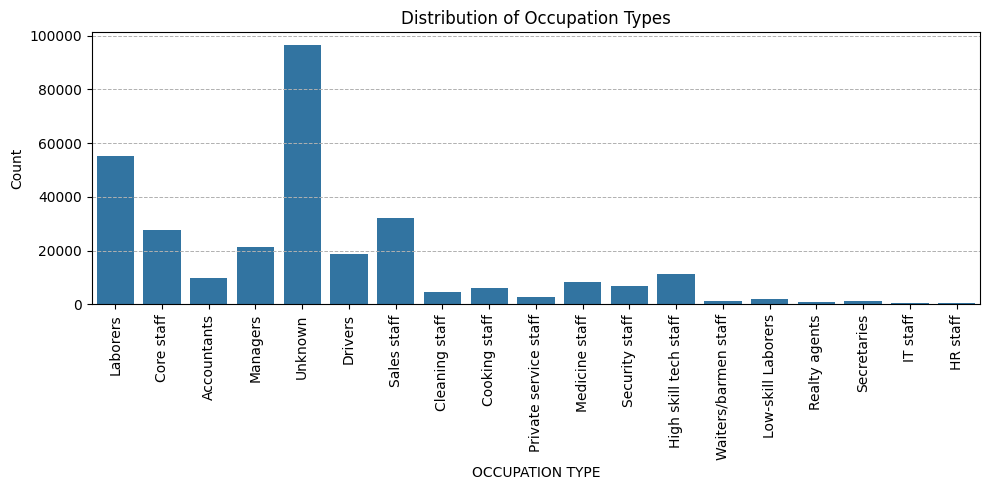

In [318]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x = 'OCCUPATION_TYPE')
plt.title('Distribution of Occupation Types')
plt.xlabel('OCCUPATION TYPE')
plt.ylabel('Count')
plt.xticks(rotation = 90)
plt.grid(axis='y', linestyle='--', linewidth=0.7)
plt.tight_layout()
plt.show()



> From the "Distribution of Occupation Types" graph, it is evident that Laborers form the largest group of loan applicants. Missing values make up 31.35% of the data. Given the categorical nature of the "OCCUPATION_TYPE" column, imputing these missing values using a constant such as the mode could distort the analysis and subsequent calculations. Therefore, it is advisable to leave the missing values as they are, ensuring the integrity of the dataset for further exploration and modeling.



**Analyze the EXT_SOURCE_3**

In [319]:
df['EXT_SOURCE_3'].dtype

dtype('float64')

In [320]:
null_df_under40.loc[null_df_under40["name_column"]=='EXT_SOURCE_3']

,name_column,count_null,null_percentage
1,EXT_SOURCE_3,60965,19.83


In [321]:
df['EXT_SOURCE_3'].value_counts()

,count
EXT_SOURCE_3,
0.75,1460
0.71,1315
0.69,1276
0.67,1191
0.65,1154
...,...
0.03,1
0.86,1
0.85,1


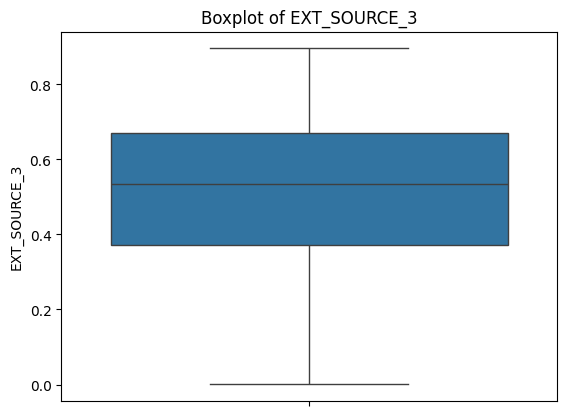

In [322]:
sns.boxplot(data=df, y='EXT_SOURCE_3')
plt.title('Boxplot of EXT_SOURCE_3')
plt.ylabel('EXT_SOURCE_3')
plt.show()

Get percentile values ​​for EXT_SOURCE_3.

In [323]:
df.EXT_SOURCE_3.quantile([.01,.25,.50,.75,1])

,EXT_SOURCE_3
0.01,0.06
0.25,0.37
0.50,0.54
0.75,0.67
1.00,0.90


In [324]:
pd.set_option('float_format','{:.2f}'.format )
df.EXT_SOURCE_3.describe()

,EXT_SOURCE_3
count,246546.00
mean,0.51
std,0.19
min,0.00
25%,0.37
50%,0.54
75%,0.67
max,0.90


Most repeated value in `EXT_SOURCE_3

In [325]:
df["EXT_SOURCE_3"].mode()[0]

np.float64(0.746300213050371)

Check the average value of EXT_SOURCE_3

In [326]:
df.EXT_SOURCE_3.mean()

np.float64(0.5108529061799658)

**Observation**

The distribution analysis reveals the following:


*   The median value is 0.5353.
*   The most frequent value (mode) is 0.7463.
*   The mean value is 0.5109.


The mean and median are close, suggesting a relatively symmetrical distribution. However, the percentage of missing values is 19.83%, which is significant. Imputing these missing values based on any single measure of central tendency (mean, median, or mode) could introduce bias or distort the data distribution.

Thus, it is recommended to retain the data as is without imputation. If the analysis or model requires imputing missing values, one approach could be to impute the data using the median (as it is less sensitive to outliers) and create an additional column to indicate which values were imputed.





**Analyze of AMT_REQ_CREDIT_BUREAU columns**

Analyze of the AMT_REQ_CREDIT_BUREAU_YEAR

In [327]:
df['AMT_REQ_CREDIT_BUREAU_YEAR'].dtype

dtype('float64')

In [328]:
null_df_under40.loc[null_df_under40["name_column"]=='AMT_REQ_CREDIT_BUREAU_YEAR']

,name_column,count_null,null_percentage
5,AMT_REQ_CREDIT_BUREAU_YEAR,41519,13.50


In [329]:
df['AMT_REQ_CREDIT_BUREAU_YEAR'].value_counts()

,count
AMT_REQ_CREDIT_BUREAU_YEAR,
0.00,71801
1.00,63405
2.00,50192
3.00,33628
4.00,20714
5.00,12052
6.00,6967
7.00,3869
8.00,2127


In [330]:
df.AMT_REQ_CREDIT_BUREAU_YEAR.quantile([.01,.25,.50,.75,1])

,AMT_REQ_CREDIT_BUREAU_YEAR
0.01,0.00
0.25,0.00
0.50,1.00
0.75,3.00
1.00,25.00


In [331]:
df["AMT_REQ_CREDIT_BUREAU_YEAR"].mode()[0]

np.float64(0.0)

In [332]:
df["AMT_REQ_CREDIT_BUREAU_YEAR"].mean()

np.float64(1.899974435321363)

In [333]:
df["AMT_REQ_CREDIT_BUREAU_YEAR"].median()

1.0

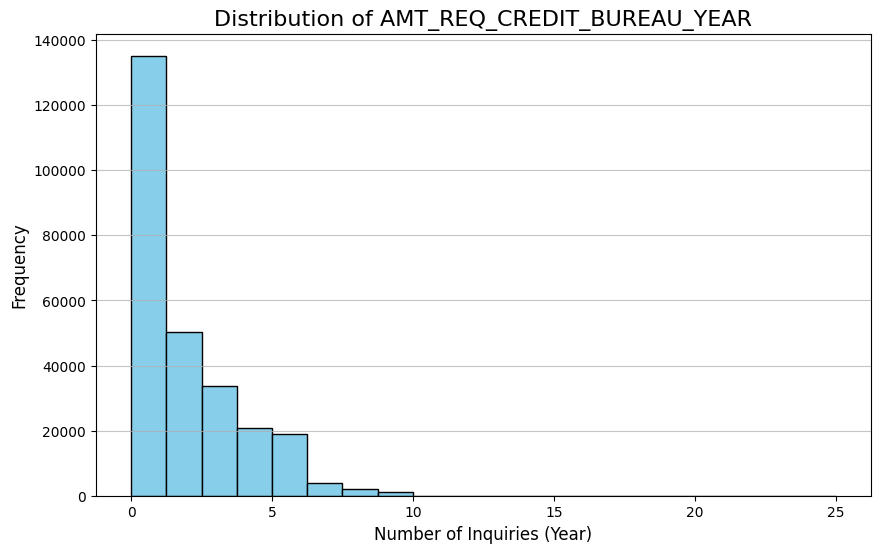

In [334]:
plt.figure(figsize=(10, 6))
plt.hist(df['AMT_REQ_CREDIT_BUREAU_YEAR'].dropna(), bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of AMT_REQ_CREDIT_BUREAU_YEAR', fontsize=16)
plt.xlabel('Number of Inquiries (Year)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.show()

**Observation**

The distribution analysis reveals the following insights:

*   Null Percentage: 13.50% (moderate, but not negligible).

*   Skewness: Positively skewed (right-skewed) toward 0.0, with a long tail extending to 25.0.

*   Median: 1.0.

*   Mode: 0.0 (most frequent value).

*   Mean: 1.9.

Based on the obtained results, missing data can be replaced by the median, since it reflects the median tendency of the data in a given context better than the mode and is not sensitive to outliers. But since the percentage of missing values ​​is large (13.50%), it is better to leave the data as is, because replacing such a large number of missing data can significantly change our data.

**Analyze of the AMT_REQ_CREDIT_BUREAU_QRT column**

In [335]:
df['AMT_REQ_CREDIT_BUREAU_QRT'].dtype

dtype('float64')

In [336]:
null_df_under40.loc[null_df_under40["name_column"]=='AMT_REQ_CREDIT_BUREAU_QRT']

,name_column,count_null,null_percentage
6,AMT_REQ_CREDIT_BUREAU_QRT,41519,13.50


In [337]:
df['AMT_REQ_CREDIT_BUREAU_QRT'].value_counts()

,count
AMT_REQ_CREDIT_BUREAU_QRT,
0.00,215417
1.00,33862
2.00,14412
3.00,1717
4.00,476
5.00,64
6.00,28
8.00,7
7.00,7


In [338]:
df.AMT_REQ_CREDIT_BUREAU_QRT.quantile([.01,.25,.50,.75,1])

,AMT_REQ_CREDIT_BUREAU_QRT
0.01,0.00
0.25,0.00
0.50,0.00
0.75,0.00
1.00,261.00


In [339]:
df["AMT_REQ_CREDIT_BUREAU_QRT"].mode()

,AMT_REQ_CREDIT_BUREAU_QRT
0,0.00


In [340]:
df["AMT_REQ_CREDIT_BUREAU_QRT"].mean()

np.float64(0.26547414959848414)

In [341]:
df["AMT_REQ_CREDIT_BUREAU_QRT"].median()

0.0

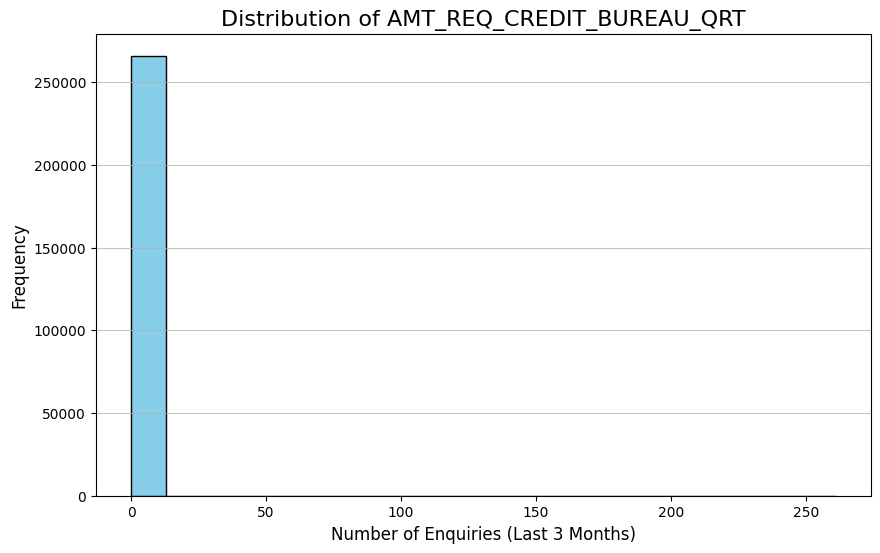

In [342]:
plt.figure(figsize=(10, 6))
plt.hist(df['AMT_REQ_CREDIT_BUREAU_QRT'].dropna(), bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of AMT_REQ_CREDIT_BUREAU_QRT', fontsize=16)
plt.xlabel('Number of Enquiries (Last 3 Months)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.show()

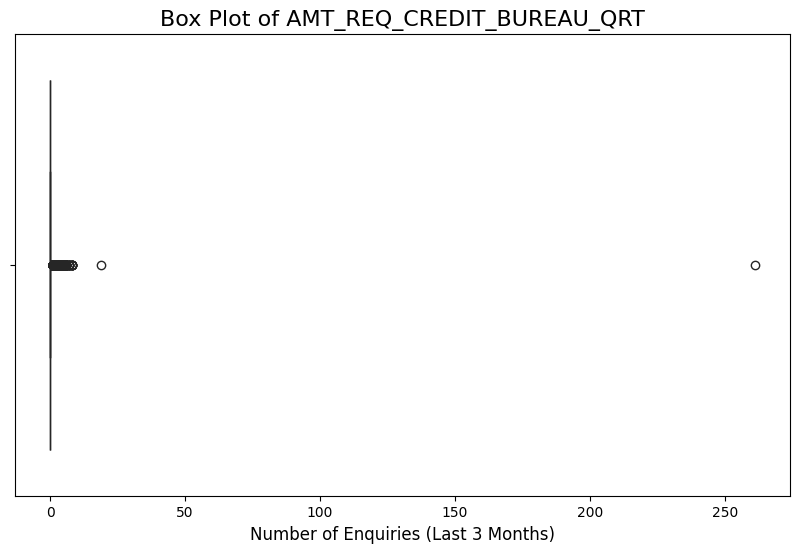

In [343]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['AMT_REQ_CREDIT_BUREAU_QRT'], color='green')
plt.title('Box Plot of AMT_REQ_CREDIT_BUREAU_QRT', fontsize=16)
plt.xlabel('Number of Enquiries (Last 3 Months)', fontsize=12)
plt.show()

Observation

The distribution analysis reveals the following insights:

*   Null Percentage: 13.50% (moderate, but not negligible).

*   Skewness: Positively skewed (right-skewed) toward 0.0, with a long tail extending to 261.0.

*   Median: 0.0.

*   Mode: 0.0

*   Mean: 0.265.

Based on the results obtained, missing data can be replaced by the mode or median (0,0) because:
*   It corresponds to the most frequently occurring value, which represents the majority of cases.
*   The average and higher values ​​are influenced by extreme outliers and do not reflect the typical behavior of the data.

But since the percentage of missing values ​​is large (13.5%), it is better to leave the data as is, because replacing such a large number of missing data can significantly change our data.

**Analyze of the AMT_REQ_CREDIT_BUREAU_MON column**

In [344]:
df["AMT_REQ_CREDIT_BUREAU_MON"].dtype

dtype('float64')

In [345]:
null_df_under40.loc[null_df_under40["name_column"]=='AMT_REQ_CREDIT_BUREAU_QRT']

,name_column,count_null,null_percentage
6,AMT_REQ_CREDIT_BUREAU_QRT,41519,13.50


In [346]:
df["AMT_REQ_CREDIT_BUREAU_MON"].value_counts()

,count
AMT_REQ_CREDIT_BUREAU_MON,
0.00,222233
1.00,33147
2.00,5386
3.00,1991
4.00,1076
5.00,602
6.00,343
7.00,298
9.00,206


In [347]:
df["AMT_REQ_CREDIT_BUREAU_MON"].quantile([.01,.25,.50,.75,1])

,AMT_REQ_CREDIT_BUREAU_MON
0.01,0.00
0.25,0.00
0.50,0.00
0.75,0.00
1.00,27.00


In [348]:
df["AMT_REQ_CREDIT_BUREAU_MON"].mode()

,AMT_REQ_CREDIT_BUREAU_MON
0,0.00


In [349]:
df["AMT_REQ_CREDIT_BUREAU_MON"].median()

0.0

In [350]:
df["AMT_REQ_CREDIT_BUREAU_MON"].mean()

np.float64(0.26739526000781977)

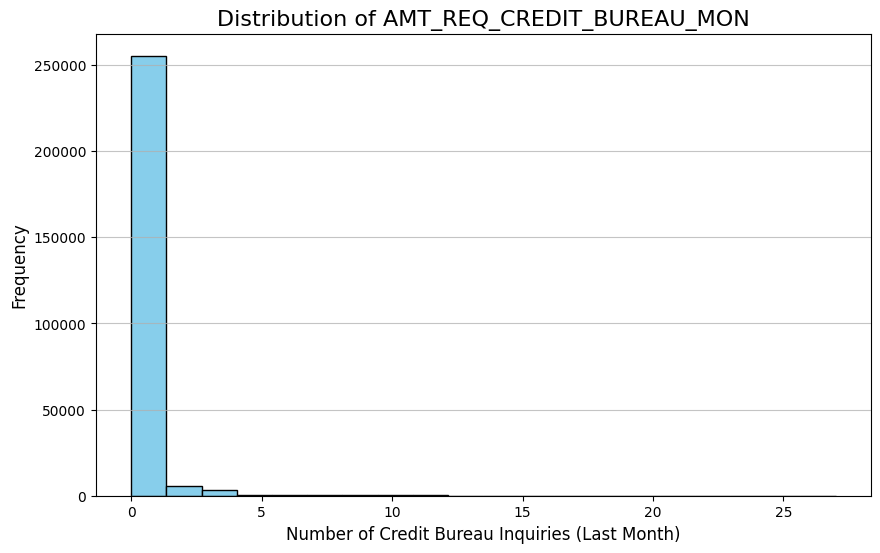

In [351]:
plt.figure(figsize=(10, 6))
plt.hist(df['AMT_REQ_CREDIT_BUREAU_MON'].dropna(), bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of AMT_REQ_CREDIT_BUREAU_MON', fontsize=16)
plt.xlabel('Number of Credit Bureau Inquiries (Last Month)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.show()

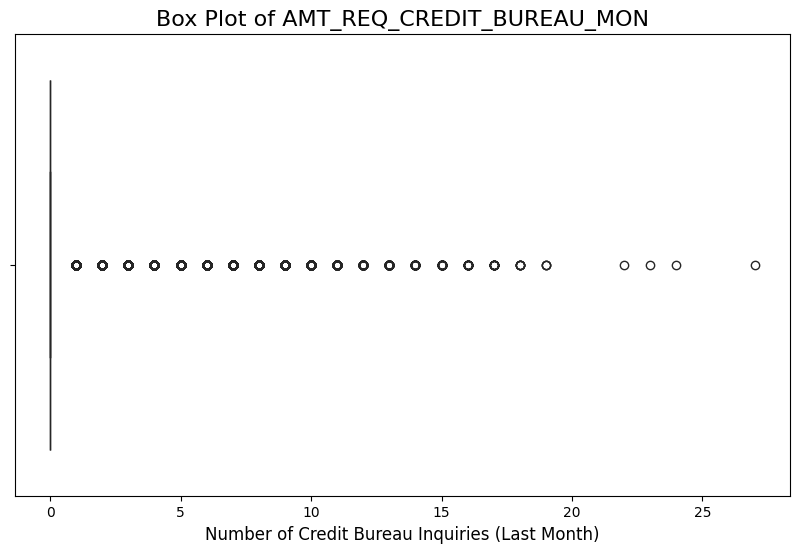

In [352]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['AMT_REQ_CREDIT_BUREAU_MON'], color='green')
plt.title('Box Plot of AMT_REQ_CREDIT_BUREAU_MON', fontsize=16)
plt.xlabel('Number of Credit Bureau Inquiries (Last Month)', fontsize=12)
plt.show()

Observation

The distribution analysis reveals the following insights:

*   Null Percentage: ссс

*   Skewness: Positively skewed (right-skewed) toward 0.0, with a long tail extending to 27.0.

*   Median: 0.0.

*   Mode: 0.0

*   Mean: 0.267.

Based on the obtained results, the missing data can be replaced by the median (0,0), since the data set contains outliers, and the median is not sensitive to outliers.

But since the percentage of missing values ​​is large (13.5%), it is better to leave the data as is, because replacing such a large number of missing data can significantly change our data.

**Analyze of the AMT_REQ_CREDIT_BUREAU_WEEK column**

In [353]:
df['AMT_REQ_CREDIT_BUREAU_WEEK'].dtype

dtype('float64')

In [354]:
null_df_under40.loc[null_df_under40["name_column"]=='AMT_REQ_CREDIT_BUREAU_WEEK']

,name_column,count_null,null_percentage
2,AMT_REQ_CREDIT_BUREAU_WEEK,41519,13.50


In [355]:
df['AMT_REQ_CREDIT_BUREAU_WEEK'].value_counts()

,count
AMT_REQ_CREDIT_BUREAU_WEEK,
0.00,257456
1.00,8208
2.00,199
3.00,58
4.00,34
6.00,20
5.00,10
8.00,5
7.00,2


In [356]:
df.AMT_REQ_CREDIT_BUREAU_WEEK.quantile(q = [0.25,0.5,0.75,1])

,AMT_REQ_CREDIT_BUREAU_WEEK
0.25,0.00
0.50,0.00
0.75,0.00
1.00,8.00


In [357]:
df['AMT_REQ_CREDIT_BUREAU_WEEK'].mean()

np.float64(0.0343619356973142)

In [358]:
df['AMT_REQ_CREDIT_BUREAU_WEEK'].mode()

,AMT_REQ_CREDIT_BUREAU_WEEK
0,0.00


In [359]:
df['AMT_REQ_CREDIT_BUREAU_WEEK'].median()

0.0

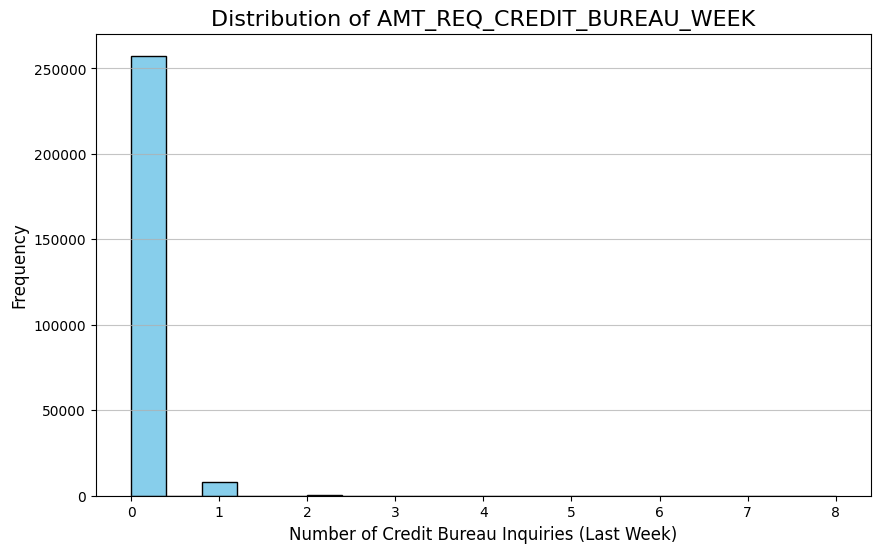

In [360]:
plt.figure(figsize=(10, 6))
plt.hist(df['AMT_REQ_CREDIT_BUREAU_WEEK'].dropna(), bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of AMT_REQ_CREDIT_BUREAU_WEEK', fontsize=16)
plt.xlabel('Number of Credit Bureau Inquiries (Last Week)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.show()

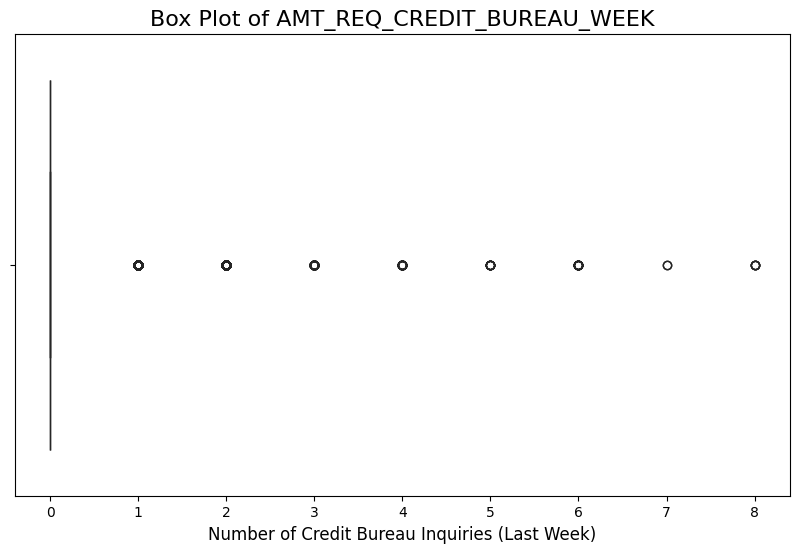

In [361]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['AMT_REQ_CREDIT_BUREAU_WEEK'], color='green')
plt.title('Box Plot of AMT_REQ_CREDIT_BUREAU_WEEK', fontsize=16)
plt.xlabel('Number of Credit Bureau Inquiries (Last Week)', fontsize=12)
plt.show()

Observation

The distribution analysis reveals the following insights:

*   Null Percentage: 13.50% (moderate, but not negligible).

*   Skewness: The data is highly positively skewed (right-skewed), with most values concentrated at 0.0 and a long tail extending to 8.0.

*   Median: 0.0.

*   Mode: 0.0.

*   Mean: 0.034.

Based on the obtained results, the missing data can be replaced by the median (0,0), since the data set contains outliers, and the median is not sensitive to outliers.

But since the percentage of missing values ​​is large (13.5%), it is better to leave the data as is, because replacing such a large number of missing data can significantly change our data.


**Analyze of the AMT_REQ_CREDIT_BUREAU_DAY column**

In [362]:
df['AMT_REQ_CREDIT_BUREAU_DAY'].dtype

dtype('float64')

In [363]:
null_df_under40.loc[null_df_under40["name_column"]=='AMT_REQ_CREDIT_BUREAU_DAY']

,name_column,count_null,null_percentage
7,AMT_REQ_CREDIT_BUREAU_DAY,41519,13.50


In [364]:
df['AMT_REQ_CREDIT_BUREAU_DAY'].value_counts()

,count
AMT_REQ_CREDIT_BUREAU_DAY,
0.00,264503
1.00,1292
2.00,106
3.00,45
4.00,26
5.00,9
6.00,8
9.00,2
8.00,1


In [365]:
df.AMT_REQ_CREDIT_BUREAU_DAY.quantile(q = [0.25,0.5,0.75,1])

,AMT_REQ_CREDIT_BUREAU_DAY
0.25,0.00
0.50,0.00
0.75,0.00
1.00,9.00


In [366]:
df['AMT_REQ_CREDIT_BUREAU_DAY'].mode()

,AMT_REQ_CREDIT_BUREAU_DAY
0,0.00


In [367]:
df['AMT_REQ_CREDIT_BUREAU_DAY'].median()

0.0

In [368]:
df['AMT_REQ_CREDIT_BUREAU_DAY'].mean()

np.float64(0.0070002105326475985)

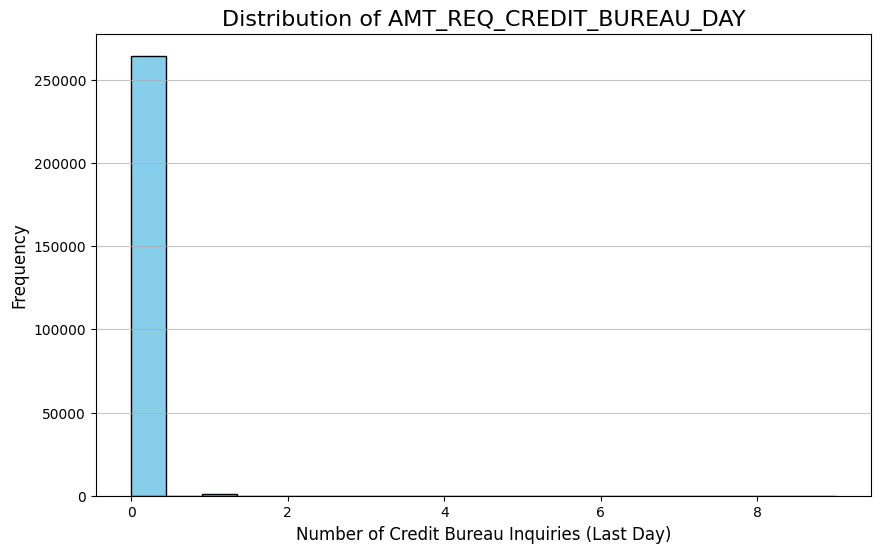

In [369]:
plt.figure(figsize=(10, 6))
plt.hist(df['AMT_REQ_CREDIT_BUREAU_DAY'].dropna(), bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of AMT_REQ_CREDIT_BUREAU_DAY', fontsize=16)
plt.xlabel('Number of Credit Bureau Inquiries (Last Day)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.show()

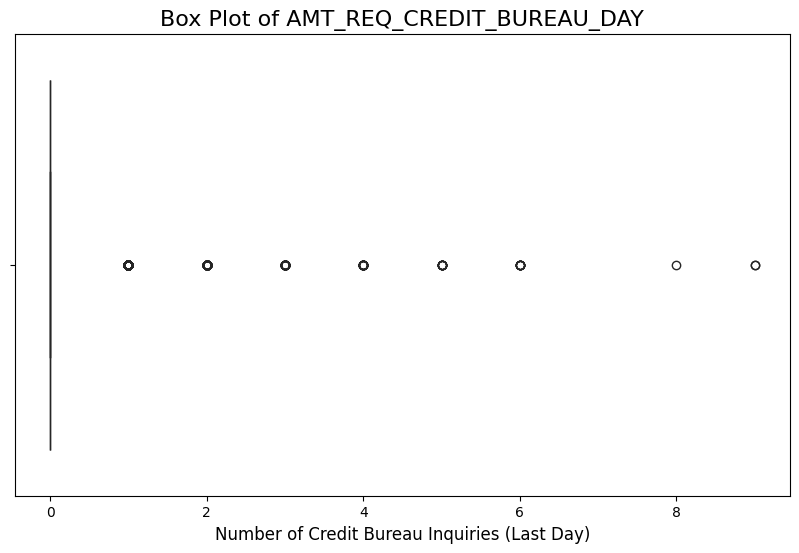

In [370]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['AMT_REQ_CREDIT_BUREAU_DAY'], color='green')
plt.title('Box Plot of AMT_REQ_CREDIT_BUREAU_DAY', fontsize=16)
plt.xlabel('Number of Credit Bureau Inquiries (Last Day)', fontsize=12)
plt.show()

Observation

The distribution analysis reveals the following insights:

*   Null Percentage: 13.50% (moderate, but not negligible).

*   Skewness: The data is highly positively skewed (right-skewed), with most values concentrated at 0.0 and a long tail extending to 9.0.

*   Median: 0.0.

*   Mode: 0.0.

*   Mean: 0.007.

Based on the results obtained, missing data can be replaced by the mode (0,0), replacing missing values ​​with the mode preserves the natural distribution of the data. This approach is simple and minimizes the risk of distorting the characteristics of the data set.

But since the percentage of missing values ​​is large (13.5%), it is better to leave the data as is, because replacing such a large number of missing data can significantly change our data.


**Analyze of the AMT_REQ_CREDIT_BUREAU_HOUR column**

In [371]:
df['AMT_REQ_CREDIT_BUREAU_HOUR'].dtype

dtype('float64')

In [372]:
null_df_under40.loc[null_df_under40["name_column"]=='AMT_REQ_CREDIT_BUREAU_HOUR']

,name_column,count_null,null_percentage
4,AMT_REQ_CREDIT_BUREAU_HOUR,41519,13.50


In [373]:
df['AMT_REQ_CREDIT_BUREAU_HOUR'].value_counts()

,count
AMT_REQ_CREDIT_BUREAU_HOUR,
0.00,264366
1.00,1560
2.00,56
3.00,9
4.00,1


In [374]:
df.AMT_REQ_CREDIT_BUREAU_HOUR.quantile(q = [0.25,0.5,0.75,1])

,AMT_REQ_CREDIT_BUREAU_HOUR
0.25,0.00
0.50,0.00
0.75,0.00
1.00,4.00


In [375]:
df['AMT_REQ_CREDIT_BUREAU_HOUR'].mode()

,AMT_REQ_CREDIT_BUREAU_HOUR
0,0.00


In [376]:
df['AMT_REQ_CREDIT_BUREAU_HOUR'].median()

0.0

In [377]:
df['AMT_REQ_CREDIT_BUREAU_HOUR'].mean()

np.float64(0.006402448193930645)

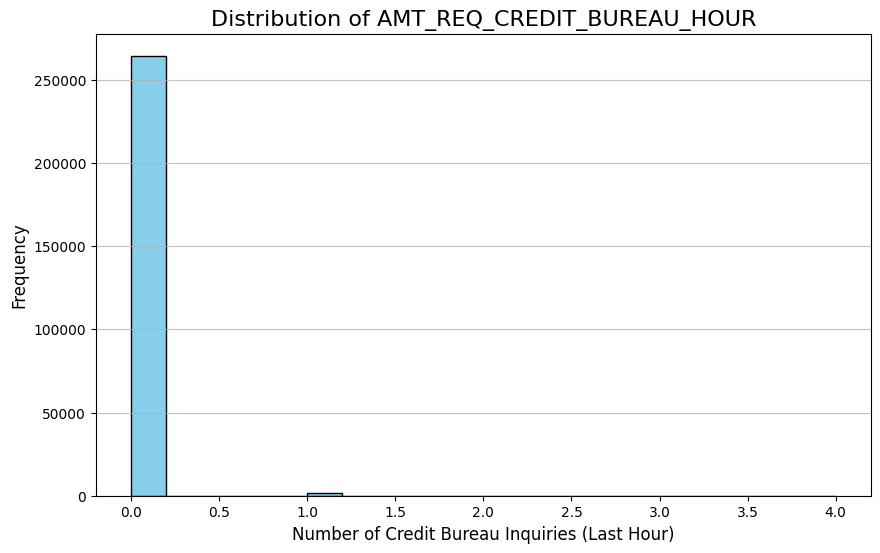

In [378]:
plt.figure(figsize=(10, 6))
plt.hist(df['AMT_REQ_CREDIT_BUREAU_HOUR'].dropna(), bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of AMT_REQ_CREDIT_BUREAU_HOUR', fontsize=16)
plt.xlabel('Number of Credit Bureau Inquiries (Last Hour)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.show()

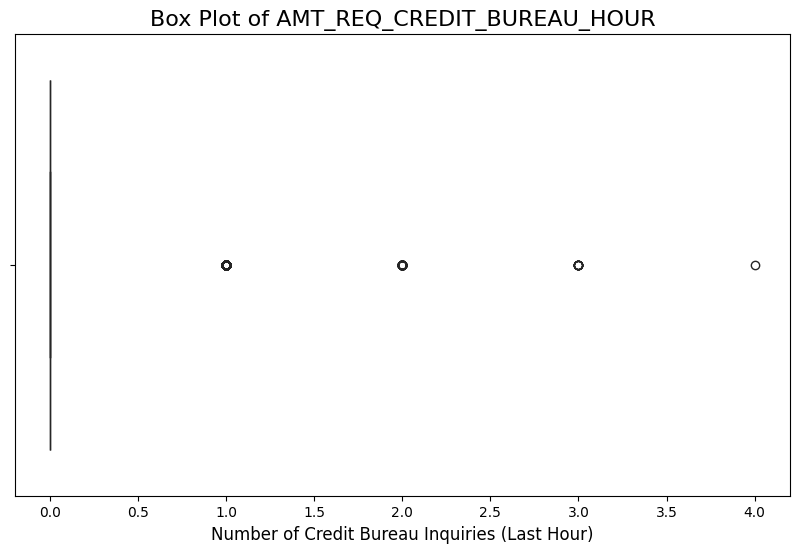

In [379]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['AMT_REQ_CREDIT_BUREAU_HOUR'], color='green')
plt.title('Box Plot of AMT_REQ_CREDIT_BUREAU_HOUR', fontsize=16)
plt.xlabel('Number of Credit Bureau Inquiries (Last Hour)', fontsize=12)
plt.show()

Observation

The distribution analysis reveals the following insights:

*   Null Percentage: 13.50% (moderate, but not negligible).

*   Skewness: The data is highly positively skewed (right-skewed), with most values concentrated at 0.0 and a long tail extending to 4.0.

*   Median: 0.0.

*   Mode: 0.0.

*   Mean: 0.006.

Based on the results obtained, missing data can be replaced by the mode (0,0), replacing missing values ​​with the mode preserves the natural distribution of the data. This approach is simple and minimizes the risk of distorting the characteristics of the data set.

But since the percentage of missing values ​​is large (13.5%), it is better to leave the data as is, because replacing such a large number of missing data can significantly change our data.

### **Check columns with NULL values ​​> 0% and < 1%**

In [380]:
null_df_under1 = null_df[(null_df['null_percentage'] > 0) & (null_df['null_percentage'] < 1)]

In [381]:
null_df_under1.sort_values(by = 'null_percentage', ascending = False)

,name_column,count_null,null_percentage
2,NAME_TYPE_SUITE,1292,0.42
57,DEF_30_CNT_SOCIAL_CIRCLE,1021,0.33
59,DEF_60_CNT_SOCIAL_CIRCLE,1021,0.33
56,OBS_30_CNT_SOCIAL_CIRCLE,1021,0.33
58,OBS_60_CNT_SOCIAL_CIRCLE,1021,0.33
7,EXT_SOURCE_2,660,0.21
1,AMT_GOODS_PRICE,278,0.09


In [382]:
import warnings

def dist_box(df, column_name):
    """
    Plots the distribution and box plot of a specified column in a dataset.

    Parameters:
    -----------
    dataset : pandas.DataFrame
        The dataset containing the column to analyze.
    column : str
        The name of the column for which the distribution and box plot will be plotted.

    Returns:
    --------
    None
        This function does not return any value. It directly displays the plots.
    """
    # Distribution plot
    plt.figure(figsize=(10, 6))
    plt.hist(df[column_name], bins=20, color='skyblue', edgecolor='black')
    plt.title(f'Distribution of {column_name}', fontsize=16)
    plt.xlabel(column_name, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.grid(axis='y', alpha=0.75)
    plt.show()

    # Box plot
    plt.figure(figsize=(10, 6))
    red_diamond = dict(markerfacecolor='r', marker='D')
    sns.boxplot(y=column_name, data=df, flierprops=red_diamond)
    #sns.boxplot(x=df[column_name], color='green')
    plt.title(f'Box Plot of {column_name}', fontsize=16)
    plt.ylabel(column_name, fontsize=12)
    plt.show()

In [383]:
def analyze_column_0_to_1_missing(df, column_name):
    """
    Analyzes a specified column in a DataFrame, focusing on columns with missing value percentages between 0% and 100%.

    Parameters:
    - df: pd.DataFrame, the DataFrame containing the data.
    - column_name: str, the name of the column to analyze.

    Returns:
    None, but displays statistics and visualizations.
    """
    if column_name not in df.columns:
        print(f"Column '{column_name}' does not exist in the DataFrame.")
        return

    print(f"Analysis for column: {column_name}")
    print("-" * 50)

    # Check data type
    dtype = df[column_name].dtype
    print(f"Data Type: {dtype}")

    # Count null values
    null_count = df[column_name].isnull().sum()
    total_count = len(df)
    print(f"Null Values: {null_count} ({(null_count / total_count) * 100:.2f}%)")

    # Value counts
    print("\nFrequent Values:")
    print(df[column_name].value_counts())

    # Quantiles
    quantiles = df[column_name].quantile([0.25, 0.5, 0.75, 1])
    print("\nQuantiles:")
    print(quantiles)

    # Mode
    mode = df[column_name].mode().iloc[0] if not df[column_name].mode().empty else "No mode"
    print(f"\nMode: {mode}")

    # Mean and Median
    mean = df[column_name].mean()
    median = df[column_name].median()
    print(f"\nMean: {mean}")
    print(f"Median: {median}")

    #Distribution and Box plot
    dist_box(df,column_name)



In [384]:
def calculate_outlier_bounds(df, column_name):
    """
    Calculate the interquartile range (IQR) and determine the bounds
    for identifying outliers in a specified column of a DataFrame.

    Parameters:
    - df (pd.DataFrame): The DataFrame containing the data.
    - column_name (str): The column to analyze.

    Prints:
    - IQR: The interquartile range.
    - Minimum and maximum bounds for detecting outliers.
    """
    if column_name not in df.columns:
        print(f"Column '{column_name}' does not exist in the DataFrame.")
        return

    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1

    min_bound = Q1 - 1.5 * IQR
    max_bound = Q3 + 1.5 * IQR

    # Print the calculated values
    print(f"IQR: {IQR}")
    print(f"Minimum value after which emissions exist: {min_bound}")
    print(f"Maximum value after which emissions exist: {max_bound}")

**Analyze of the NAME_TYPE_SUITE column**

In [385]:
null_df_under1[null_df_under1["name_column"] == 'NAME_TYPE_SUITE']

,name_column,count_null,null_percentage
2,NAME_TYPE_SUITE,1292,0.42


In [386]:
df['NAME_TYPE_SUITE'].value_counts()

,count
NAME_TYPE_SUITE,
Unaccompanied,248526
Family,40149
"Spouse, partner",11370
Children,3267
Other_B,1770
Other_A,866
Group of people,271


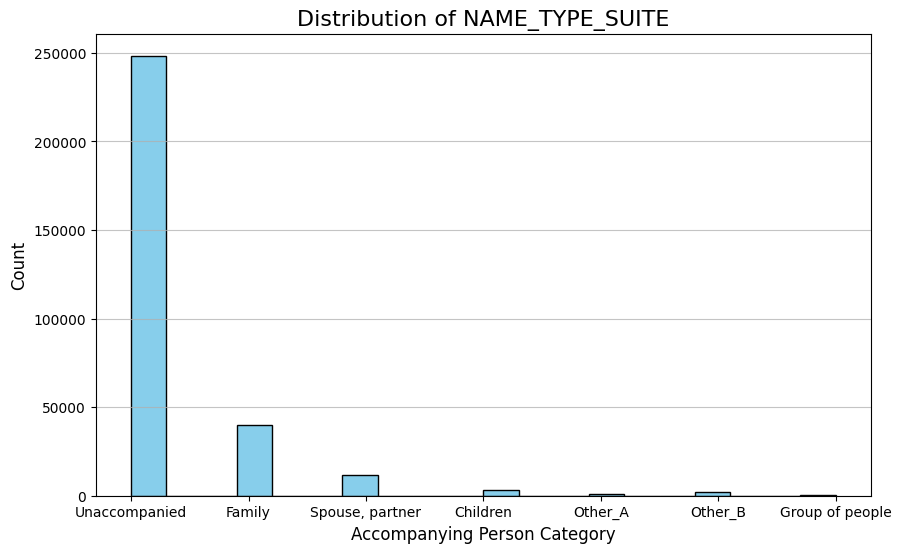

In [387]:
plt.figure(figsize=(10, 6))
plt.hist(df['NAME_TYPE_SUITE'].dropna(), bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of NAME_TYPE_SUITE', fontsize=16)
plt.xlabel('Accompanying Person Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.show()

Observation:
From the Distribution of NAME_TYPE_SUITE graph, it is evident that the Unaccompanied category has the highest number of loan applicants, indicating that most borrowers choose to apply for loans without accompaniment.

Recommendation:
While null values in this categorical column could logically be replaced with the most frequent category (Unaccompanied), it is more prudent to replace them with a placeholder such as "Na" to clearly distinguish imputed values from actual data. This approach preserves the integrity of the dataset and avoids making assumptions about missing values.

In [388]:
df['NAME_TYPE_SUITE']=df['NAME_TYPE_SUITE'].fillna('NA')

**Analyze of the OBS_30_CNT_SOCIAL_CIRCLE column**

Analysis for column: OBS_30_CNT_SOCIAL_CIRCLE
--------------------------------------------------
Data Type: float64
Null Values: 1021 (0.33%)

Frequent Values:
OBS_30_CNT_SOCIAL_CIRCLE
0.00      163910
1.00       48783
2.00       29808
3.00       20322
4.00       14143
5.00        9553
6.00        6453
7.00        4390
8.00        2967
9.00        2003
10.00       1376
11.00        852
12.00        652
13.00        411
14.00        258
15.00        166
16.00        133
17.00         88
18.00         46
19.00         44
20.00         30
21.00         29
22.00         22
23.00         15
25.00         11
24.00         11
27.00          5
26.00          3
30.00          2
29.00          1
28.00          1
47.00          1
348.00         1
Name: count, dtype: int64

Quantiles:
0.25     0.00
0.50     0.00
0.75     2.00
1.00   348.00
Name: OBS_30_CNT_SOCIAL_CIRCLE, dtype: float64

Mode: 0.0

Mean: 1.4222454239942575
Median: 0.0


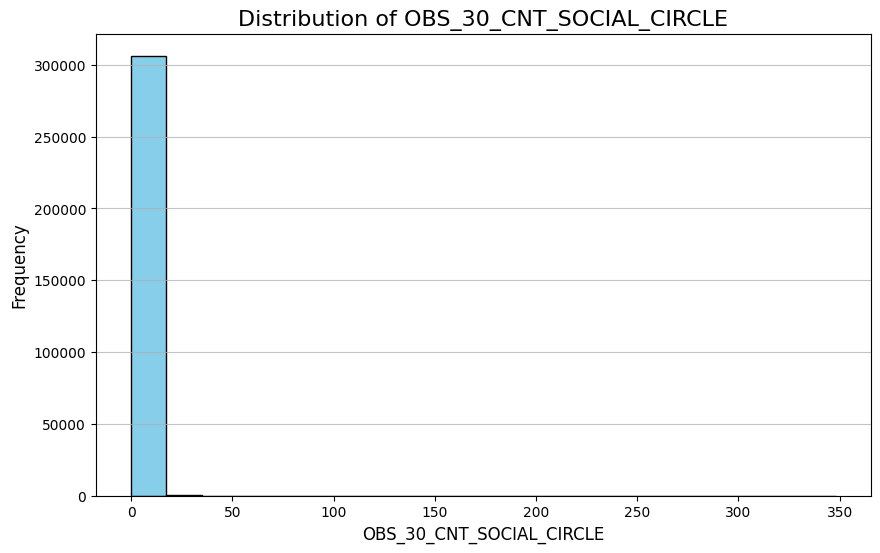

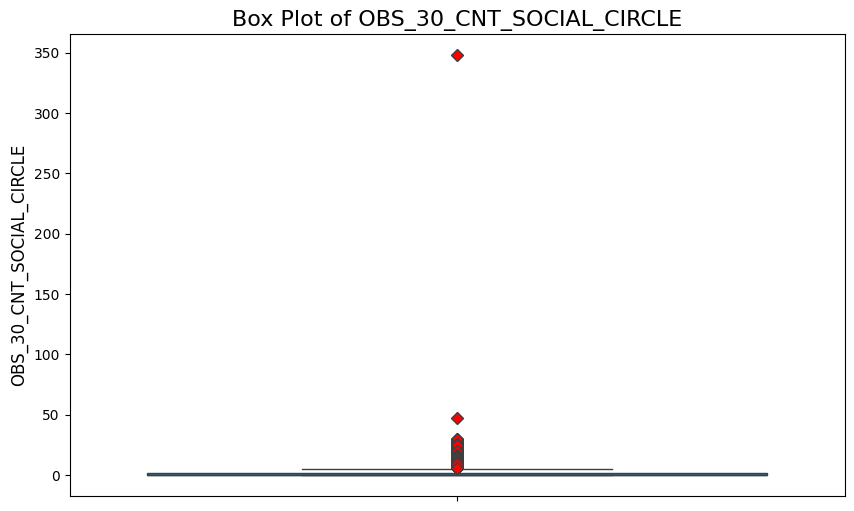

In [389]:
analyze_column_0_to_1_missing(df,'OBS_30_CNT_SOCIAL_CIRCLE')

Observation

The distribution analysis reveals the following insights:

*   Null Percentage: 0.33% (very small and not significant).

*   Skewness: The data is highly positively skewed (right-skewed), with most values concentrated at 0.0 and a long tail extending to 350.0.

*   Median: 0.0.

*   Mode: 0.0.

*   Mean: 1.422.

*   Outliers: Two notable outliers at 50 and 350.

Recommendation:
The median and mode are identical, making either a suitable choice for imputation in this column. Given the small percentage of missing values (0.33%), imputing them using the median or mode is unlikely to introduce bias or distort the dataset.

In [390]:
df["OBS_30_CNT_SOCIAL_CIRCLE"]=df["OBS_30_CNT_SOCIAL_CIRCLE"].fillna(df['OBS_30_CNT_SOCIAL_CIRCLE'].median())

In [391]:
df.OBS_30_CNT_SOCIAL_CIRCLE.info()

<class 'pandas.core.series.Series'>
RangeIndex: 307511 entries, 0 to 307510
Series name: OBS_30_CNT_SOCIAL_CIRCLE
Non-Null Count   Dtype  
--------------   -----  
307511 non-null  float64
dtypes: float64(1)
memory usage: 2.3 MB


**Analyze of the DEF_30_CNT_SOCIAL_CIRCLE column**

Analysis for column: DEF_30_CNT_SOCIAL_CIRCLE
--------------------------------------------------
Data Type: float64
Null Values: 1021 (0.33%)

Frequent Values:
DEF_30_CNT_SOCIAL_CIRCLE
0.00     271324
1.00      28328
2.00       5323
3.00       1192
4.00        253
5.00         56
6.00         11
7.00          1
34.00         1
8.00          1
Name: count, dtype: int64

Quantiles:
0.25    0.00
0.50    0.00
0.75    0.00
1.00   34.00
Name: DEF_30_CNT_SOCIAL_CIRCLE, dtype: float64

Mode: 0.0

Mean: 0.1434206662533851
Median: 0.0


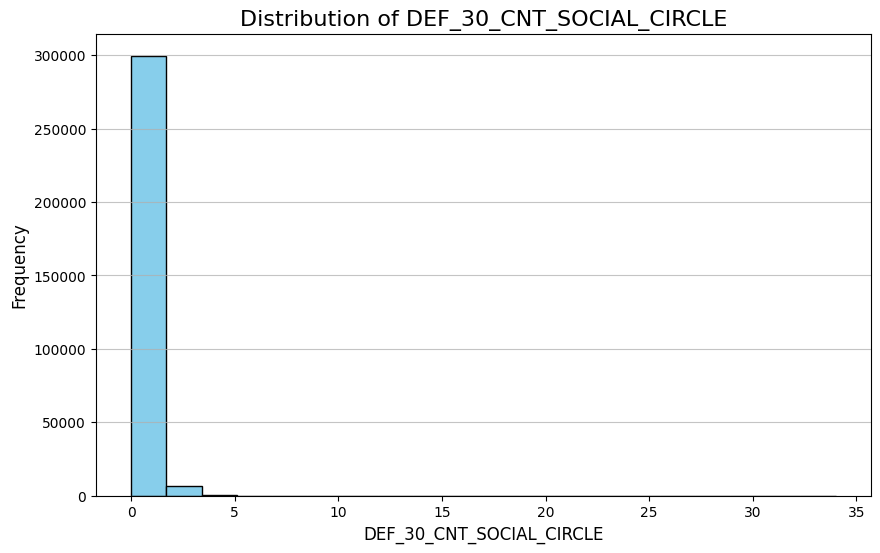

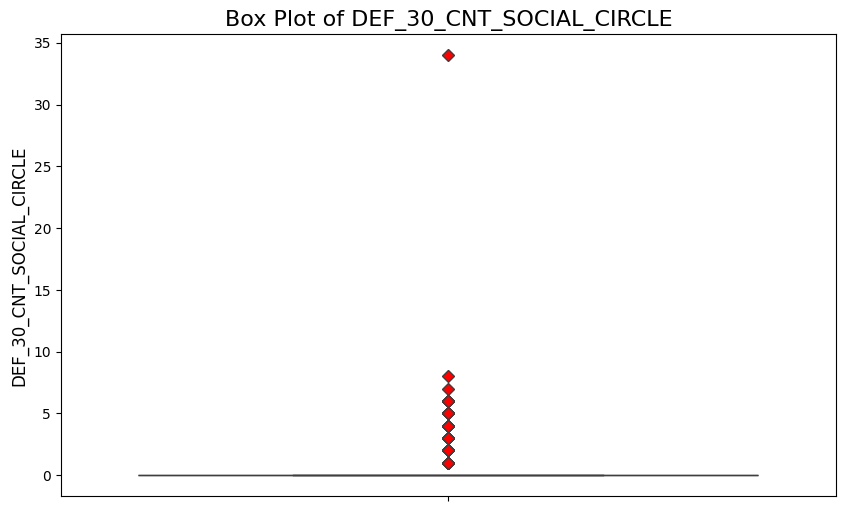

In [392]:
analyze_column_0_to_1_missing(df, 'DEF_30_CNT_SOCIAL_CIRCLE')

Observation

The distribution analysis reveals the following insights:

*   Null Percentage: 0.33% (very small and not significant).

*   Skewness: The data is highly positively skewed (right-skewed), with most values concentrated at 0.0 and a long tail extending to 34.0.

*   Median: 0.0.

*   Mode: 0.0.

*   Mean: 0.1434.

*   Outliers:  Several extreme values are present in the dataset.

Recommendation:
The median and mode are identical, making either a suitable choice for imputation in this column. Given the small percentage of missing values (0.33%), imputing them using the median or mode is unlikely to introduce bias or distort the dataset.

In [393]:
df["DEF_30_CNT_SOCIAL_CIRCLE"]=df["DEF_30_CNT_SOCIAL_CIRCLE"].fillna(df['DEF_30_CNT_SOCIAL_CIRCLE'].median())

In [394]:
df.DEF_30_CNT_SOCIAL_CIRCLE.info()

<class 'pandas.core.series.Series'>
RangeIndex: 307511 entries, 0 to 307510
Series name: DEF_30_CNT_SOCIAL_CIRCLE
Non-Null Count   Dtype  
--------------   -----  
307511 non-null  float64
dtypes: float64(1)
memory usage: 2.3 MB


**Analyze of the EXT_SOURCE_2 column**

Analysis for column: EXT_SOURCE_2
--------------------------------------------------
Data Type: float64
Null Values: 660 (0.21%)

Frequent Values:
EXT_SOURCE_2
0.29    721
0.26    417
0.27    343
0.16    322
0.27    306
       ... 
0.35      1
0.20      1
0.15      1
0.29      1
0.27      1
Name: count, Length: 119831, dtype: int64

Quantiles:
0.25   0.39
0.50   0.57
0.75   0.66
1.00   0.85
Name: EXT_SOURCE_2, dtype: float64

Mode: 0.2858978721410488

Mean: 0.5143926741308462
Median: 0.5659614260608526


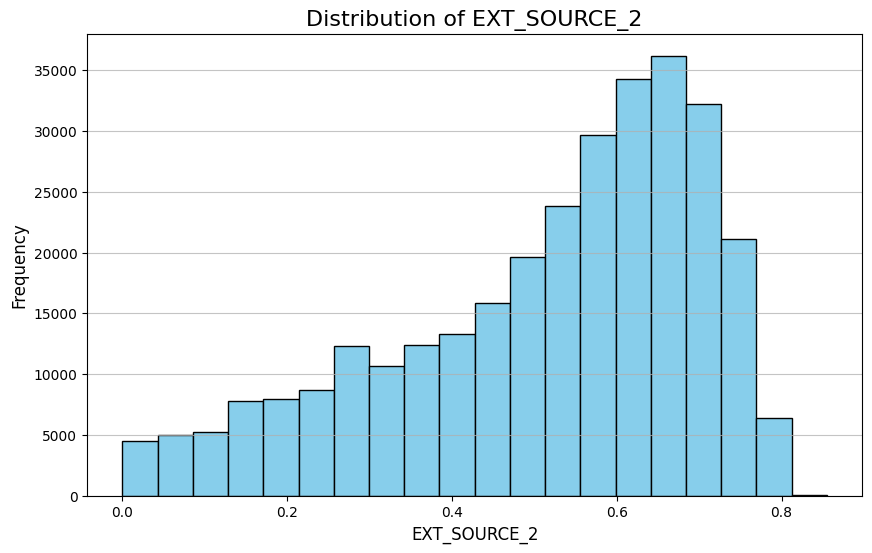

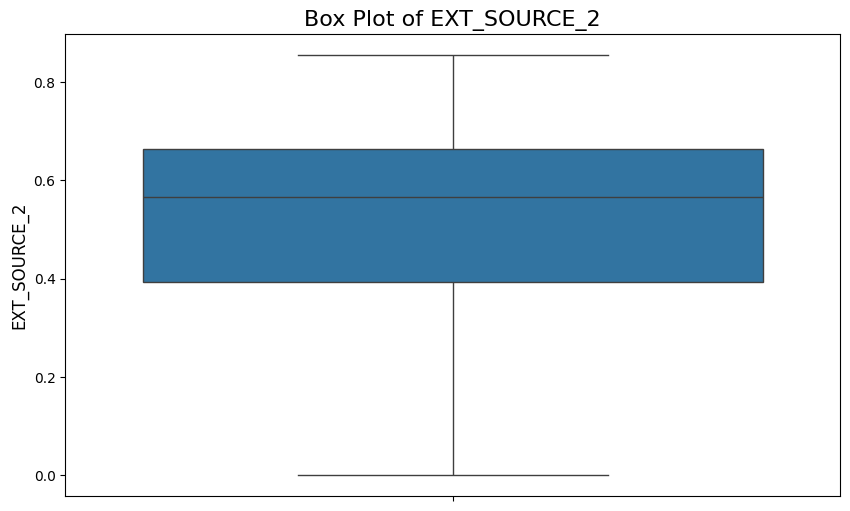

In [395]:
analyze_column_0_to_1_missing(df,"EXT_SOURCE_2")

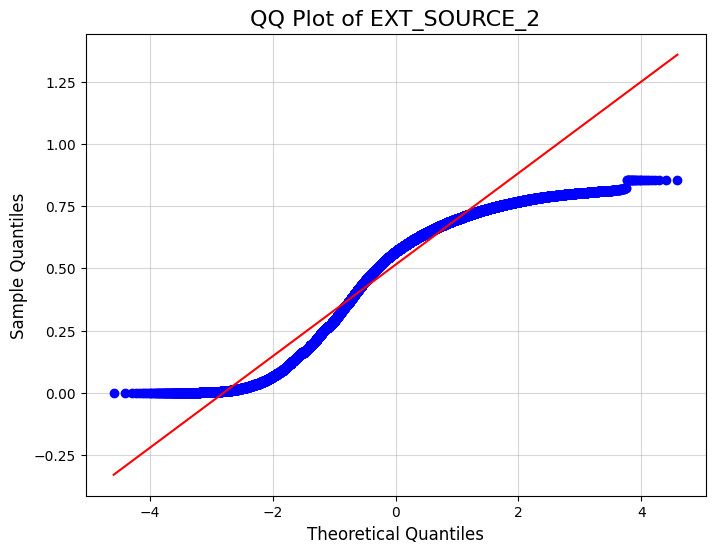

In [396]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Dropping null values
data = df['EXT_SOURCE_2'].dropna()

# Create QQ Plot
plt.figure(figsize=(8, 6))
stats.probplot(data, dist="norm", plot=plt)
plt.title('QQ Plot of EXT_SOURCE_2', fontsize=16)
plt.xlabel('Theoretical Quantiles', fontsize=12)
plt.ylabel('Sample Quantiles', fontsize=12)
plt.grid(alpha=0.5)
plt.show()


Observation

The distribution analysis reveals the following insights:

*   Null Percentage: 0.21% (very small and not significant).

*   Skewness: The distribution is slightly left-skewed because the mean (0.514) is less than the median (0.566).

*   Median: 0.566.

*   Mode: 0.286.

*   Mean: 0.514.

*   Outliers: None detected.

*   The QQ plot indicates overdispersion in the EXT_SOURCE_2 data.

Recommendation:
Impute the missing values with the median (0.566) as it is a robust measure of central tendency that aligns well with the slight skewness of the data distribution. Given the minimal percentage of missing values (0.21%), this approach is unlikely to introduce bias or distort the dataset while maintaining its integrity.

In [397]:
df["EXT_SOURCE_2"]=df["EXT_SOURCE_2"].fillna(df['EXT_SOURCE_2'].median())

In [398]:
df["EXT_SOURCE_2"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 307511 entries, 0 to 307510
Series name: EXT_SOURCE_2
Non-Null Count   Dtype  
--------------   -----  
307511 non-null  float64
dtypes: float64(1)
memory usage: 2.3 MB


**Analyze of the OBS_60_CNT_SOCIAL_CIRCLE column**

Analysis for column: OBS_60_CNT_SOCIAL_CIRCLE
--------------------------------------------------
Data Type: float64
Null Values: 1021 (0.33%)

Frequent Values:
OBS_60_CNT_SOCIAL_CIRCLE
0.00      164666
1.00       48870
2.00       29766
3.00       20215
4.00       13946
5.00        9463
6.00        6349
7.00        4344
8.00        2886
9.00        1959
10.00       1335
11.00        837
12.00        620
13.00        401
14.00        238
15.00        166
16.00        137
17.00         73
18.00         49
19.00         44
20.00         30
21.00         28
22.00         20
23.00         13
24.00         12
25.00         11
27.00          5
29.00          2
28.00          1
47.00          1
344.00         1
30.00          1
26.00          1
Name: count, dtype: int64

Quantiles:
0.25     0.00
0.50     0.00
0.75     2.00
1.00   344.00
Name: OBS_60_CNT_SOCIAL_CIRCLE, dtype: float64

Mode: 0.0

Mean: 1.4052921791901856
Median: 0.0


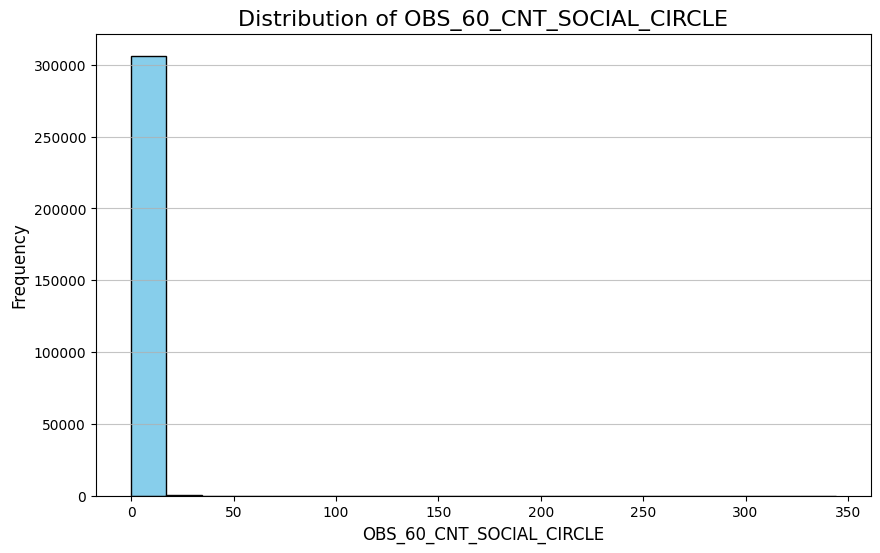

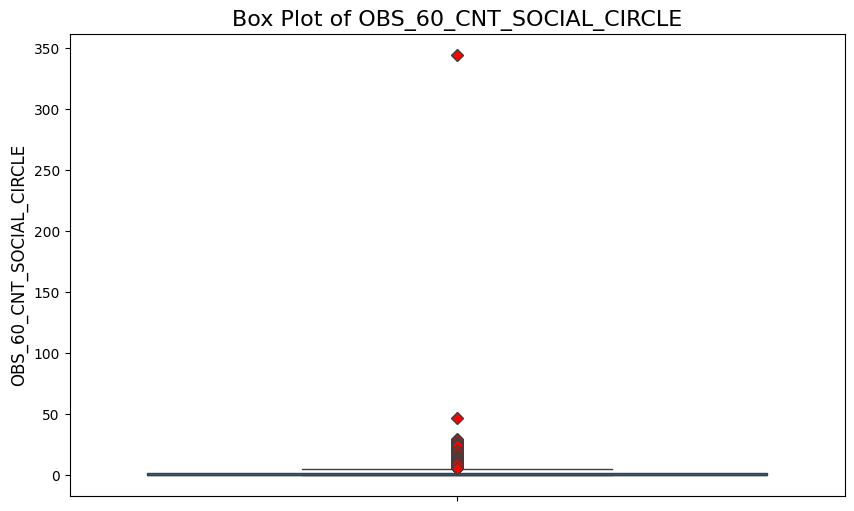

In [399]:
analyze_column_0_to_1_missing(df,"OBS_60_CNT_SOCIAL_CIRCLE")

Observation

The distribution analysis reveals the following insights:

*   Null Percentage: 0.33% (very small and not significant).

*   Skewness: The distribution is positively skewed (right-skewed), with most values concentrated at 0 or 1 and a long tail extending to 344.0.

*   Median: 0.0.

*   Mode: 0.0.

*   Mean: 1.405.

*   Outliers: Several extreme values are present in the dataset.

Recommendation:
Based on the obtained results, missing data should be replaced with the median (0.0), as it is robust to outliers and represents the majority of observations effectively. Given the minimal percentage of missing values (0.33%), this approach is unlikely to introduce bias or distort the dataset while maintaining its integrity.

In [400]:
df["OBS_60_CNT_SOCIAL_CIRCLE"]=df["OBS_60_CNT_SOCIAL_CIRCLE"].fillna(df['OBS_60_CNT_SOCIAL_CIRCLE'].median())

In [401]:
df["OBS_60_CNT_SOCIAL_CIRCLE"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 307511 entries, 0 to 307510
Series name: OBS_60_CNT_SOCIAL_CIRCLE
Non-Null Count   Dtype  
--------------   -----  
307511 non-null  float64
dtypes: float64(1)
memory usage: 2.3 MB


**Analyze of the DEF_60_CNT_SOCIAL_CIRCLE column**

Analysis for column: DEF_60_CNT_SOCIAL_CIRCLE
--------------------------------------------------
Data Type: float64
Null Values: 1021 (0.33%)

Frequent Values:
DEF_60_CNT_SOCIAL_CIRCLE
0.00     280721
1.00      21841
2.00       3170
3.00        598
4.00        135
5.00         20
6.00          3
7.00          1
24.00         1
Name: count, dtype: int64

Quantiles:
0.25    0.00
0.50    0.00
0.75    0.00
1.00   24.00
Name: DEF_60_CNT_SOCIAL_CIRCLE, dtype: float64

Mode: 0.0

Mean: 0.10004894123788705
Median: 0.0


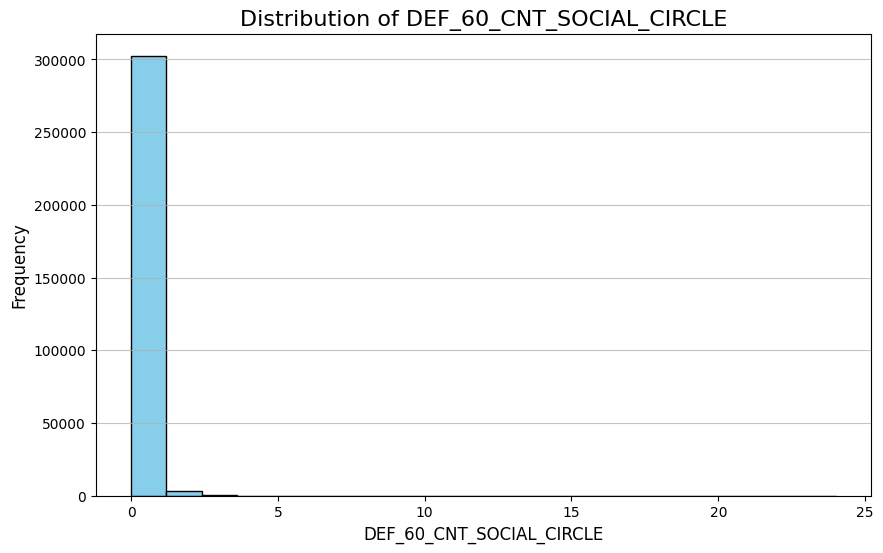

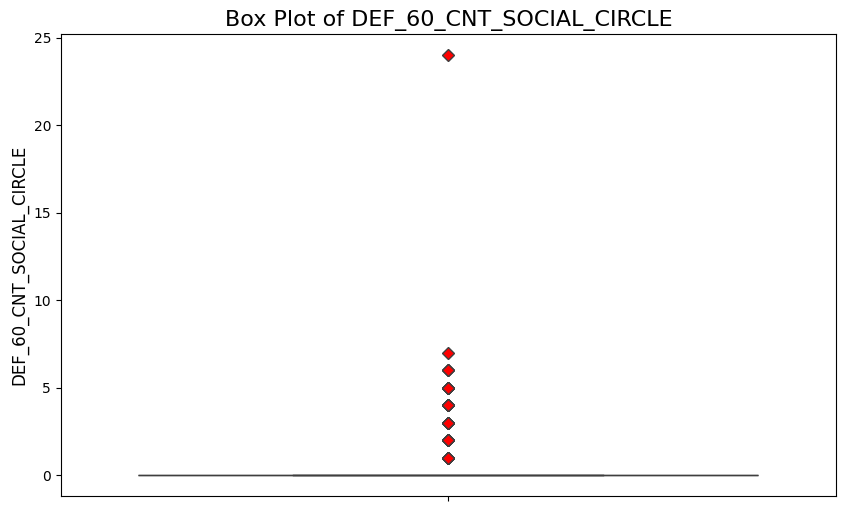

In [402]:
analyze_column_0_to_1_missing(df,"DEF_60_CNT_SOCIAL_CIRCLE")

Observation

The distribution analysis reveals the following insights:

*   Null Percentage: 0.33% (very small and not significant).

*   Skewness: The distribution is positively skewed (right-skewed), with most values concentrated at 0 or 1 and a long tail extending to 24.0.

*   Median: 0.0.

*   Mode: 0.0.

*   Mean: 0.100.

*   Outliers: Several extreme values are present in the dataset.

Recommendation:
Based on the obtained results, missing data should be replaced with the median (0.0), as it is robust to outliers and represents the majority of observations effectively. Given the minimal percentage of missing values (0.33%), this approach is unlikely to introduce bias or distort the dataset while maintaining its integrity.

In [403]:
df["DEF_60_CNT_SOCIAL_CIRCLE"]=df["DEF_60_CNT_SOCIAL_CIRCLE"].fillna(df['DEF_60_CNT_SOCIAL_CIRCLE'].median())

In [404]:
df["DEF_60_CNT_SOCIAL_CIRCLE"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 307511 entries, 0 to 307510
Series name: DEF_60_CNT_SOCIAL_CIRCLE
Non-Null Count   Dtype  
--------------   -----  
307511 non-null  float64
dtypes: float64(1)
memory usage: 2.3 MB


**Analyze of the AMT_GOODS_PRICE column**

Analysis for column: AMT_GOODS_PRICE
--------------------------------------------------
Data Type: float64
Null Values: 278 (0.09%)

Frequent Values:
AMT_GOODS_PRICE
450000.00    26022
225000.00    25282
675000.00    24962
900000.00    15416
270000.00    11428
             ...  
436801.50        1
668506.50        1
584820.00        1
367879.50        1
448546.50        1
Name: count, Length: 1002, dtype: int64

Quantiles:
0.25    238500.00
0.50    450000.00
0.75    679500.00
1.00   4050000.00
Name: AMT_GOODS_PRICE, dtype: float64

Mode: 450000.0

Mean: 538396.2074288895
Median: 450000.0


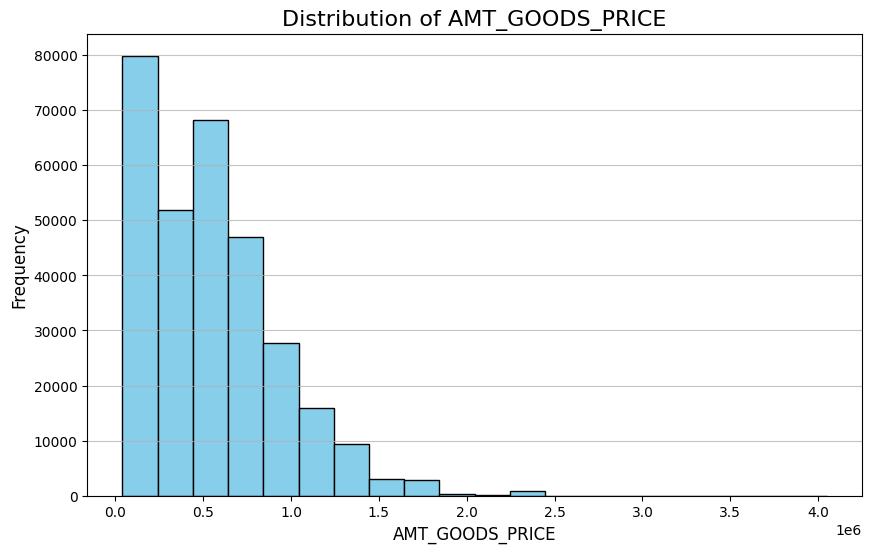

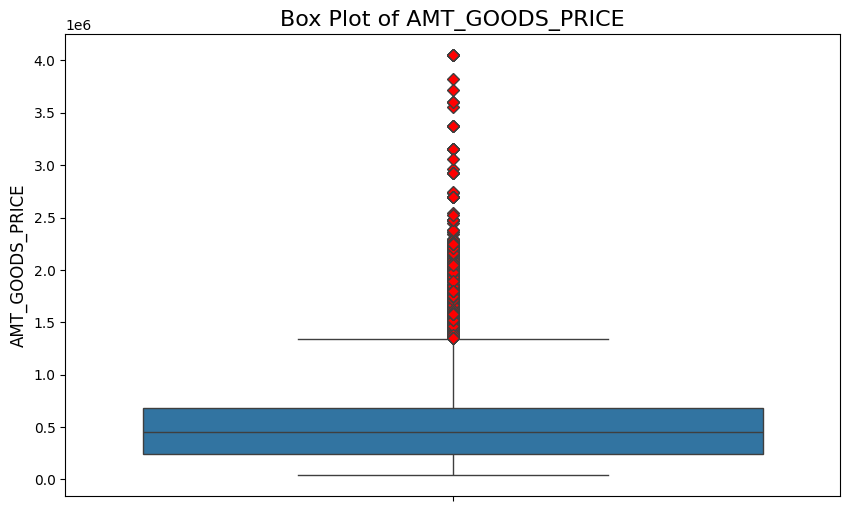

In [405]:
analyze_column_0_to_1_missing(df,"AMT_GOODS_PRICE")

Observation

The distribution analysis reveals the following insights:

*   Null Percentage: 0.09% (very small and not signification)

*   Skewness: The distribution is positively skewed (right-skewed), as indicated by the mean being greater than the median and the presence of high-value outliers.

*   Median: 450000.0.

*   Mode: 450000.0.

*   Mean: 538396.207.

*   Outliers: Several extreme values are present in the dataset.

Recommendation:
Based on the obtained results, missing data should be replaced with the median, as it is robust to outliers and represents the majority of observations effectively. Given the minimal percentage of missing values (0.09%), this approach is unlikely to introduce bias or distort the dataset while maintaining its integrity.

In [406]:
df["AMT_GOODS_PRICE"]=df["AMT_GOODS_PRICE"].fillna(df['AMT_GOODS_PRICE'].median())

In [407]:
df["AMT_GOODS_PRICE"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 307511 entries, 0 to 307510
Series name: AMT_GOODS_PRICE
Non-Null Count   Dtype  
--------------   -----  
307511 non-null  float64
dtypes: float64(1)
memory usage: 2.3 MB


### **Analyze columns with invalid/unknown data values**

**Analyze of the CODE_GENDER column**

In [408]:
df['CODE_GENDER'].value_counts()

,count
CODE_GENDER,
F,202448
M,105059
XNA,4


Gender must be either male or female. The XNA value may indicate that the value was not provided by the applicant or was missed by the loan officer reviewing the application.

In [409]:
df[df["CODE_GENDER"]=='XNA']

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
35657,141289,0,Revolving loans,XNA,1,1,0,207000.00,382500.00,19125.00,...,0,0,0,0,0.00,0.00,0.00,0.00,0.00,1.00
38566,144669,0,Revolving loans,XNA,0,1,2,157500.00,270000.00,13500.00,...,0,0,0,0,0.00,0.00,0.00,3.00,0.00,4.00
83382,196708,0,Revolving loans,XNA,0,1,1,135000.00,405000.00,20250.00,...,0,0,0,0,0.00,0.00,0.00,0.00,0.00,3.00
189640,319880,0,Revolving loans,XNA,1,1,0,247500.00,540000.00,27000.00,...,0,0,0,0,0.00,0.00,0.00,0.00,1.00,6.00


Since the data appears reliable and there are twice as many female applicants as male applicants, we can impute the missing or ambiguous 'XNA' values with 'F' to maintain consistency and reflect the observed gender distribution in the dataset.

In [410]:
df["CODE_GENDER"] = df["CODE_GENDER"].apply(lambda x: "F" if x == "XNA" else x)

Checking if `XNA is removed

In [411]:
df["CODE_GENDER"].value_counts()

,count
CODE_GENDER,
F,202452
M,105059


**Analyze of the DAYS_BIRTH column**

In [412]:
df['DAYS_BIRTH'].value_counts().head()

,count
DAYS_BIRTH,
-13749,43
-13481,42
-10020,41
-18248,41
-15771,40


In [413]:
df['DAYS_BIRTH'].unique()

array([ -9461, -16765, -19046, ...,  -7951,  -7857, -25061])

In [414]:
df['DAYS_BIRTH'].nunique()

17460

There are ~17K+ unique entries, all of which appear to have negative values.

In [415]:
df['DAYS_BIRTH'].describe()

,DAYS_BIRTH
count,307511.00
mean,-16037.00
std,4363.99
min,-25229.00
25%,-19682.00
50%,-15750.00
75%,-12413.00
max,-7489.00


Convert Days Birth to positive days

In [416]:
df['DAYS_BIRTH'] = df['DAYS_BIRTH'].apply(lambda x: -x if x < 0 else x)

In [417]:
df['DAYS_BIRTH'].describe()

,DAYS_BIRTH
count,307511.00
mean,16037.00
std,4363.99
min,7489.00
25%,12413.00
50%,15750.00
75%,19682.00
max,25229.00


All days in DAYS_BIRTH have positive values ​​- this may be more convenient for analysis.

**Create a new column YEARS_BIRTH for ease of analysis**

In [418]:
df['YEARS_BIRTH'] = df['DAYS_BIRTH'].apply(lambda x: round(x/365))

In [419]:
df['YEARS_BIRTH'].value_counts().head()

,count
YEARS_BIRTH,
39,9023
38,8793
37,8727
40,8602
41,8495


**Analyze of the NAME_FAMILY_STATUS column**

In [420]:
df['NAME_FAMILY_STATUS'].value_counts()

,count
NAME_FAMILY_STATUS,
Married,196432
Single / not married,45444
Civil marriage,29775
Separated,19770
Widow,16088
Unknown,2


In [421]:
df['NAME_FAMILY_STATUS'].value_counts(normalize = True) * 100

,proportion
NAME_FAMILY_STATUS,
Married,63.88
Single / not married,14.78
Civil marriage,9.68
Separated,6.43
Widow,5.23
Unknown,0.00


In [422]:
df[df['NAME_FAMILY_STATUS'] == 'Unknown']

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,YEARS_BIRTH
41982,148605,0,Revolving loans,M,0,1,0,450000.00,675000.00,33750.00,...,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,34
187348,317181,0,Revolving loans,F,0,1,0,202500.00,585000.00,29250.00,...,0,0,0,0.00,0.00,0.00,0.00,0.00,1.00,35


Since the data looks reliable, we will continue to test the implication method. Married applicants make up over 63% of applicants. So, we will equate NAME_FAMILY_STATUS to Married.

In [423]:
df["NAME_FAMILY_STATUS"] = df["NAME_FAMILY_STATUS"].apply(lambda status: "Married" if status == "Unknown" else status)

Check if Unknown is removed

In [424]:
df['NAME_FAMILY_STATUS'].value_counts()

,count
NAME_FAMILY_STATUS,
Married,196434
Single / not married,45444
Civil marriage,29775
Separated,19770
Widow,16088


**Analyze of the DAYS_EMPLOYED column**

In [425]:
df["DAYS_EMPLOYED"].value_counts().head()

,count
DAYS_EMPLOYED,
365243,55374
-200,156
-224,152
-230,151
-199,151


In [426]:
df["DAYS_EMPLOYED"].value_counts(normalize=True)*100

,proportion
DAYS_EMPLOYED,
365243,18.01
-200,0.05
-224,0.05
-230,0.05
-199,0.05
...,...
-11471,0.00
-12878,0.00
-10573,0.00


In [427]:
df['DAYS_EMPLOYED'].unique()

array([  -637,  -1188,   -225, ..., -12971, -11084,  -8694])

In [428]:
df['DAYS_EMPLOYED'].nunique()

12574

**Observation**

*   There are ~55K+ records for which DAYS_EMPLOYED is 365243 days
*   The remaining 252K+ records have a negative value of days
*   There are 12,574 unique values ​​for `DAYS_EMPLOYED

The DAYS_EMPLOYED column indicates how many days before the application date the person started their current job, the applicant/loan officer should enter negative values ​​to indicate days prior to the application date.
We convert negative values ​​in DAYS_EMPLOYED to positive days to standardize days when used in calculations

In [429]:
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].apply(lambda x: -x if x < 0 else x)

In [430]:
df['DAYS_EMPLOYED'].value_counts().head()

,count
DAYS_EMPLOYED,
365243,55374
200,156
224,152
230,151
199,151


We see that all days in DAYS_EMPLOYED are positive.
For ~55K+ records, DAYS_EMPLOYED is 365243 days

*   Converting this to years, we get 1000 years that are physically impossible to use to employ the applicant
*   This corresponds to 18% of the data and cannot be an anomaly
*   They could be either "retired" or "unemployed", and looking at the data, our conclusion is correct

There are two ways to handle this

*   We leave the data as is and take this into account in the analysis
*   We calculate the average number of days of employment excluding this category and enter it instead of 365243 days for pensioners.
For the unemployed, the number of days of employment can be 0

In [431]:
df[df['DAYS_EMPLOYED'] == 365243].NAME_INCOME_TYPE.value_counts()

,count
NAME_INCOME_TYPE,
Pensioner,55352
Unemployed,22


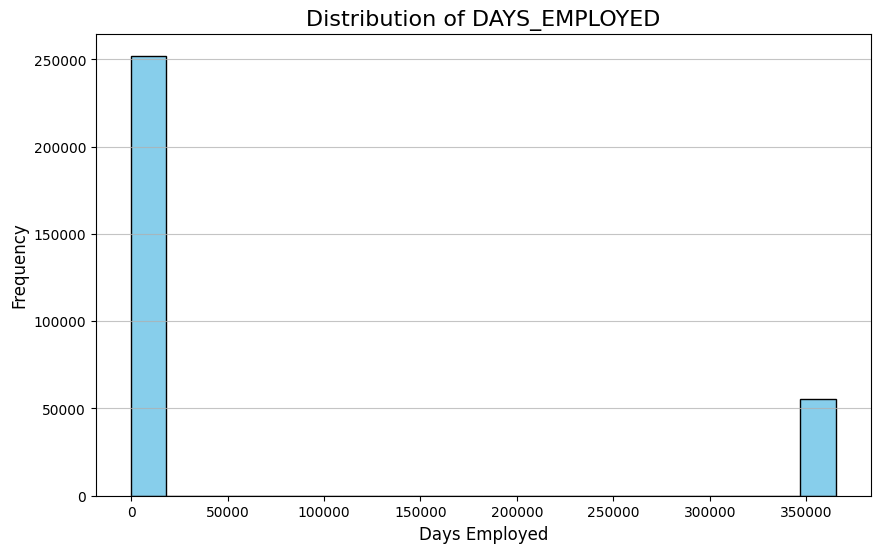

In [432]:
plt.figure(figsize=(10, 6))
plt.hist(df['DAYS_EMPLOYED'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of DAYS_EMPLOYED', fontsize=16)
plt.xlabel('Days Employed', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.show()

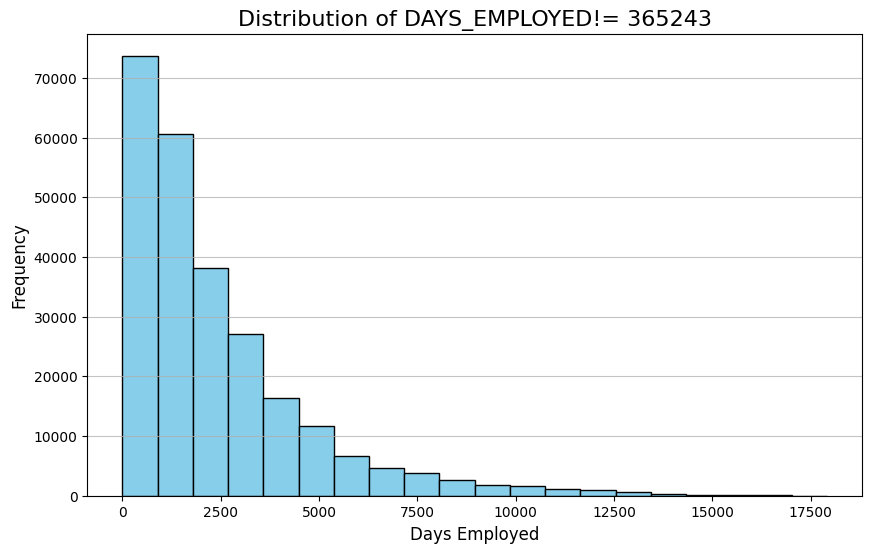

In [433]:
plt.figure(figsize=(10, 6))
plt.hist(df[df['DAYS_EMPLOYED'] != 365243].DAYS_EMPLOYED, bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of DAYS_EMPLOYED!= 365243', fontsize=16)
plt.xlabel('Days Employed', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.show()

In [434]:
df['DAYS_EMPLOYED'].describe()

,DAYS_EMPLOYED
count,307511.00
mean,67724.74
std,139443.75
min,0.00
25%,933.00
50%,2219.00
75%,5707.00
max,365243.00


In [435]:
df[df['DAYS_EMPLOYED'] == 365243].DAYS_EMPLOYED.value_counts()

,count
DAYS_EMPLOYED,
365243,55374


In [436]:
median = df['DAYS_EMPLOYED'].median()

Using a constant to fill in 55K gaps will skew the data very much.

In [437]:
df_days_emp = df.DAYS_EMPLOYED.apply(lambda x: x if x != 365243 else median)

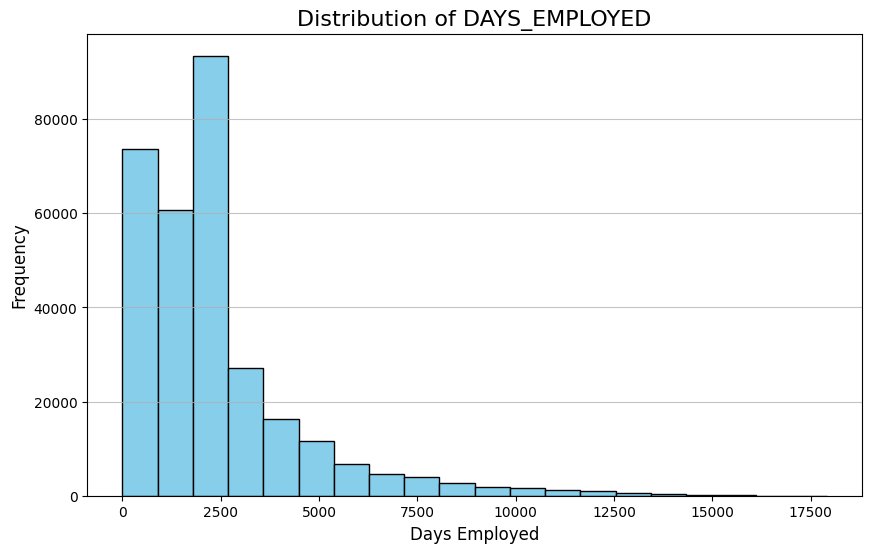

In [438]:
plt.figure(figsize=(10, 6))
plt.hist(df_days_emp, bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of DAYS_EMPLOYED', fontsize=16)
plt.xlabel('Days Employed', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.show()

Let's create a new column YEARS_EMPLOYED for ease of analysis

In [439]:
df['YEARS_EMPLOYED'] = df.DAYS_EMPLOYED.apply(lambda x: round(x/365))

**Analyze of the DAYS_REGISTRATION column**

In [440]:
df['DAYS_REGISTRATION'].value_counts().head()

,count
DAYS_REGISTRATION,
-1.00,113
-7.00,98
-6.00,96
-4.00,92
-2.00,92


In [441]:
df['DAYS_REGISTRATION'].value_counts(normalize = True).head()

,proportion
DAYS_REGISTRATION,
-1.00,0.00
-7.00,0.00
-6.00,0.00
-4.00,0.00
-2.00,0.00


In [442]:
df['DAYS_REGISTRATION'].unique()

array([ -3648.,  -1186.,  -4260., ..., -16396., -14558., -14798.])

In [443]:
df['DAYS_REGISTRATION'].nunique()

15688

In [444]:
df['DAYS_REGISTRATION'] = df['DAYS_REGISTRATION'].apply(lambda x: -x if x < 0 else x)

In [445]:
df['DAYS_REGISTRATION'].value_counts().head()

,count
DAYS_REGISTRATION,
1.00,113
7.00,98
6.00,96
4.00,92
2.00,92


All days in DAYS_REGISTRATION have positive values

**Let's create a new column YEARS_REGISTRATION for ease of analysis**

In [446]:
df['YEARS_REGISTRATION'] = df['DAYS_REGISTRATION'].apply(lambda x: round(x/365))

**Analyze of the DAYS_ID_PUBLISH column**

In [447]:
df['DAYS_ID_PUBLISH'].value_counts().head()

,count
DAYS_ID_PUBLISH,
-4053,169
-4095,162
-4046,161
-4417,159
-4256,158


In [448]:
df['DAYS_ID_PUBLISH'].value_counts(normalize = True).head()

,proportion
DAYS_ID_PUBLISH,
-4053,0.00
-4095,0.00
-4046,0.00
-4417,0.00
-4256,0.00


In [449]:
df['DAYS_ID_PUBLISH'].unique()

array([-2120,  -291, -2531, ..., -6194, -5854, -6211])

In [450]:
df['DAYS_ID_PUBLISH'].nunique()

6168

Converting DAYS_ID_PUBLISH to positive numbers

In [451]:
df['DAYS_ID_PUBLISH'] = df['DAYS_ID_PUBLISH'].apply(lambda x: -x if x < 0 else x)

In [452]:
df['DAYS_ID_PUBLISH'].value_counts().head()

,count
DAYS_ID_PUBLISH,
4053,169
4095,162
4046,161
4417,159
4256,158


**Let's create a new column YEARS_ID_PUBLISH for ease of analysis**

In [453]:
df['YEARS_ID_PUBLISH'] = df['DAYS_ID_PUBLISH'].apply(lambda x: round(x/365))

**Analyze of the DAYS_LAST_PHONE_CHANGE column**

In [454]:
df['DAYS_LAST_PHONE_CHANGE'].value_counts().head()

,count
DAYS_LAST_PHONE_CHANGE,
0.00,37672
-1.00,2812
-2.00,2318
-3.00,1763
-4.00,1285


In [455]:
df['DAYS_LAST_PHONE_CHANGE'].value_counts(normalize = True).head()

,proportion
DAYS_LAST_PHONE_CHANGE,
0.00,0.12
-1.00,0.01
-2.00,0.01
-3.00,0.01
-4.00,0.00


In [456]:
df['DAYS_LAST_PHONE_CHANGE'].unique()

array([-1134.,  -828.,  -815., ..., -3988., -3899., -3538.])

In [457]:
df['DAYS_LAST_PHONE_CHANGE'].nunique()

3773

Convert DAYS_LAST_PHONE_CHANGE to positive days

In [458]:
df['DAYS_LAST_PHONE_CHANGE'] = df['DAYS_LAST_PHONE_CHANGE'].apply(lambda x: -x if x < 0 else x)

In [459]:
df['DAYS_LAST_PHONE_CHANGE'].value_counts().head()

,count
DAYS_LAST_PHONE_CHANGE,
0.00,37672
1.00,2812
2.00,2318
3.00,1763
4.00,1285


**Creating a new column YEARS_LAST_PHONE_CHANGE for easier analysis**

In [460]:
df['YEARS_LAST_PHONE_CHANGE'] = df['DAYS_LAST_PHONE_CHANGE'].apply(lambda x: round(x/365,0))

**Analyze of the CNT_CHILDREN column**

In [461]:
df['CNT_CHILDREN'].value_counts().sort_values(ascending = False).head()

,count
CNT_CHILDREN,
0,215371
1,61119
2,26749
3,3717
4,429


In [462]:
(df['CNT_CHILDREN'].value_counts(normalize = True).sort_values(ascending = False) * 100)

,proportion
CNT_CHILDREN,
0,70.04
1,19.88
2,8.70
3,1.21
4,0.14
5,0.03
6,0.01
7,0.00
14,0.00


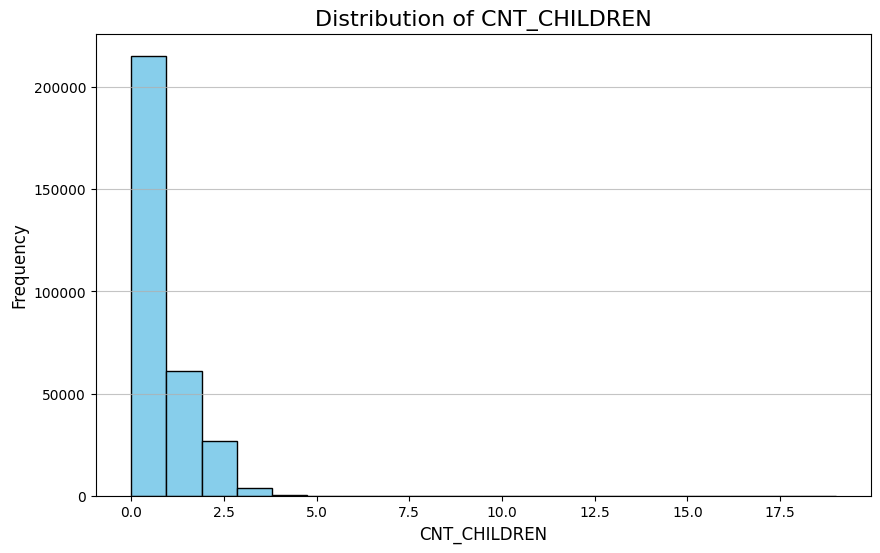

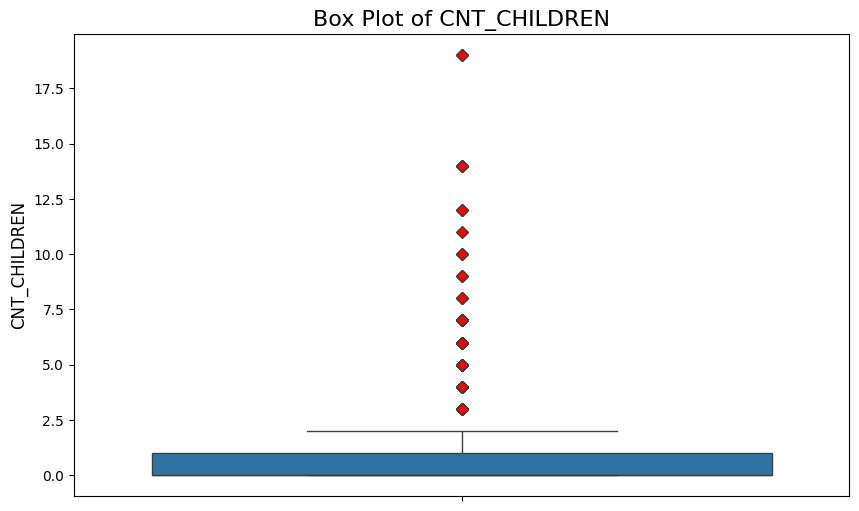

In [463]:
dist_box(df,'CNT_CHILDREN')

In [464]:
calculate_outlier_bounds(df,"CNT_CHILDREN")

IQR: 1.0
Minimum value after which emissions exist: -1.5
Maximum value after which emissions exist: 2.5


In [465]:
df[df.CNT_CHILDREN.isin(range(10,20))]["YEARS_BIRTH"]

,YEARS_BIRTH
34545,47
80948,39
132585,31
155369,30
171125,38
176011,49
183878,56
186820,41
265784,28
267998,42


In [466]:
df[df['CNT_CHILDREN'].isin([10])][['SK_ID_CURR', 'CNT_CHILDREN', 'YEARS_BIRTH']]

,SK_ID_CURR,CNT_CHILDREN,YEARS_BIRTH
132585,253779,10,31
186820,316580,10,41


**Observation:**
The data reveals that the number of applicants with more than 7 children is extremely low, with only 2 or 3 applicants in each category. Specifically, for applicants with 10 children, the data shows only two individuals aged 31 and 41, making this an isolated and exceptional case.

Both the distribution and box plots indicate that values greater than 2.5 children are statistical outliers.

**Conclusion:**
Applicants with 3 or more children can be classified as outliers. To ensure accurate analysis, these cases should be flagged for separate, detailed analysis to better understand their unique characteristics and potential implications for the dataset.

**Analyze of the AMT_INCOME_TOTAL column**

In [467]:
df['AMT_INCOME_TOTAL'].value_counts().sort_values(ascending = False).head()

,count
AMT_INCOME_TOTAL,
135000.00,35750
112500.00,31019
157500.00,26556
180000.00,24719
90000.00,22483


In [468]:
(df['AMT_INCOME_TOTAL'].value_counts(normalize = True).sort_values(ascending = False) * 100).head()

,proportion
AMT_INCOME_TOTAL,
135000.00,11.63
112500.00,10.09
157500.00,8.64
180000.00,8.04
90000.00,7.31


In [469]:
df['AMT_INCOME_TOTAL'].describe(percentiles = [0.75,0.99,0.999])

,AMT_INCOME_TOTAL
count,307511.00
mean,168797.92
std,237123.15
min,25650.00
50%,147150.00
75%,202500.00
99%,472500.00
99.9%,900000.00
max,117000000.00


In [470]:
calculate_outlier_bounds(df,"AMT_INCOME_TOTAL")

IQR: 90000.0
Minimum value after which emissions exist: -22500.0
Maximum value after which emissions exist: 337500.0


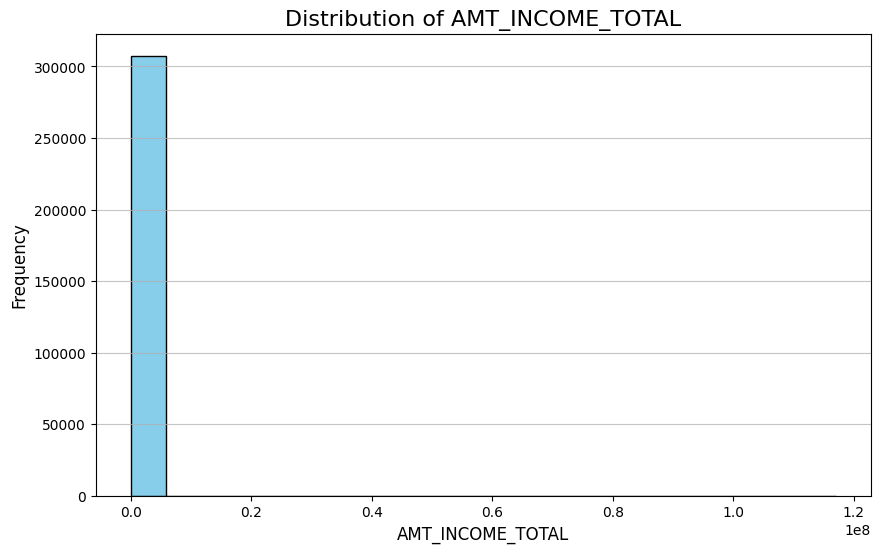

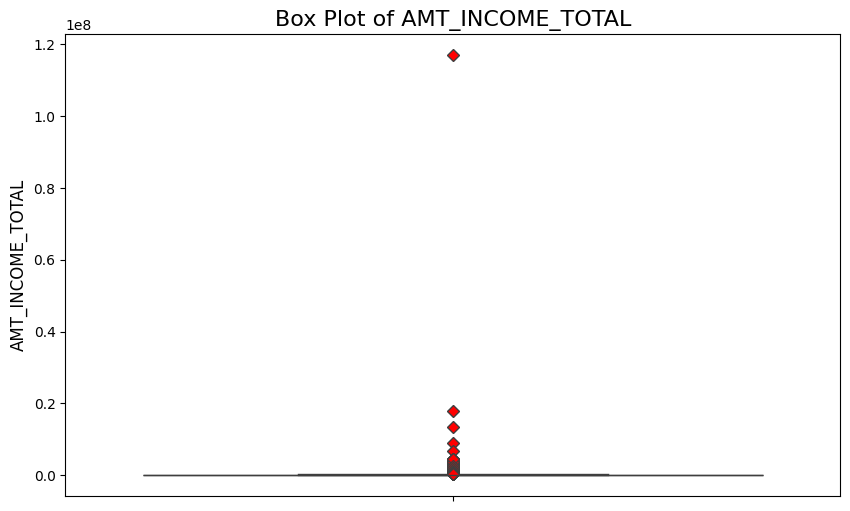

In [471]:
dist_box(df,'AMT_INCOME_TOTAL')

The final result graphs are very thin and we can see an outlier around 120 million.
Plot the graph looking only at the income below 99.9% of the value, that is 900 thousand.

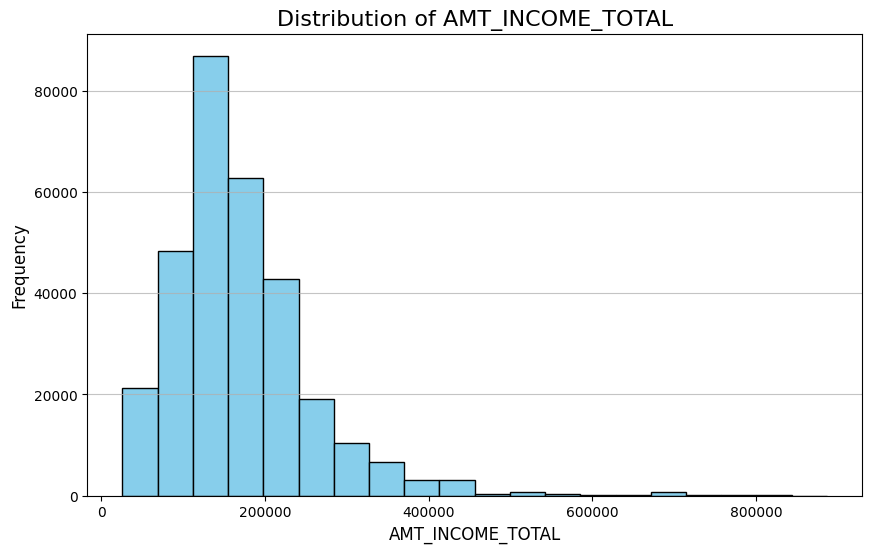

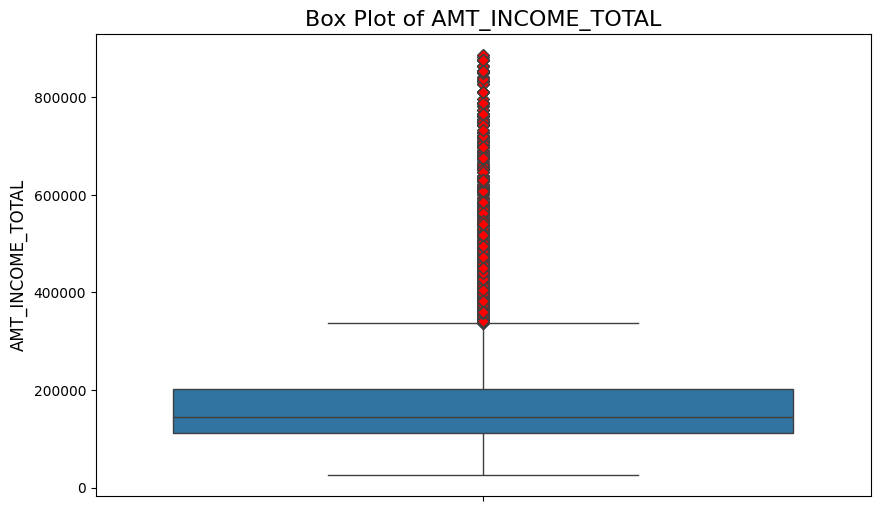

In [472]:
dist_box(df[df['AMT_INCOME_TOTAL'] < 900000],'AMT_INCOME_TOTAL')

Now we can clearly see the distribution and range of data on both graphs. This means that the value of more than UAH 900 thousand in income is clearly an outlier.

In [473]:
df[df['AMT_INCOME_TOTAL'] > 900000].head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,YEARS_BIRTH,YEARS_EMPLOYED,YEARS_REGISTRATION,YEARS_ID_PUBLISH,YEARS_LAST_PHONE_CHANGE
1504,101769,0,Revolving loans,M,1,1,0,1080000.00,180000.00,9000.00,...,0.00,0.00,0.00,0.00,0.00,37,15,0,14,1.00
1723,102015,0,Cash loans,F,0,1,0,1935000.00,269550.00,10534.50,...,0.00,0.00,0.00,0.00,0.00,51,1001,9,6,1.00
3371,103938,0,Cash loans,F,0,0,1,1350000.00,2410380.00,109053.00,...,0.00,0.00,3.00,0.00,0.00,33,2,2,11,0.00
4603,105384,0,Revolving loans,F,1,1,0,1350000.00,405000.00,20250.00,...,0.00,0.00,0.00,0.00,0.00,40,13,10,11,0.00
5673,106637,0,Cash loans,M,1,1,3,967500.00,450000.00,30073.50,...,0.00,0.00,1.00,1.00,0.00,33,1,8,1,0.00


**Observation**

Looking at the data, we see that incomes over 900k (99.9% value) are outliers. Both the distribution chart and the box plot clearly show us the same trend.

**Conclusion**
Applicants with incomes over 900k (99.9% value) are outliers

**Analyze of the CNT_FAM_MEMBERS column**

In [474]:
df["CNT_FAM_MEMBERS"].dtype

dtype('float64')

In [475]:
df.CNT_FAM_MEMBERS.value_counts().sort_values(ascending=False)

,count
CNT_FAM_MEMBERS,
2.00,158357
1.00,67847
3.00,52601
4.00,24697
5.00,3478
6.00,408
7.00,81
8.00,20
9.00,6


In [476]:
df.CNT_FAM_MEMBERS.value_counts(normalize=True).sort_values(ascending=False) * 100

,proportion
CNT_FAM_MEMBERS,
2.00,51.50
1.00,22.06
3.00,17.11
4.00,8.03
5.00,1.13
6.00,0.13
7.00,0.03
8.00,0.01
9.00,0.00


In [477]:
df['CNT_FAM_MEMBERS'].describe(percentiles = [0.75,0.99,0.999])

,CNT_FAM_MEMBERS
count,307509.00
mean,2.15
std,0.91
min,1.00
50%,2.00
75%,3.00
99%,5.00
99.9%,6.00
max,20.00


In [478]:
calculate_outlier_bounds(df,"CNT_FAM_MEMBERS")

IQR: 1.0
Minimum value after which emissions exist: 0.5
Maximum value after which emissions exist: 4.5


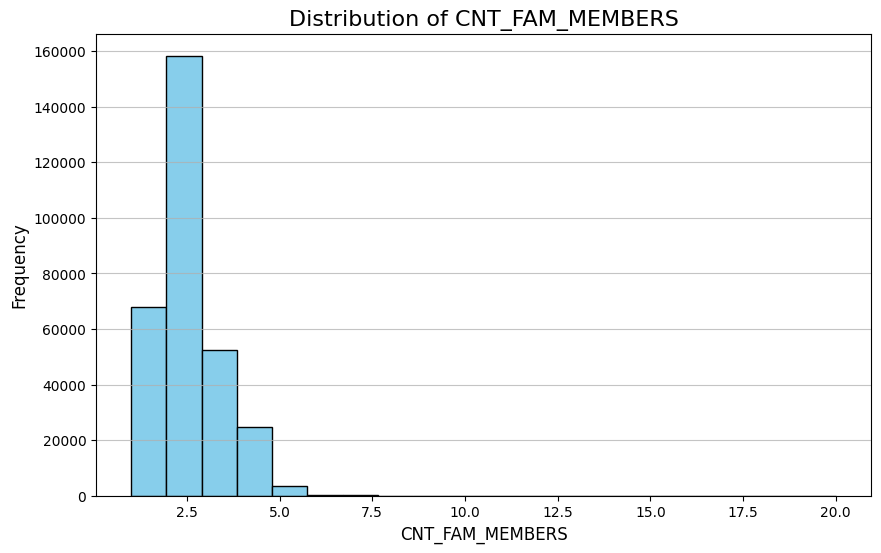

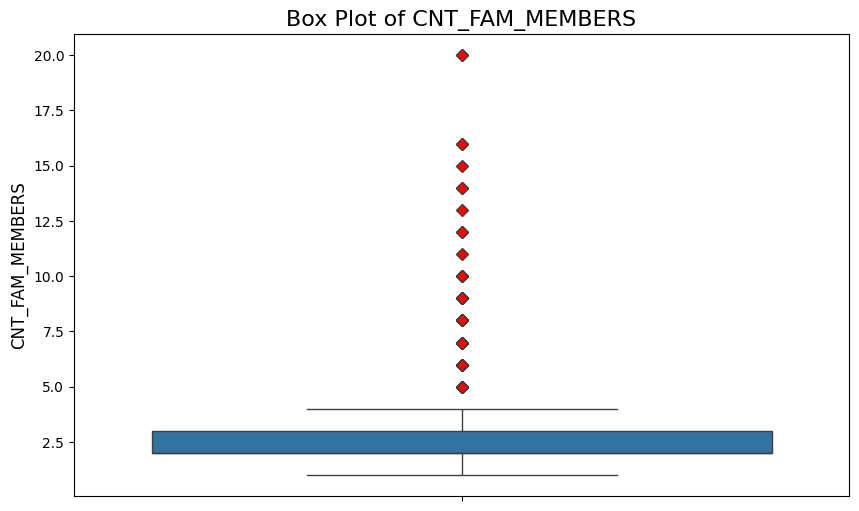

In [479]:
dist_box(df,"CNT_FAM_MEMBERS")

**Observation**
From the distribution plot and box plot, it is clear that there are outliers in the data. Based on the calculated upper and lower whiskers, families with more than 5 members are classified as outliers.


**Conclusion**
For data where the number of family members is more than 5, can then be removed from the dataset or we can perform a special analysis for these outliers.

**Analyze of the AMT_ANNUITY column**

In [480]:
df["AMT_ANNUITY"].dtype

dtype('float64')

In [481]:
df["AMT_ANNUITY"].value_counts().head()

,count
AMT_ANNUITY,
9000.00,6385
13500.00,5514
6750.00,2279
10125.00,2035
37800.00,1602


In [482]:
(df["AMT_ANNUITY"].value_counts(normalize = True).sort_values(ascending = False)*100).head()

,proportion
AMT_ANNUITY,
9000.00,2.08
13500.00,1.79
6750.00,0.74
10125.00,0.66
37800.00,0.52


In [483]:
df['AMT_ANNUITY'].describe(percentiles = [0.75,0.99,0.999])

,AMT_ANNUITY
count,307499.00
mean,27108.57
std,14493.74
min,1615.50
50%,24903.00
75%,34596.00
99%,70006.50
99.9%,110047.50
max,258025.50


In [484]:
calculate_outlier_bounds(df,"AMT_ANNUITY")

IQR: 18072.0
Minimum value after which emissions exist: -10584.0
Maximum value after which emissions exist: 61704.0


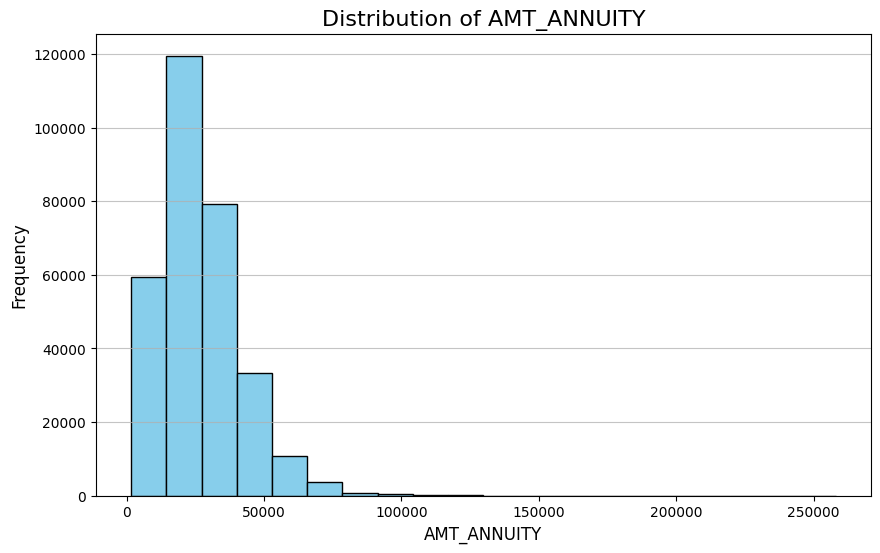

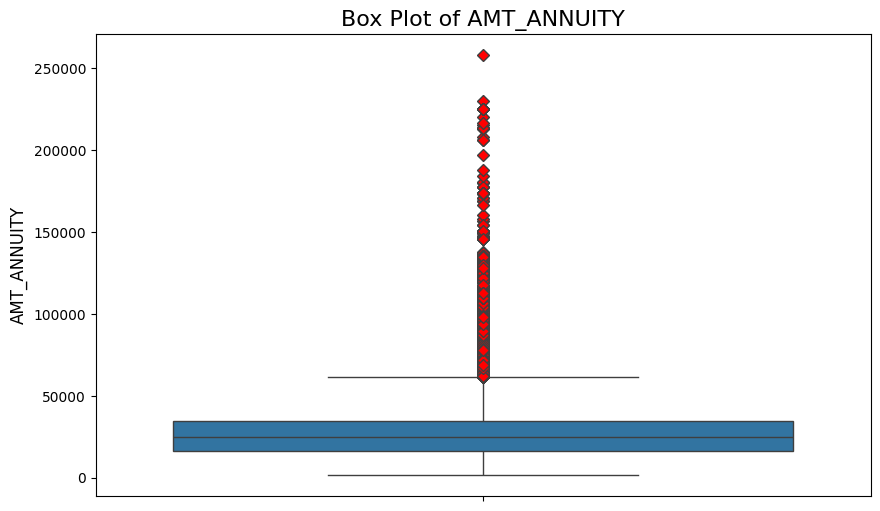

In [485]:
dist_box(df,"AMT_ANNUITY")

**Observation**
From the boxplot we can see that there are outliers in the data. We can also see that there is a small portion of the data (0.1%) that has exceptionally high annuities (above the 99.9th percentile). The 99.9th percentile is 110047.50.


**Conclusion**
Values ​​above the 9.9th percentile are outliers and can then be removed from the dataset or we can perform a special analysis for these outliers.

### **Binning continuous columns**

**Categorize the "AMT_GOODS_PRICE" column**

In [486]:
df['AMT_GOODS_PRICE'].value_counts().sort_values(ascending = False).head()

,count
AMT_GOODS_PRICE,
450000.00,26300
225000.00,25282
675000.00,24962
900000.00,15416
270000.00,11428


In [487]:
(df['AMT_GOODS_PRICE'].value_counts(normalize = True).sort_values(ascending = False) * 100).head()

,proportion
AMT_GOODS_PRICE,
450000.00,8.55
225000.00,8.22
675000.00,8.12
900000.00,5.01
270000.00,3.72


In [488]:
df['AMT_GOODS_PRICE'].describe(percentiles = [0.25,0.75,0.99,0.9999])

,AMT_GOODS_PRICE
count,307511.00
mean,538316.29
std,369288.98
min,40500.00
25%,238500.00
50%,450000.00
75%,679500.00
99%,1800000.00
99.99%,2933964.00
max,4050000.00


Let's divide the values ​​in AMT_GOODS_PRICE into 5 bins and create a new column AMT_GOODS_PRICE_CATEGORY.

In [489]:
df['AMT_GOODS_PRICE_CATEGORY'] = pd.cut(df['AMT_GOODS_PRICE'],
                                        bins = 5, labels = ['very low', 'low', 'medium', 'high', 'very high'])

Check that values ​​are filled in as expected

In [490]:
df['AMT_GOODS_PRICE_CATEGORY'].value_counts()

,count
AMT_GOODS_PRICE_CATEGORY,
very low,247251
low,56087
medium,4108
high,47
very high,18


### **Categorizing the YEARS_BIRTH column**

Сhange DAYS_BIRTH to YEARS_BIRTH since years are easier to interpret than days.

In [491]:
df['YEARS_BIRTH'].value_counts().sort_values(ascending = False).head()

,count
YEARS_BIRTH,
39,9023
38,8793
37,8727
40,8602
41,8495


In [492]:
(df['YEARS_BIRTH'].value_counts(normalize = True).sort_values(ascending = False) * 100).head()

,proportion
YEARS_BIRTH,
39,2.93
38,2.86
37,2.84
40,2.80
41,2.76


In [493]:
df['YEARS_BIRTH'].describe(percentiles = [0.25,0.75,0.99,0.9999])

,YEARS_BIRTH
count,307511.00
mean,43.94
std,11.96
min,21.00
25%,34.00
50%,43.00
75%,54.00
99%,67.00
99.99%,69.00
max,69.00


Categorize the value from YEARS_BIRTH into a new column YEARS_BIRTH_CATEGORY.

In [494]:
def age_cat(years):
    """
    Categorizes a given number of years into an age range category.

    Parameters:
    years (int): The age in years to be categorized.

    Returns:
    str: The corresponding age range category:
         '0-20', '20-30', '30-40', '40-50', '50-60', '60-70', or '70+'.
    """

    age_ranges = [
        (0, 20, '0-20'),
        (21, 30, '20-30'),
        (31, 40, '30-40'),
        (41, 50, '40-50'),
        (51, 60, '50-60'),
        (61, 70, '60-70'),
        (71, float('inf'), '70+')
    ]

    for lower, upper, category in age_ranges:
        if lower <= years <= upper:
            return category

In [495]:
df['YEARS_BIRTH_CATEGORY'] = df['YEARS_BIRTH'].apply(age_cat)

In [496]:
df['YEARS_BIRTH_CATEGORY'].value_counts().sort_values(ascending = False)

,count
YEARS_BIRTH_CATEGORY,
30-40,82770
40-50,75509
50-60,67955
20-30,48869
60-70,32408


### **Categorizing the YEARS_REGISTRATION column**

Сhange DAYS_REGISTRATION to YEARS_REGISTRATION since years are easier to interpret than days.

In [497]:
df['YEARS_REGISTRATION'].value_counts().sort_values(ascending = False).head()

,count
YEARS_REGISTRATION,
1,15661
2,15564
3,13894
13,12866
12,12697


In [498]:
(df['YEARS_REGISTRATION'].value_counts(normalize = True).sort_values(ascending = False) * 100).head()

,proportion
YEARS_REGISTRATION,
1,5.09
2,5.06
3,4.52
13,4.18
12,4.13


In [499]:
df['YEARS_REGISTRATION'].describe(percentiles = [0.25,0.75,0.99,0.9999])

,YEARS_REGISTRATION
count,307511.00
mean,13.66
std,9.66
min,0.00
25%,6.00
50%,12.00
75%,20.00
99%,38.00
99.99%,54.25
max,68.00


In [500]:
df['YEARS_REGISTRATION_CATEGORY'] = df['YEARS_REGISTRATION'].apply(age_cat)

In [501]:
df['YEARS_REGISTRATION_CATEGORY'].value_counts().sort_values(ascending = False)

,count
YEARS_REGISTRATION_CATEGORY,
0-20,230697
20-30,59288
30-40,16051
40-50,1406
50-60,60
60-70,9


### **Saving updated data with compression**

In [502]:
filename = "/content/application_data_processed"
compression_options = dict(method = 'zip', archive_name = f'{filename}.csv')
df.to_csv(f'{filename}.zip', compression = compression_options, index = False)

### **Checking for imbalance for the target column TARGET**

**Analyze of the TARGET column**

In [503]:
df['TARGET'].value_counts().sort_values(ascending = False)

,count
TARGET,
0,282686
1,24825


In [504]:
df['TARGET'].value_counts(normalize = True).sort_values(ascending = False) * 100

,proportion
TARGET,
0,91.93
1,8.07


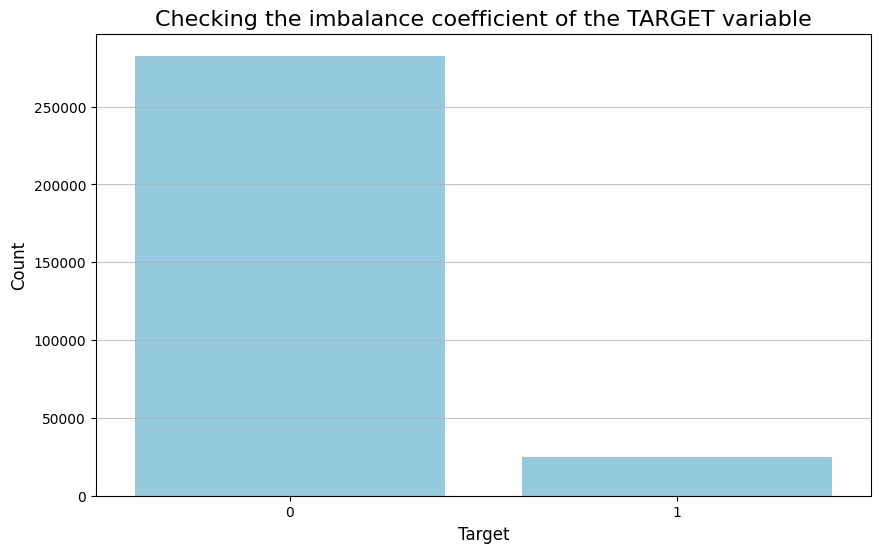

In [505]:
plt.figure(figsize=(10, 6))
sns.countplot(x = df['TARGET'], data = df, color='skyblue')
plt.title('Checking the imbalance coefficient of the TARGET variable', fontsize=16)
plt.xlabel("Target", fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.show()

**Observation**

We have an imbalance in the TARGET variable based on % of observations


*   TARGET = 1 - clients with payment difficulties: he/she had late payment more than X days on at least one of the first Y installments of the loan in our sample. These cases represent only 8.07% of the total dataset.
*   TARGET = 0 is all other cases except 1. These cases represent only 91.93% of the total dataset.

### **Data splitting based on "TARGET"**

Create a new DataFrame containing only rows where Target == 1

**TARGET = 1** means the client had payment difficulties: he/she had late payment more than X days on at least one of the first Y installments of the loan in our sample. These cases represent only 8.07% of the total dataset.

In [506]:
df1 = df[df['TARGET'] == 1]

In [507]:
df1.TARGET.value_counts()

,count
TARGET,
1,24825


Create a new DataFrame containing only rows where Target == 0

**TARGET = 0** is all other cases except 1. These cases represent only 91.93% of the total dataset.

In [508]:
df0 = df[df['TARGET'] == 0]

In [509]:
df0.TARGET.value_counts()

,count
TARGET,
0,282686


### **Univariate analysis of categorical variables**

**Analyze of the NAME_CONTRACT_TYPE column**

In [510]:
import matplotlib.pyplot as plt


def bi_cat_countplot(df, column, hue_column):
  """
    Visualizes a categorical feature by showing both its normalized distribution
    and absolute count, split by the values in the hue column (e.g., TARGET).

    Parameters:
    -----------
    df : pd.DataFrame
        The input dataframe containing the data.

    column : str
        The name of the categorical feature to visualize.

    hue_column : str
        The column to split the analysis by (usually the target variable, e.g., 'TARGET').

    Returns:
    --------
    None
        This function only produces matplotlib visualizations and does not return any value.
  """
  unique_hue_values = df[hue_column].unique()
  fig, axes = plt.subplots(nrows=1, ncols=2)
  fig.set_size_inches(14,6)

  pltname = f'Normalized distribution of values ​​by category: {column}'
  proportions = df.groupby(hue_column)[column].value_counts(normalize=True)
  proportions = (proportions*100).round(2)
  ax = proportions.unstack(hue_column).sort_values(
      by=unique_hue_values[0], ascending=False
      ).plot.bar(ax=axes[0], title=pltname)

  for container in ax.containers:
      ax.bar_label(container)

  pltname = f'Number of data by category: {column}'
  counts = df.groupby(hue_column)[column].value_counts()
  ax = counts.unstack(hue_column).sort_values(
      by=unique_hue_values[0], ascending=False
      ).plot.bar(ax=axes[1], title=pltname)

  for container in ax.containers:
    ax.bar_label(container)

def uni_cat_target_compare(df, column):
  """
    Compares a categorical column against the binary TARGET variable using bar plots.

    Parameters:
    -----------
    df : pd.DataFrame
        The input dataframe.

    column : str
        The name of the categorical feature to compare with the TARGET variable.

    Returns:
    --------
    None
        This function only produces matplotlib visualizations and does not return any value.
    """
  bi_cat_countplot(df, column, hue_column='TARGET')



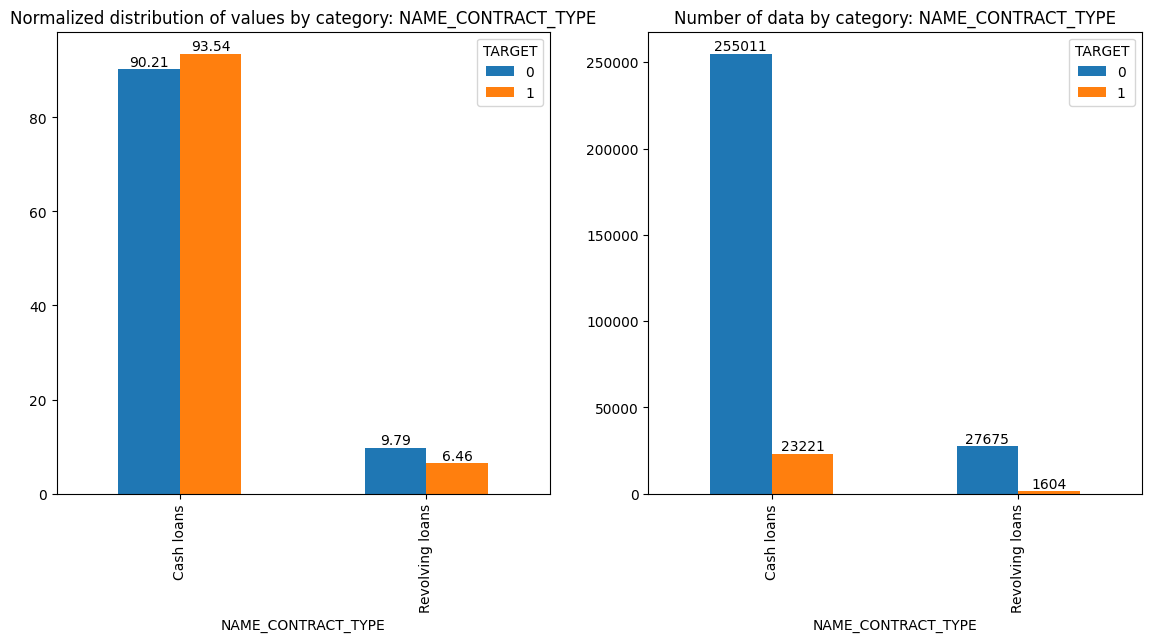

In [511]:
uni_cat_target_compare(df, 'NAME_CONTRACT_TYPE')

**Observation**

Looking at the histograms, we see no significant differences in NAME_CONTRACT_TYPE between customers who have difficulty paying and customers who pay on time in each contract type.

**Conclusion**

The NAME_CONTRACT_TYPE column does not provide any compelling evidence in favor of customers who have difficulty paying OR who pay on time.

**Analyze of the CODE_GENDER column**

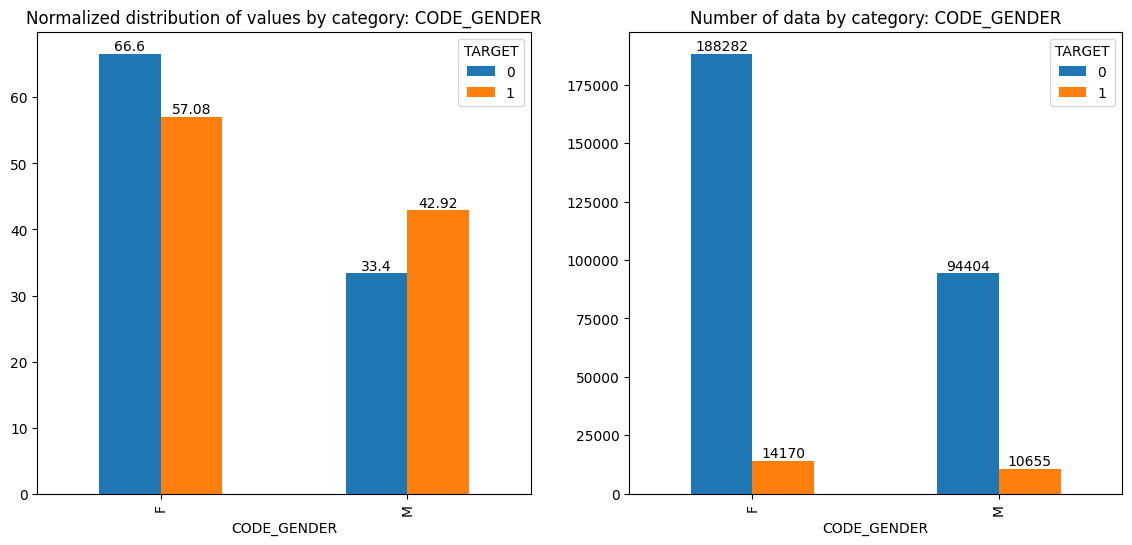

In [512]:
uni_cat_target_compare(df, 'CODE_GENDER')



**Observation**

Looking at the histograms, we see that both men and women maintain similar proportions among defaulters and non-defaulters.

**Conclusion**

The CODE_GENDER column does not provide any compelling evidence in favor of customers who have difficulty paying OR who pay on time.

**Analyze of the FLAG_OWN_CAR column**

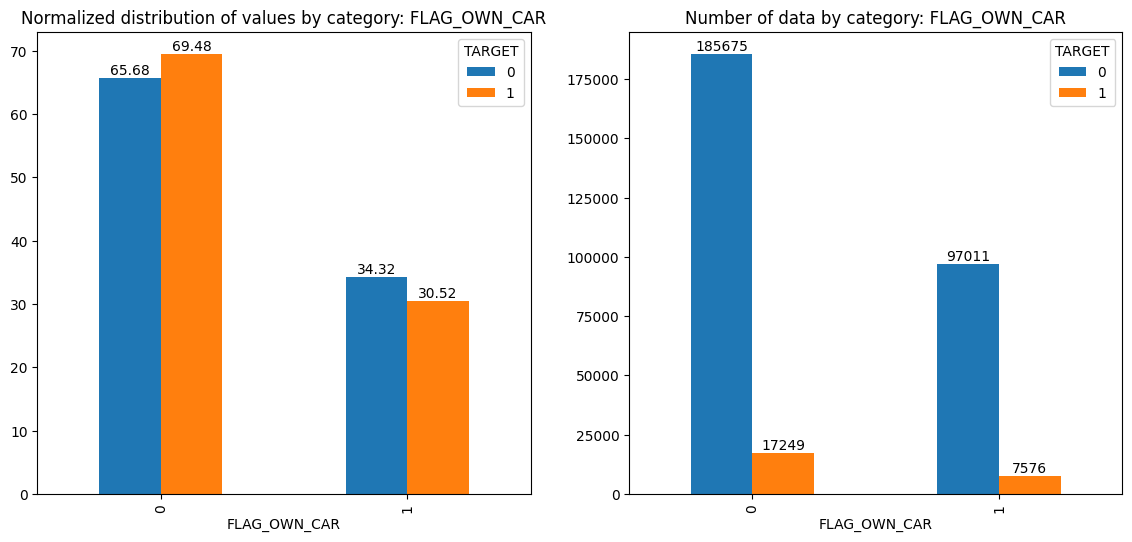

In [513]:
uni_cat_target_compare(df, 'FLAG_OWN_CAR')

**Observation**

Looking at the histograms, we can see that there are no significant differences in each FLAG_OWN_CAR group between customers who have difficulty paying and customers who pay on time.

**Conclusion**

The FLAG_OWN_CAR column does not provide any convincing evidence in favor of customers who have difficulty paying OR pay on time

### **Correlation analysis of numerical variables**

**Construct a correlation matrix for cases with payment difficulties**

In [514]:
df1.select_dtypes(include='number').shape

(24825, 67)

There are 67 numerical columns. Let's create a correlation matrix corr to better view the results.

In [515]:
corr_df1 = df1.select_dtypes(include='number').corr()

In [516]:
corr_df1.head()

,TARGET,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,...,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,YEARS_BIRTH,YEARS_EMPLOYED,YEARS_REGISTRATION,YEARS_ID_PUBLISH,YEARS_LAST_PHONE_CHANGE
TARGET,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_OWN_CAR,NaN,1.00,0.02,0.07,0.02,0.10,0.14,0.10,0.03,-0.07,...,-0.01,0.00,0.03,-0.01,-0.01,-0.07,-0.11,-0.07,0.02,0.05
FLAG_OWN_REALTY,NaN,0.02,1.00,0.02,0.01,-0.01,0.00,-0.02,0.03,0.11,...,-0.00,0.02,-0.00,0.02,0.06,0.11,0.06,0.01,-0.02,-0.03
CNT_CHILDREN,NaN,0.07,0.02,1.00,0.00,-0.00,0.03,-0.01,-0.03,-0.26,...,-0.01,-0.01,-0.01,-0.02,-0.04,-0.26,-0.19,-0.15,0.03,-0.01
AMT_INCOME_TOTAL,NaN,0.02,0.01,0.00,1.00,0.04,0.05,0.04,0.01,-0.00,...,-0.00,0.00,0.00,-0.00,0.00,-0.00,-0.01,0.00,0.00,0.00


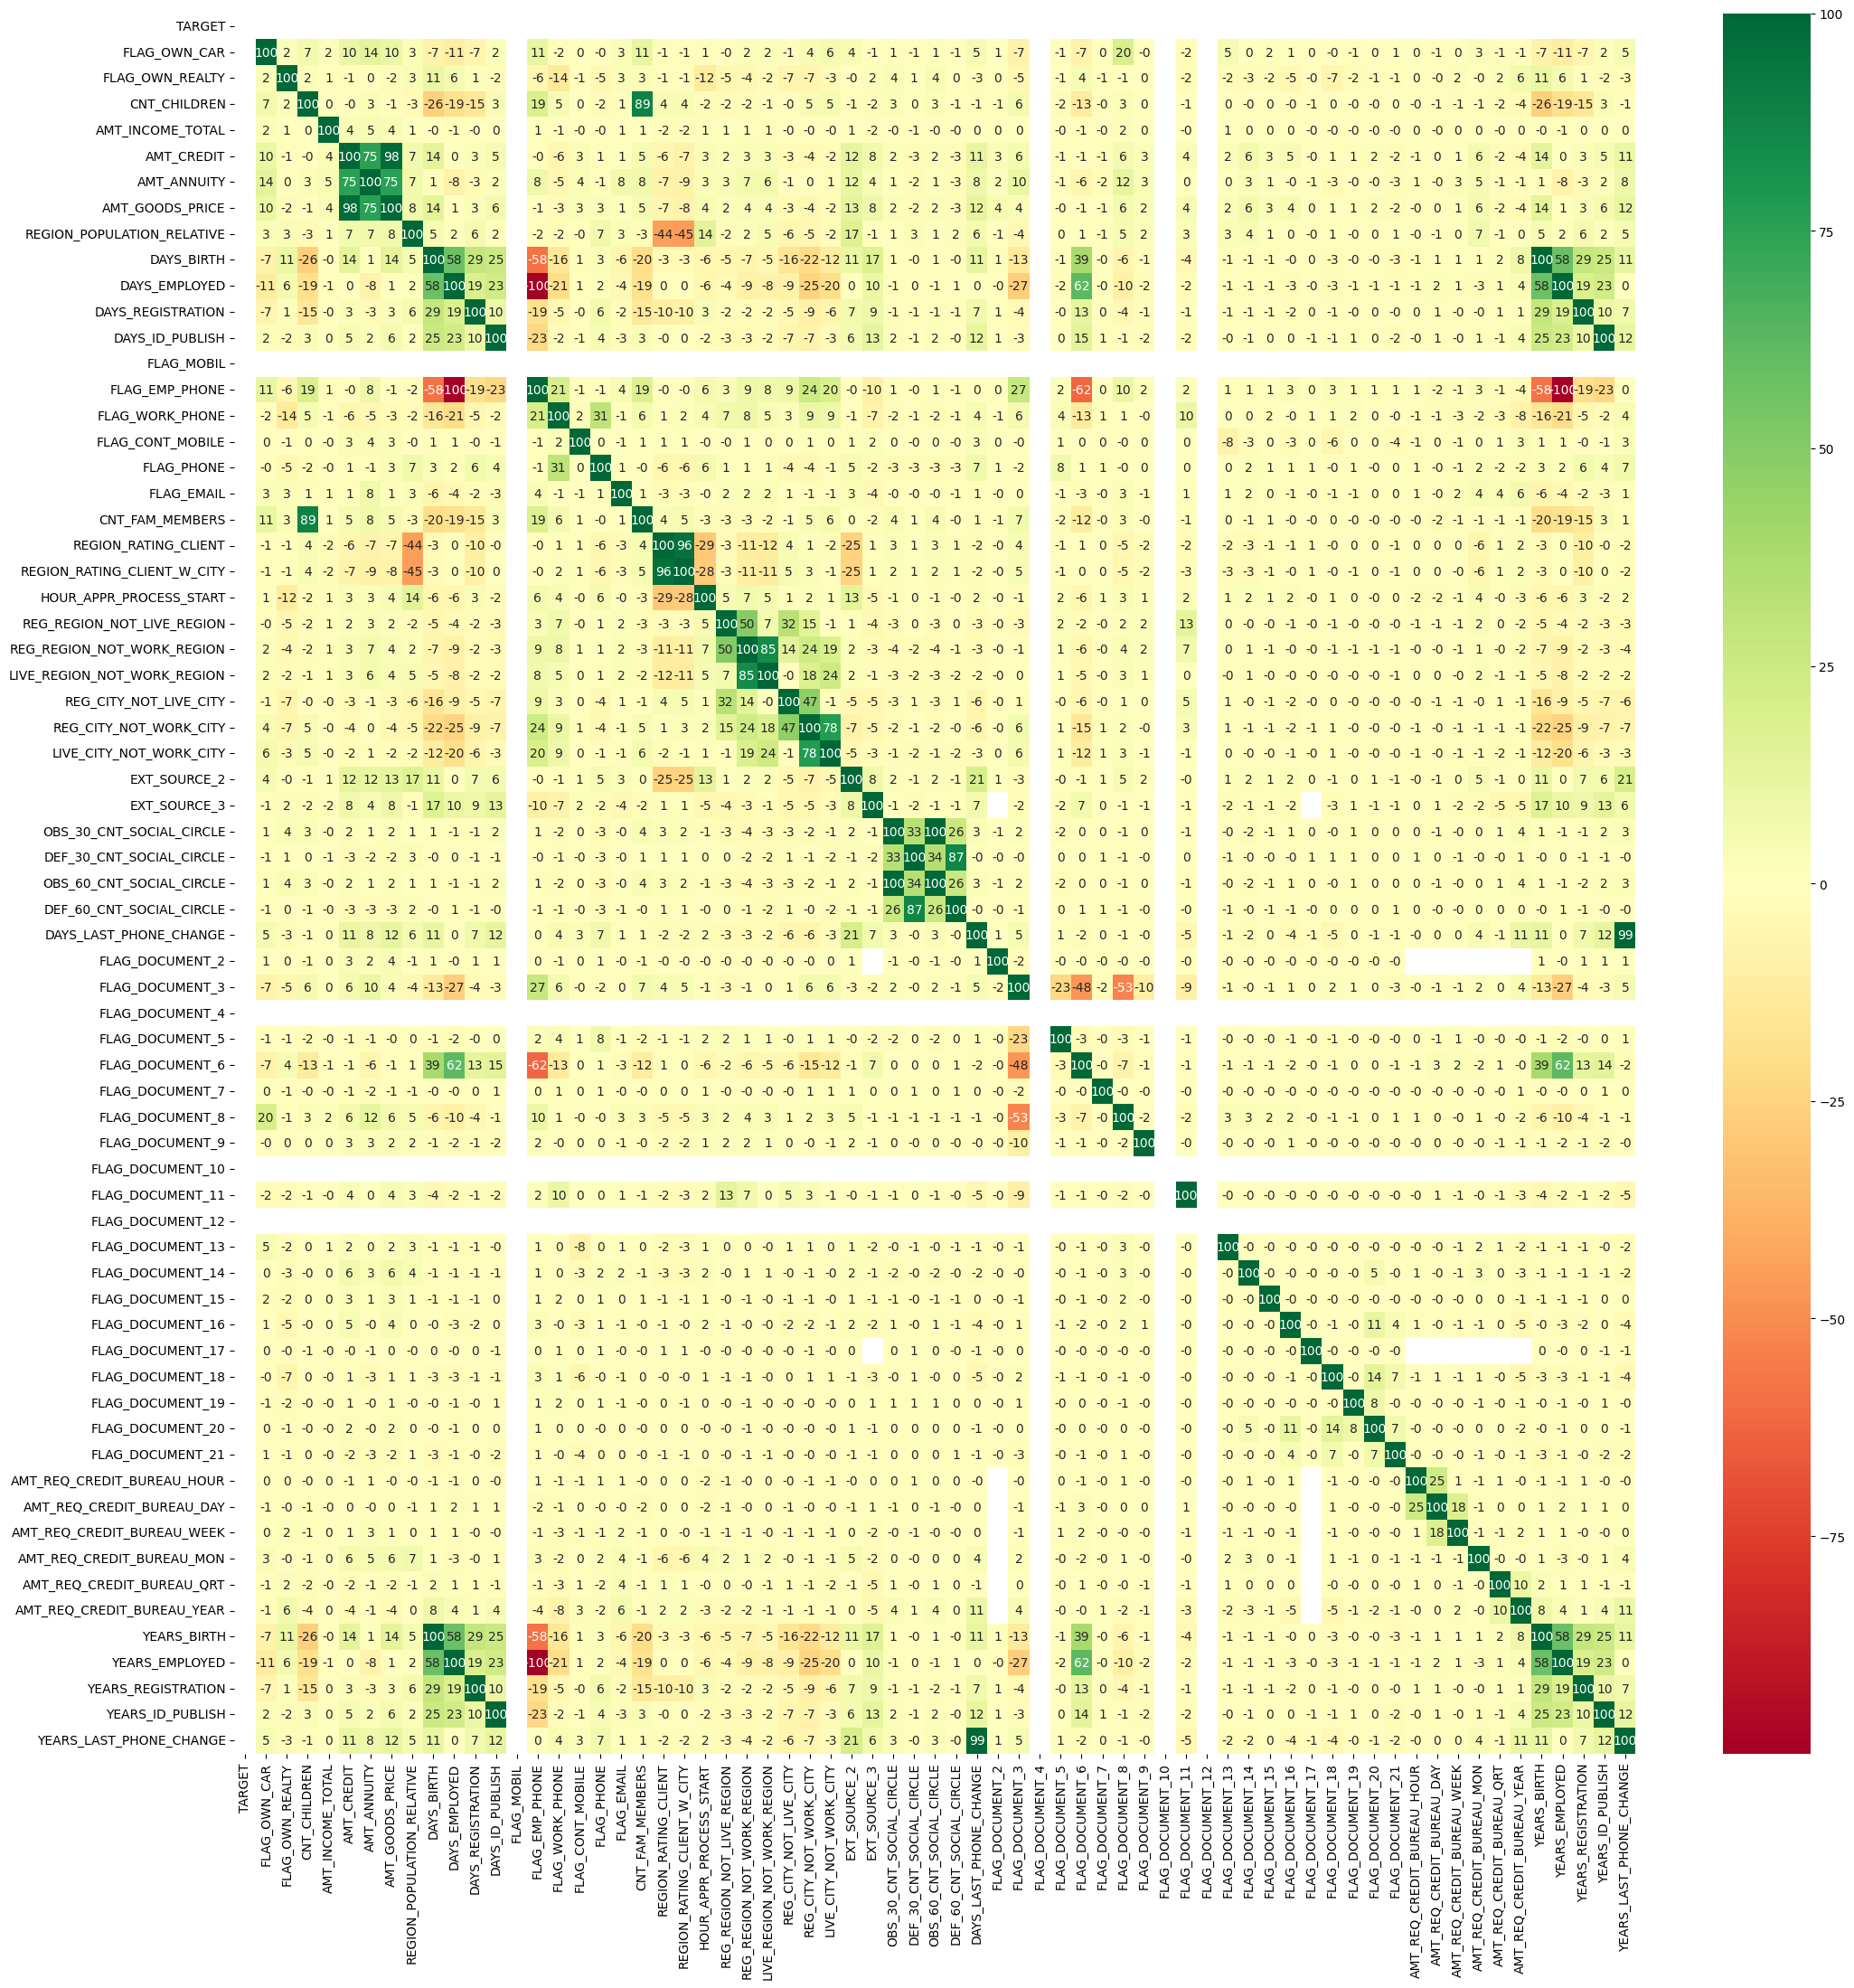

In [517]:
plt.figure(figsize = (25,25))
sns.heatmap(data = corr_df1*100, annot = True, cmap = "RdYlGn", cbar = True, fmt='.0f')
plt.show()

Let's create a heatmap to view correlations above 80% and 99.99%

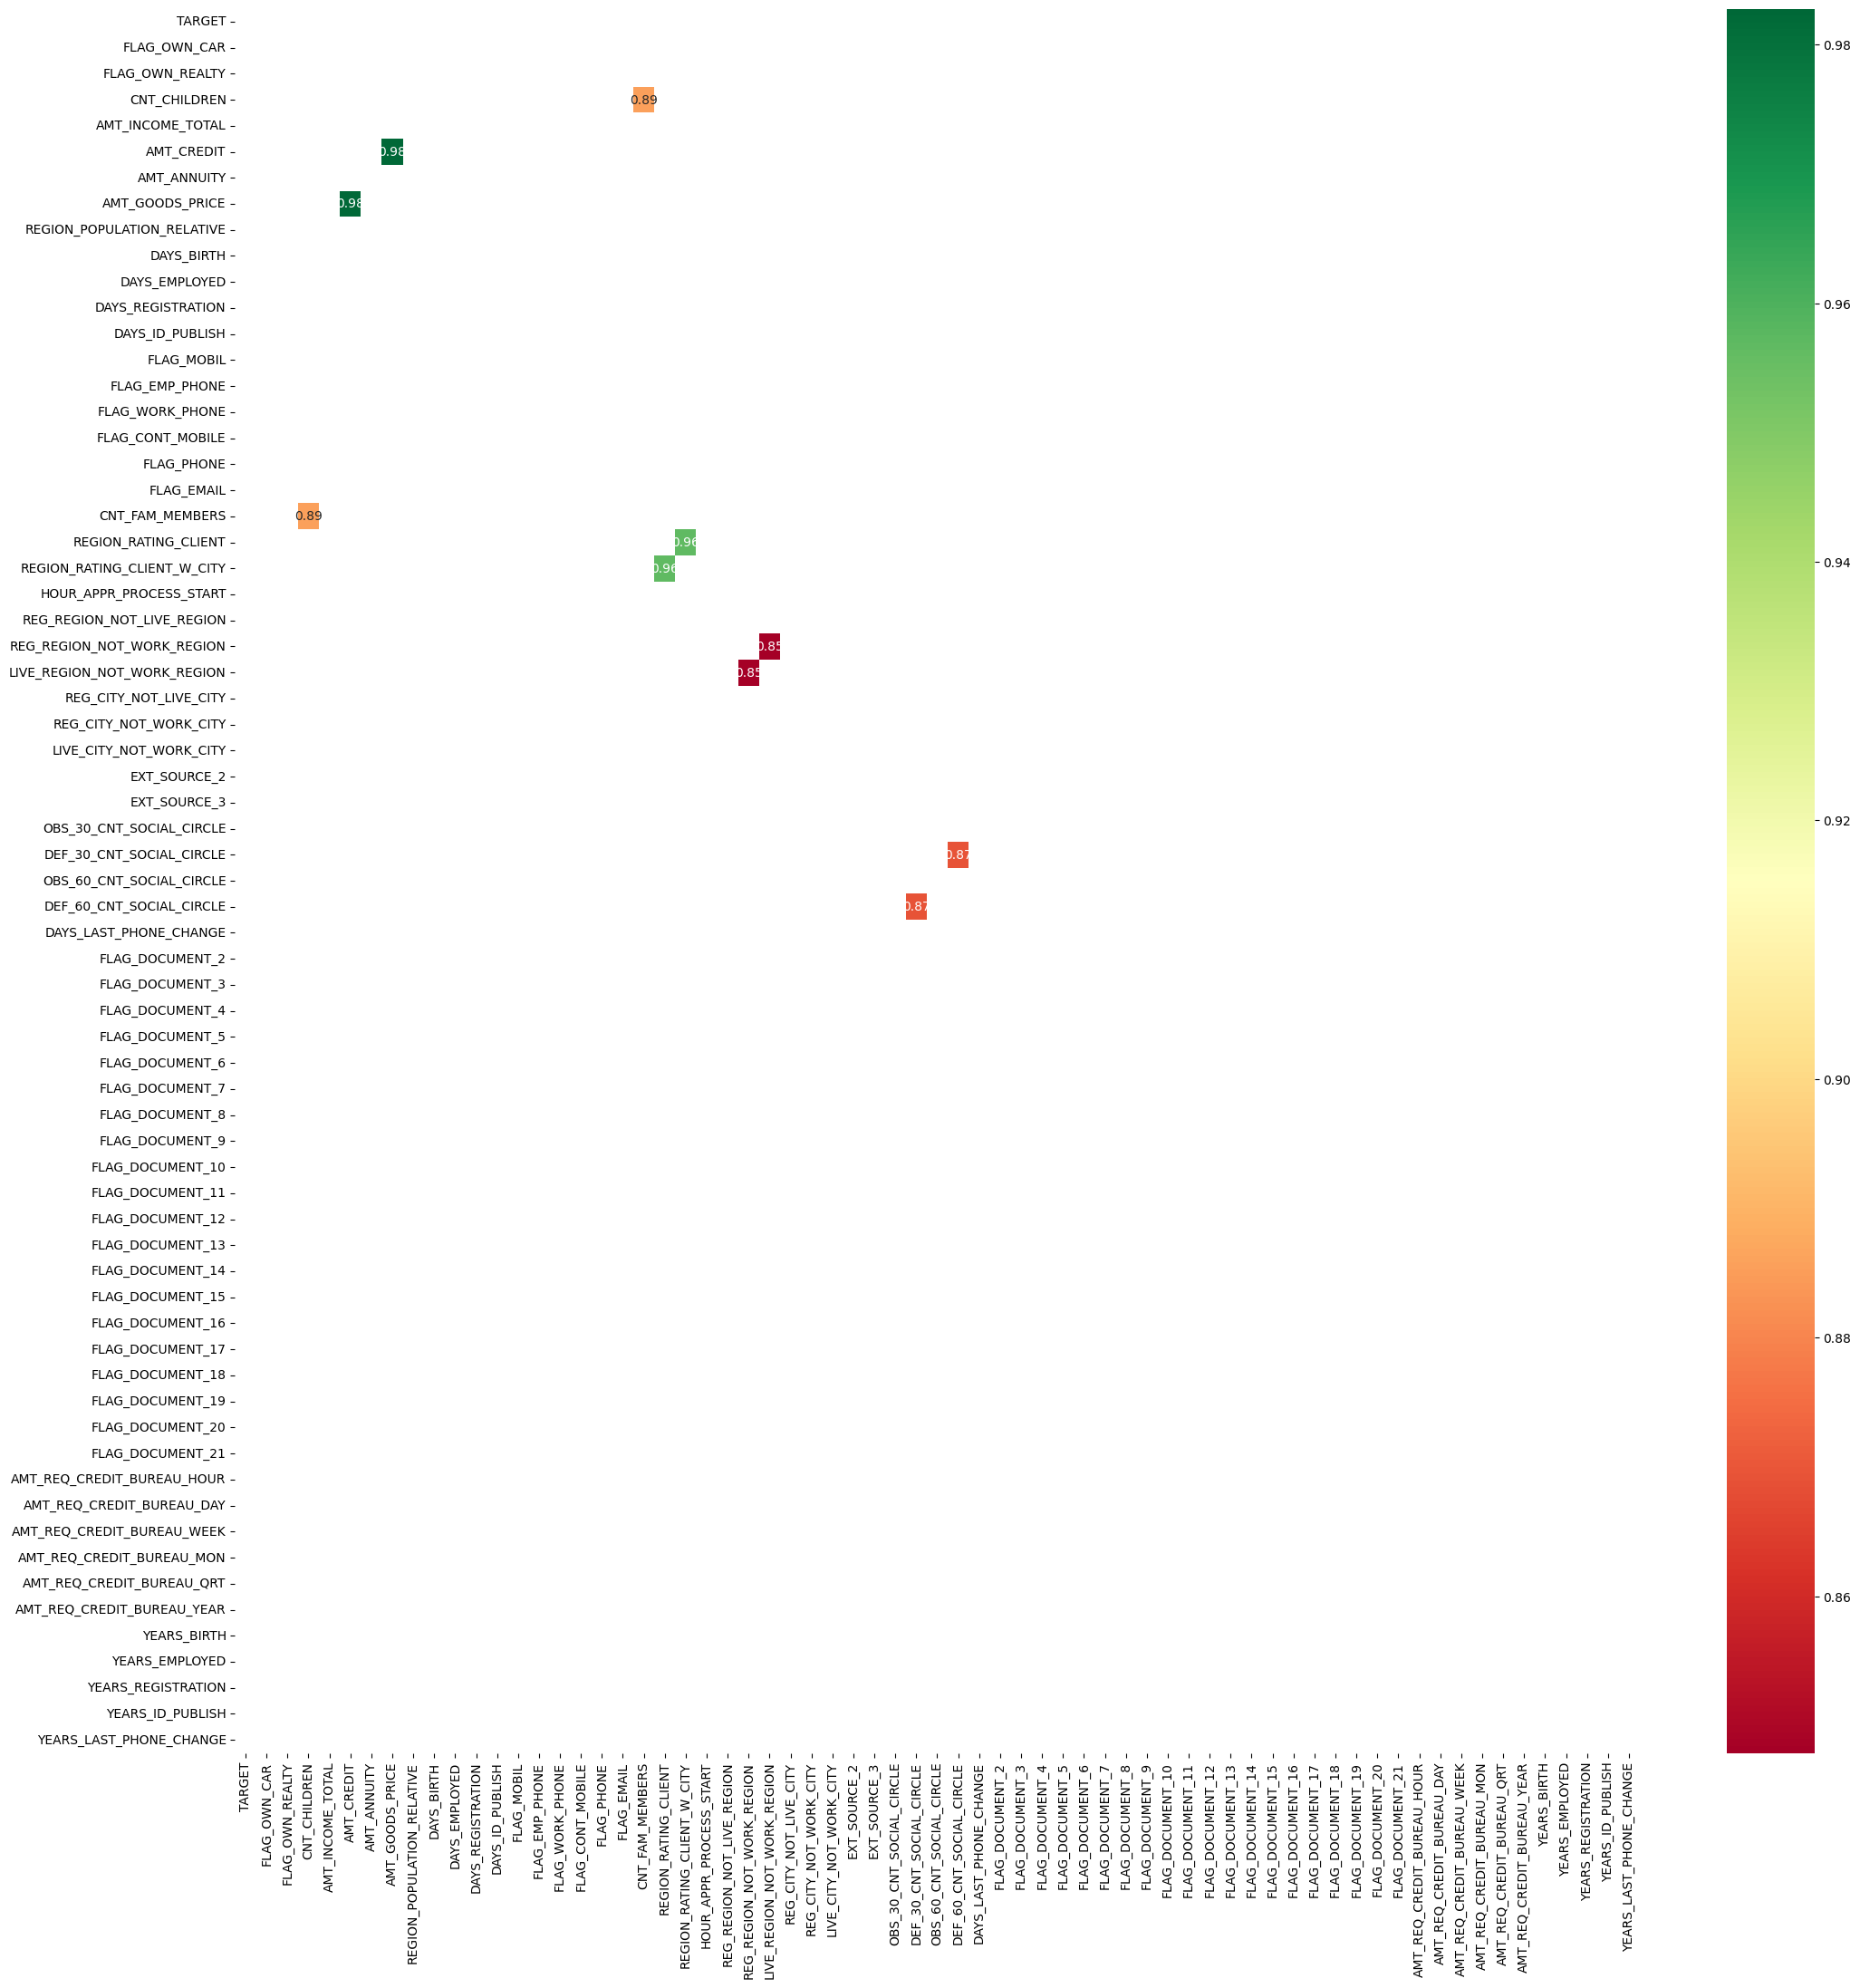

In [518]:
plt.figure(figsize = (25,25))
sns.heatmap(data = corr_df1[(corr_df1 >= 0.8) & (corr_df1 < 0.99)], annot = True, cmap = "RdYlGn", cbar = True, fmt='.2f')
plt.show()

In [519]:
corr_df1[corr_df1 <= 0.99].unstack().sort_values(ascending = False).head(22)

,,0
AMT_CREDIT,AMT_GOODS_PRICE,0.98
AMT_GOODS_PRICE,AMT_CREDIT,0.98
REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,0.96
REGION_RATING_CLIENT_W_CITY,REGION_RATING_CLIENT,0.96
CNT_FAM_MEMBERS,CNT_CHILDREN,0.89
CNT_CHILDREN,CNT_FAM_MEMBERS,0.89
DEF_30_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,0.87
DEF_60_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,0.87
REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,0.85
LIVE_REGION_NOT_WORK_REGION,REG_REGION_NOT_WORK_REGION,0.85


Since we have repeating combinations, looking at the table above and removing duplicates, we get the top 10 correlations as shown below:

*   AMT_GOODS_PRICE - AMT_CREDIT 0.98
*   REGION_RATING_CLIENT - REGION_RATING_CLIENT_W_CITY 0.96
*   CNT_FAM_MEMBERS - CNT_CHILDREN 0.89
*   DEF_60_CNT_SOCIAL_CIRCLE - DEF_30_CNT_SOCIAL_CIRCLE 0.87
*   REG_REGION_NOT_WORK_REGION - LIVE_REGION_NOT_WORK_REGION 0.85
*   LIVE_CITY_NOT_WORK_CITY - REG_CITY_NOT_WORK_CITY 0.78
*   AMT_ANNUITY - AMT_GOODS_PRICE 0.75
*   AMT_ANNUITY - AMT_CREDIT 0.75
*   DAYS_EMPLOYED - FLAG_DOCUMENT_6 0.62
*   DAYS_BIRTH - DAYS_EMPLOYED 0.58

### **Construct a correlation matrix for cases with timely payments**

In [520]:
df0.select_dtypes(include='number').shape

(282686, 67)

In [521]:
corr_df0 = df0.select_dtypes(include='number').corr()

In [522]:
corr_df0.head()

,TARGET,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,...,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,YEARS_BIRTH,YEARS_EMPLOYED,YEARS_REGISTRATION,YEARS_ID_PUBLISH,YEARS_LAST_PHONE_CHANGE
TARGET,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_OWN_CAR,NaN,1.00,-0.01,0.11,0.18,0.12,0.14,0.12,0.04,-0.14,...,0.00,0.00,0.02,-0.01,-0.04,-0.14,-0.16,-0.09,-0.02,0.04
FLAG_OWN_REALTY,NaN,-0.01,1.00,-0.00,0.00,-0.04,-0.01,-0.05,0.01,0.12,...,-0.01,0.01,-0.00,0.02,0.07,0.12,0.07,0.03,-0.01,-0.03
CNT_CHILDREN,NaN,0.11,-0.00,1.00,0.03,0.00,0.02,-0.00,-0.02,-0.34,...,0.00,-0.00,-0.01,-0.01,-0.04,-0.34,-0.25,-0.19,0.03,0.01
AMT_INCOME_TOTAL,NaN,0.18,0.00,0.03,1.00,0.34,0.42,0.35,0.17,-0.06,...,0.01,0.01,0.06,0.01,0.03,-0.06,-0.14,-0.06,-0.02,0.04


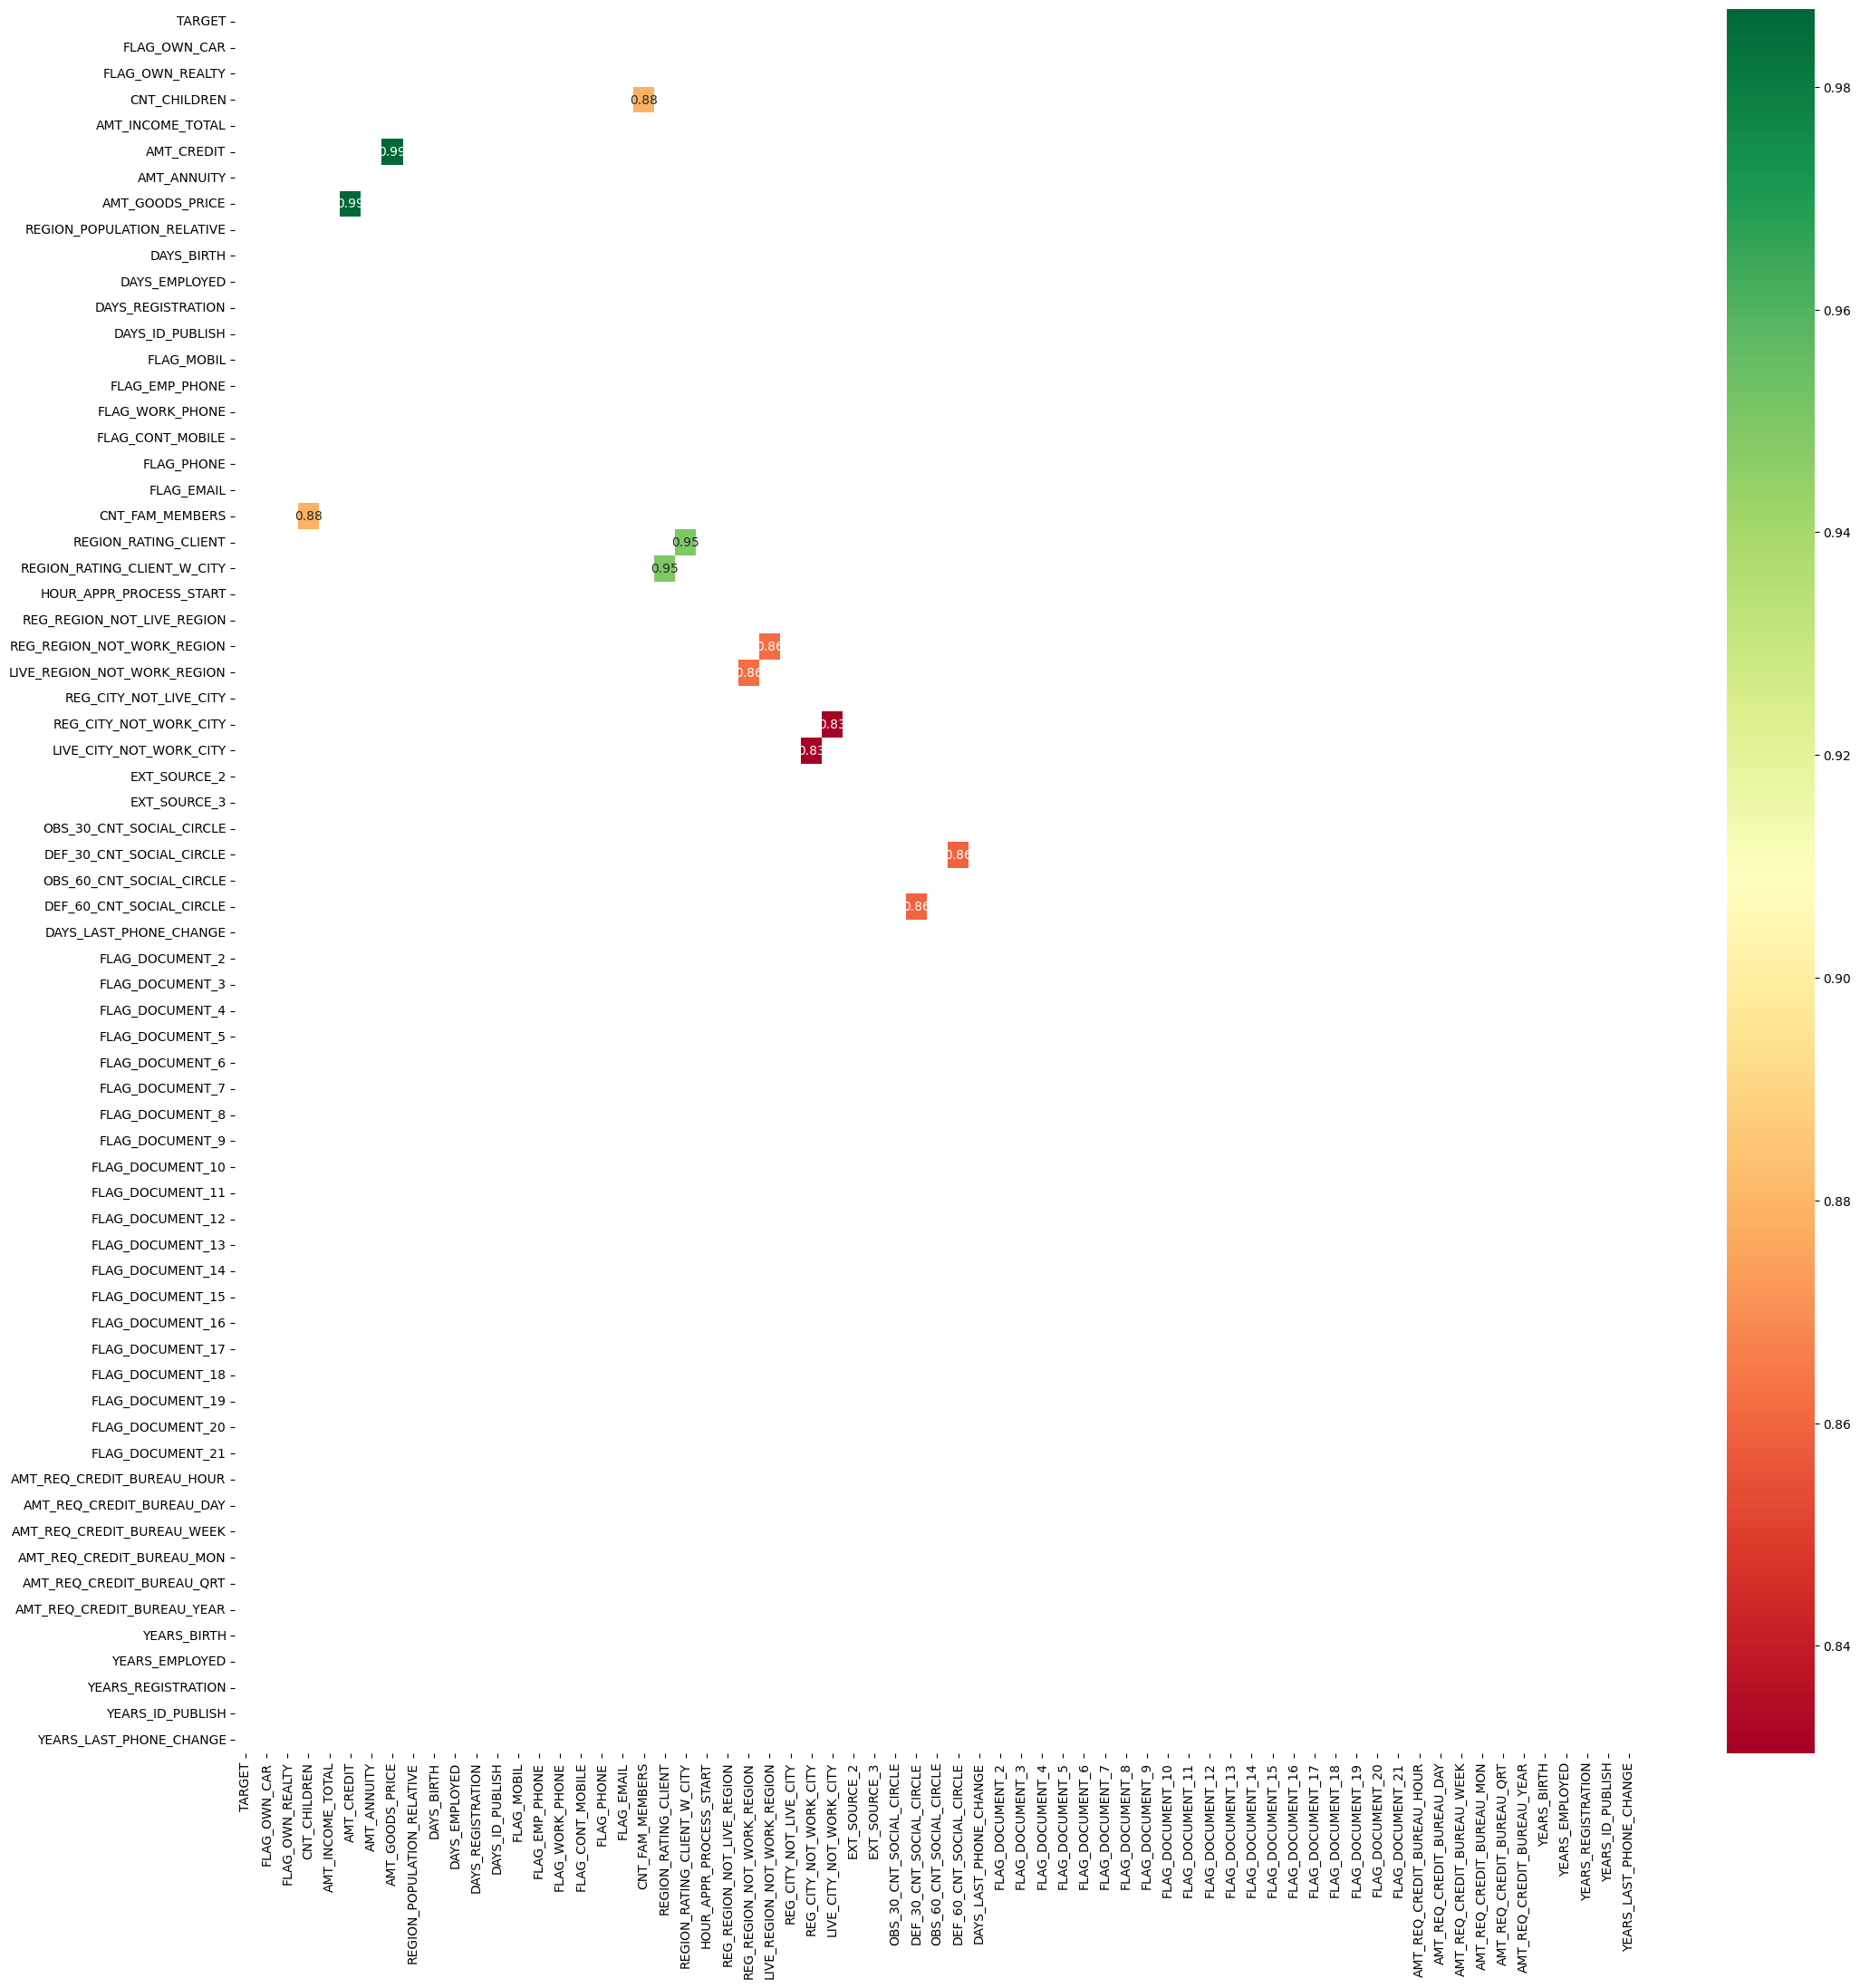

In [523]:
plt.figure(figsize = (25,25))
sns.heatmap(data = corr_df0[(corr_df0 >= 0.8) & (corr_df0 < 0.99)], annot = True, cmap = "RdYlGn", cbar = True, fmt='.2f')
plt.show()

Check out the 11 best correlations for on-time payments.

In [524]:
corr_df0[corr_df0 <= 0.99].unstack().sort_values(ascending = False).head(22)

,,0
AMT_GOODS_PRICE,AMT_CREDIT,0.99
AMT_CREDIT,AMT_GOODS_PRICE,0.99
REGION_RATING_CLIENT_W_CITY,REGION_RATING_CLIENT,0.95
REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,0.95
CNT_CHILDREN,CNT_FAM_MEMBERS,0.88
CNT_FAM_MEMBERS,CNT_CHILDREN,0.88
LIVE_REGION_NOT_WORK_REGION,REG_REGION_NOT_WORK_REGION,0.86
REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,0.86
DEF_30_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,0.86
DEF_60_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,0.86


Since we have repeating combinations, looking at the table above and removing duplicates, we get the top 11 correlations as shown below:

*   AMT_GOODS_PRICE AMT_CREDIT 0.99
*   REGION_RATING_CLIENT REGION_RATING_CLIENT_W_CITY 0.95
*   CNT_FAM_MEMBERS CNT_CHILDREN 0.88
*   REG_REGION_NOT_WORK_REGION LIVE_REGION_NOT_WORK_REGION 0.86
*   DEF_30_CNT_SOCIAL_CIRCLE DEF_60_CNT_SOCIAL_CIRCLE 0.86
*   LIVE_CITY_NOT_WORK_CITY REG_CITY_NOT_WORK_CITY 0.83
*   AMT_ANNUITY AMT_GOODS_PRICE 0.78
*   AMT_ANNUITY AMT_CREDIT 0.77
*   DAYS_BIRTH DAYS_EMPLOYED 0.63
*   DAYS_EMPLOYED FLAG_DOCUMENT_6 0.60

**Comparing the top 11 correlations between payment difficulties and on-time payments**
**Observation**

*   The top 11 correlations for Payment Difficulties and On-time Payments are the same, except for slight differences in the correlation percentages
*   The highest correlation is for the combination of AMT_GOODS_PRICE and AMT_CREDIT.
*   For the Payment Difficulties dataset, the correlation between AMT_GOODS_PRICE and AMT_CREDIT is 0.98.
*   For the On-time Payments dataset, the correlation between AMT_GOODS_PRICE and AMT_CREDIT is 0.99.

### **Univariate analysis of numerical variables**

**Analyze of the AMT_CREDIT column**

**Find outliers in AMT_CREDIT for cases with payment difficulties.**

In [525]:
calculate_outlier_bounds(df1,"AMT_CREDIT")

IQR: 448915.5
Minimum value after which emissions exist: -388973.25
Maximum value after which emissions exist: 1406688.75


**Find the outliers in AMT_CREDIT for cases with timely payments.**

In [526]:
calculate_outlier_bounds(df0,"AMT_CREDIT")

IQR: 540000.0
Minimum value after which emissions exist: -540000.0
Maximum value after which emissions exist: 1620000.0


In [527]:
def remove_outliers(data: pd.Series) -> pd.Series:
    """
    Removes outliers from a numerical pandas Series using the Interquartile Range (IQR) method
    and resets the index of the returned Series.

    Outliers are defined as values that fall below Q1 - 1.5 * IQR or above Q3 + 1.5 * IQR,
    where Q1 is the 25th percentile and Q3 is the 75th percentile of the data.

    Parameters
    ----------
    data : pd.Series
        A pandas Series containing numerical values.

    Returns
    -------
    pd.Series
        A filtered Series with outliers removed and index reset.
    """
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return data[(data  > lower_bound) & (data < upper_bound)]#.reset_index(drop=True)

In [528]:
def compare_kde_remove_outliers(df1: pd.DataFrame, df0: pd.DataFrame, column: str):
    """
    For two DataFrames, calculates IQR and outlier bounds,
    removes outliers, and plots KDE for each without modifying original data.

    Parameters:
    df1 (pd.DataFrame): DataFrame with payment difficulties
    df0 (pd.DataFrame): DataFrame with timely payments
    column (str): Column name to analyze and plot
    """
    filtered1 = remove_outliers(df1[column])
    filtered0 = remove_outliers(df0[column])

    # KDE Plot
    plt.figure(figsize=(10, 5))
    sns.kdeplot(filtered1, label='Payment difficulties', fill=True, linewidth=2)
    sns.kdeplot(filtered0, label='On-Time Payments', fill=True, linewidth=2)
    plt.title(f"KDE Plot of '{column}' (Outliers Removed)", fontsize=14)
    plt.ticklabel_format(style='plain', axis='x')
    plt.xticks(rotation = 45)
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

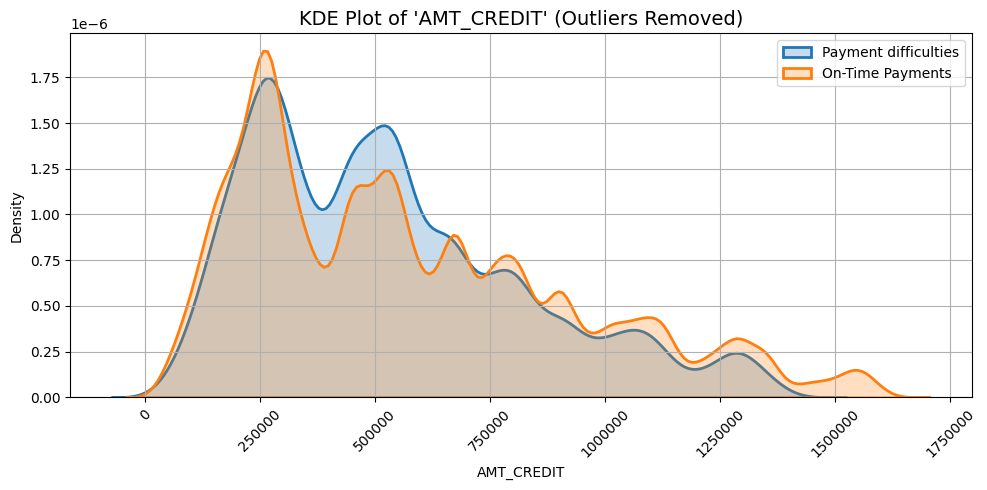

In [529]:
compare_kde_remove_outliers(df1, df0, 'AMT_CREDIT')

**Observation**

For AMT_CREDIT, between 250,000 and approximately 650,000 more customers are having difficulty paying

For AMT_CREDIT > 750,000 more customers are making payments on time

**Analyze of the YEARS_BIRTH column**

**Find outliers in YEARS_BIRTH for cases with payment difficulties.**

In [530]:
calculate_outlier_bounds(df1,"YEARS_BIRTH")

IQR: 18.0
Minimum value after which emissions exist: 4.0
Maximum value after which emissions exist: 76.0


**Find the outliers in YEARS_BIRTH for cases with timely payments.**

In [531]:
calculate_outlier_bounds(df0,"YEARS_BIRTH")

IQR: 20.0
Minimum value after which emissions exist: 4.0
Maximum value after which emissions exist: 84.0


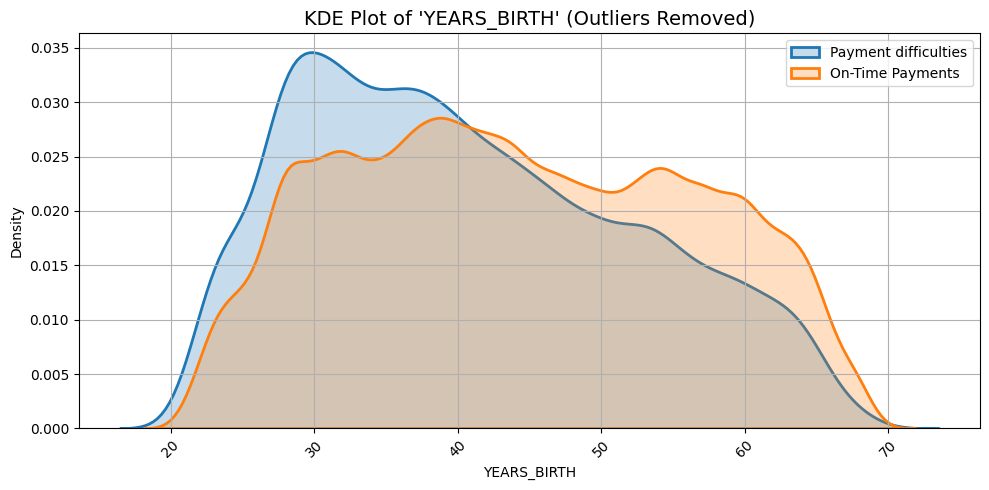

In [532]:
compare_kde_remove_outliers(df1, df0, 'YEARS_BIRTH')

**Observation**


*   Сustomers aged 18 to 40 have difficulty paying.

*   Сustomers aged 40 and over most pay on time.

**Analyze of the AMT_GOODS_PRICE column**

**Find outliers in AMT_GOODS_PRICE for cases with payment difficulties.**

In [533]:
calculate_outlier_bounds(df1,"AMT_GOODS_PRICE")

IQR: 436500.0
Minimum value after which emissions exist: -416250.0
Maximum value after which emissions exist: 1329750.0


**Find the outliers in AMT_GOODS_PRICE for cases with timely payments.**

In [534]:
calculate_outlier_bounds(df0,"AMT_GOODS_PRICE")

IQR: 446502.375
Minimum value after which emissions exist: -431253.5625
Maximum value after which emissions exist: 1354755.9375


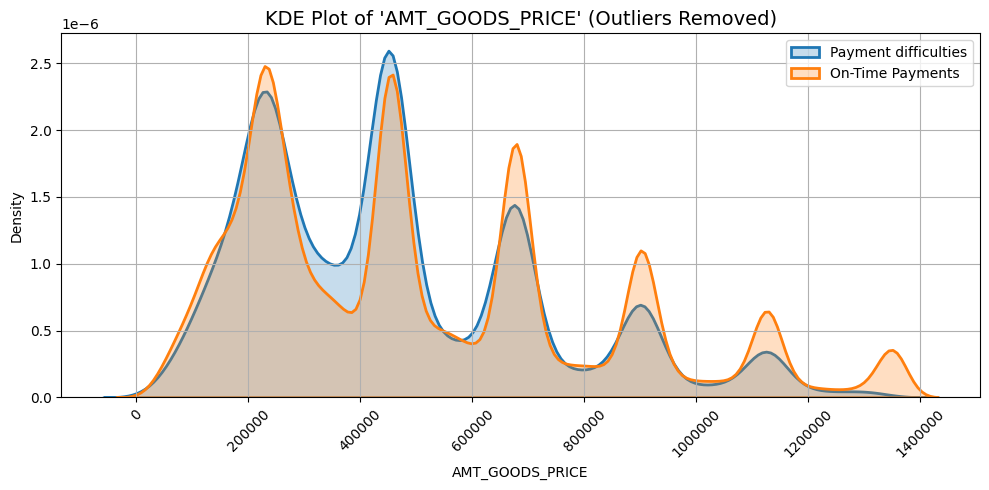

In [535]:
compare_kde_remove_outliers(df1, df0, 'AMT_GOODS_PRICE')

**Observation**

*   For AMT_GOODS_PRICE from 250,000 to about 550,000 more customers have difficulty paying.

*   For AMT_GOODS_PRICE > 650,000 mostly more customers make payments on time.

**Analyze of the DAYS_EMPLOYED column**

**Find outliers in DAYS_EMPLOYED for cases with payment difficulties.**

In [536]:
calculate_outlier_bounds(df1,"DAYS_EMPLOYED")

IQR: 2603.0
Minimum value after which emissions exist: -3227.5
Maximum value after which emissions exist: 7184.5


**Find the outliers in DAYS_EMPLOYED for cases with timely payments.**

In [537]:
calculate_outlier_bounds(df0,"DAYS_EMPLOYED")

IQR: 5107.0
Minimum value after which emissions exist: -6693.5
Maximum value after which emissions exist: 13734.5


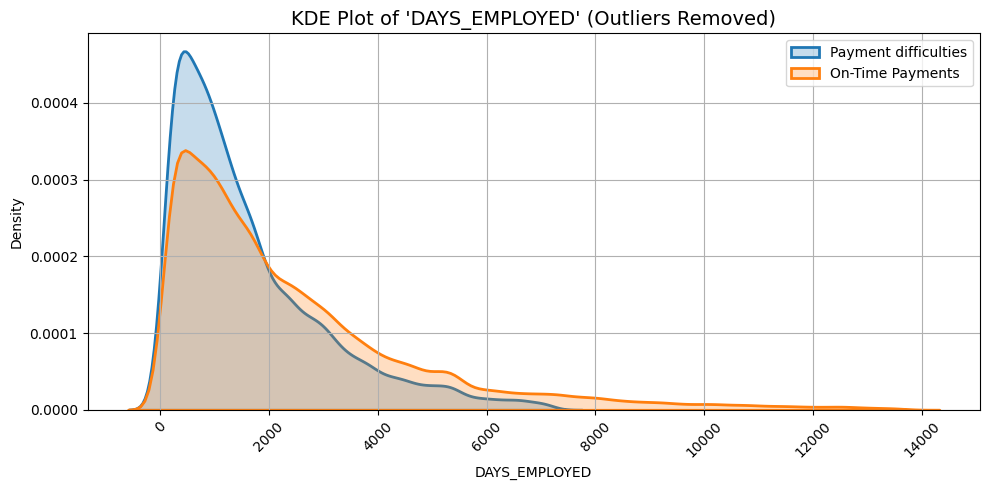

In [538]:
compare_kde_remove_outliers(df1, df0, 'DAYS_EMPLOYED')

**Observation**

*   For DAYS_EMPLOYED from about 0 to about 2000 more customers have difficulty paying
*   For DAYS_EMPLOYED > 2000 more customers make their payments on time

## **Bivariate/Multivariate Analysis**

**Correlation analysis for a pair of numerical variables**

**Analyze the columns AMT_GOODS_PRICE vs AMT_CREDIT**

Find outliers for column AMT_GOODS_PRICE for group with payment difficulties

In [539]:
calculate_outlier_bounds(df1,"AMT_GOODS_PRICE")

IQR: 436500.0
Minimum value after which emissions exist: -416250.0
Maximum value after which emissions exist: 1329750.0


Find outliers for the AMT_CREDIT column for the group with payment difficulties

In [540]:
calculate_outlier_bounds(df1,"AMT_CREDIT")

IQR: 448915.5
Minimum value after which emissions exist: -388973.25
Maximum value after which emissions exist: 1406688.75


Find outliers for AMT_GOODS_PRICE for the group with timely payments

In [541]:
calculate_outlier_bounds(df0,"AMT_GOODS_PRICE")

IQR: 446502.375
Minimum value after which emissions exist: -431253.5625
Maximum value after which emissions exist: 1354755.9375


Find outliers for AMT_CREDIT for the group with timely payments

In [542]:
calculate_outlier_bounds(df0,"AMT_CREDIT")

IQR: 540000.0
Minimum value after which emissions exist: -540000.0
Maximum value after which emissions exist: 1620000.0


In [543]:
def compare_scatterplot_remove_outliers(
    df1: pd.DataFrame,
    df0: pd.DataFrame,
    column1: str,
    column2: str
) -> None:
    """
    Compare scatterplots between two datasets after removing outliers.

    Parameters:
        df1 (pd.DataFrame): DataFrame with payment difficulties (TARGET == 1).
        df0 (pd.DataFrame): DataFrame with on-time payments (TARGET == 0).
        column1 (str): Name of the column to use for x-axis.
        column2 (str): Name of the column to use for y-axis.
    """

    filtered1 = remove_outliers(df1[[column1, column2]])
    filtered2 = remove_outliers(df0[[column1, column2]])

    plt.figure(figsize=(14, 6))

    # Scatterplot for payment difficulties
    plt.subplot(1, 2, 1)
    plt.title("Payment Difficulties")
    sns.scatterplot(
        x=filtered1[column1],
        y=filtered1[column2]
    )
    plt.ticklabel_format(style='plain', axis='x')
    plt.ticklabel_format(style='plain', axis='y')

    # Scatterplot for on-time payments
    plt.subplot(1, 2, 2)
    plt.title("On-Time Payments")
    sns.scatterplot(
        x=filtered2[column1],
        y=filtered2[column2]
    )
    plt.ticklabel_format(style='plain', axis='x')
    plt.ticklabel_format(style='plain', axis='y')

    plt.tight_layout(pad=4)
    plt.show()


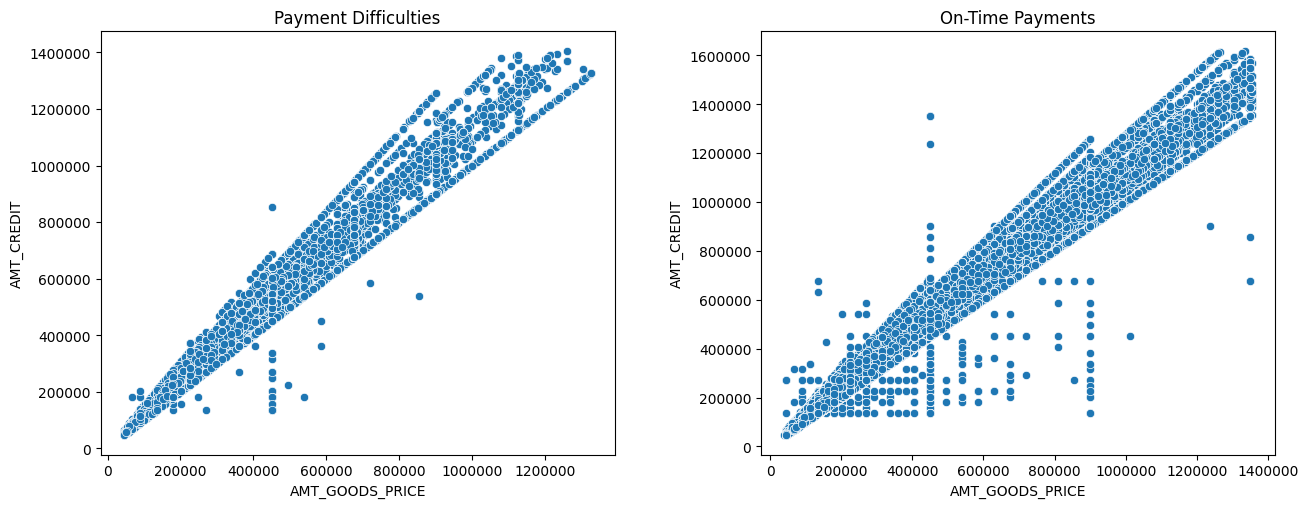

In [544]:
compare_scatterplot_remove_outliers(df1,df0,'AMT_GOODS_PRICE','AMT_CREDIT')

**Observation**

From the plots, we can see that AMT_GOODS_PRICE and AMT_CREDIT have a strong positive correlation. This means that as the price of the goods increases, the amount of credit also increases.

**Analyze the columns AMT_ANNUITY vs AMT_CREDIT**

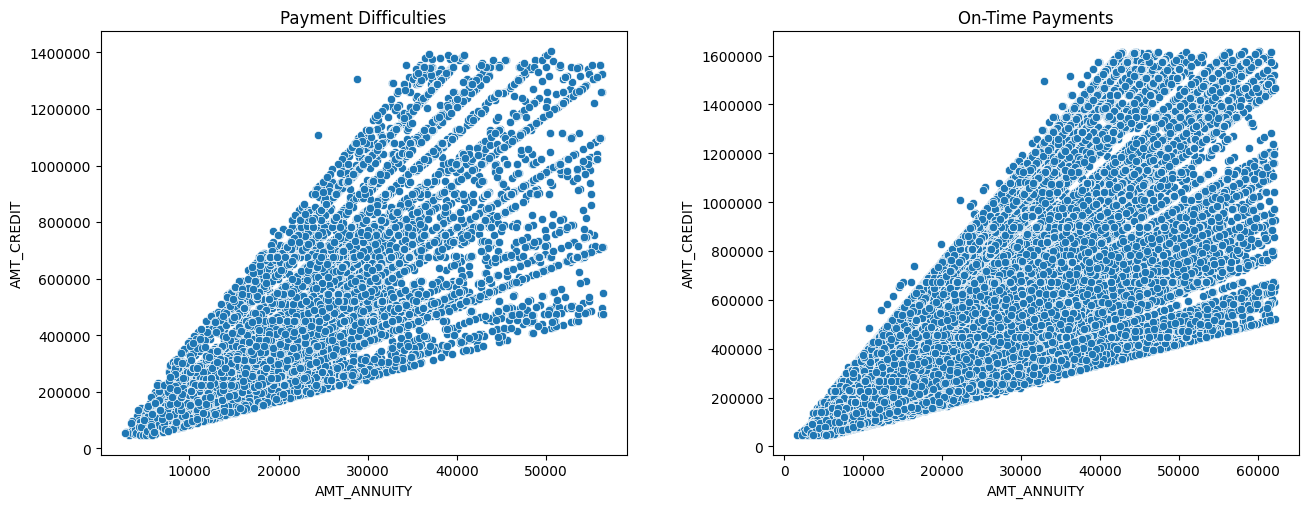

In [545]:
compare_scatterplot_remove_outliers(df1,df0,'AMT_ANNUITY','AMT_CREDIT')

**Observation:**

From the plots, it can be seen that AMT_ANNUITY' and 'AMT_CREDIT' have a positive correlation, but not very strong (weaker than AMT_GOODS_PRICE and AMT_CREDIT). This indicates that as AMT_ANNUITY increases, the loan amount will increase.

**Analyze the columns DAYS_EMPLOYED vs AMT_INCOME_TOTAL**

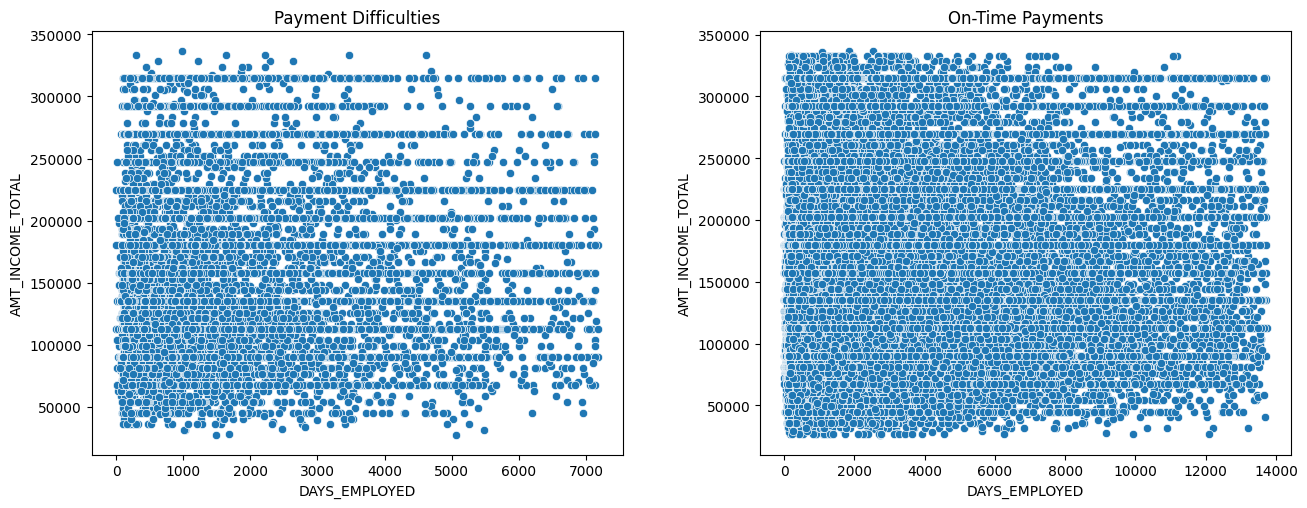

In [546]:
compare_scatterplot_remove_outliers(df1,df0,'DAYS_EMPLOYED', 'AMT_INCOME_TOTAL')

**Observation:**

The plots show a horizontal distribution of points without a pronounced upward or downward slope. There is no visible linear pattern - the data is widely scattered.

### **Continuous and categorical variables**

In [547]:
def remove_upper_outliers(data: pd.Series) -> pd.Series:
    """
    Removes only upper outliers from a numerical pandas Series using the IQR method.
    Keeps all values greater than or equal to the lower bound, but filters out values
    greater than Q3 + 1.5 * IQR.

    Parameters
    ----------
    data : pd.Series
        A pandas Series containing numerical values.

    Returns
    -------
    pd.Series
        A filtered Series with upper outliers removed and index reset.
    """
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    return data[data < upper_bound].reset_index


In [548]:
def draw_boxplot(df, categorical, continuous, title, hue_column, subplot_position):
    """
    Малює блок-діаграму для заданого DataFrame, категоріальної та неперервної змінної.
    """
    plt.subplot(1, 2, subplot_position)
    plt.title(title)
    red_diamond = dict(markerfacecolor='r', marker='D')
    q1 = df[continuous].quantile(0.25)
    q3 = df[continuous].quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    sns.boxplot(x=categorical,
                y=remove_outliers(df[continuous]),
                data=df,
                flierprops=red_diamond,
                order=sorted(df[categorical].unique(), reverse=True),
                hue=hue_column, hue_order=sorted(df[hue_column].unique(), reverse=True))
    plt.ticklabel_format(style='plain', axis='y')
    plt.xticks(rotation=90)

def bi_boxplot(categorical, continuous,  hue_column):
    """
    Creates side-by-side block diagrams for two groups defined in a dataset based on a categorical and
    a continuous variable, highlighting differences using shading.
    """
    plt.figure(figsize=(16, 10))

    # Plot for the first group "Payment Difficulties"
    draw_boxplot(df1, categorical, continuous,'Payment Difficulties', hue_column, 1)

    # Plot for the second group "On-Time Payments"
    draw_boxplot(df0, categorical, continuous,'On-Time Payments', hue_column, 2)

    plt.tight_layout(pad=4)
    plt.show()

**Analyze the columns AMT_CREDIT vs NAME_EDUCATION_TYPE vs CODE_GENDER**

Find outliers for AMT_CREDIT for the group with payment difficulties

In [549]:
calculate_outlier_bounds(df1,'AMT_CREDIT')

IQR: 448915.5
Minimum value after which emissions exist: -388973.25
Maximum value after which emissions exist: 1406688.75


Find outliers for AMT_CREDIT for the group with timely payments

In [550]:
calculate_outlier_bounds(df0,'AMT_CREDIT')

IQR: 540000.0
Minimum value after which emissions exist: -540000.0
Maximum value after which emissions exist: 1620000.0


Customer with payment difficulties

In [551]:
df1.groupby(by = ['NAME_EDUCATION_TYPE','CODE_GENDER']).AMT_CREDIT.describe().head()

count      mean       std       min  \
NAME_EDUCATION_TYPE CODE_GENDER                                         
Academic degree     F              3.00 950245.50 504711.38 544491.00   
Higher education    F           2438.00 648500.58 410415.70  47970.00   
                    M           1571.00 642070.94 409695.93  45000.00   
Incomplete higher   F            504.00 520150.35 352227.49  91692.00   
                    M            368.00 554723.82 347843.71  74628.00   

                                      25%       50%        75%        max  
NAME_EDUCATION_TYPE CODE_GENDER                                            
Academic degree     F           667660.50 790830.00 1153122.75 1515415.50  
Higher education    F           323595.00 545040.00  877500.00 2687355.00  
                    M           329202.00 545040.00  832797.00 2695500.00  
Incomplete higher   F           269550.00 450000.00  675000.00 2695500.00  
                    M           284400.00 497520.00  699976.12 2013840.00

Client with timely payments

In [552]:
df0.groupby(by = ['NAME_EDUCATION_TYPE','CODE_GENDER']).AMT_CREDIT.describe().head()

count      mean       std       min  \
NAME_EDUCATION_TYPE CODE_GENDER                                          
Academic degree     F              97.00 708770.74 463052.42 130824.00   
                    M              64.00 735235.38 497739.97  74182.50   
Higher education    F           47852.00 682485.00 456642.78  45000.00   
                    M           23002.00 713144.54 486073.66  45000.00   
Incomplete higher   F            5780.00 555340.53 385980.60  45000.00   

                                      25%       50%        75%        max  
NAME_EDUCATION_TYPE CODE_GENDER                                            
Academic degree     F           354469.50 607500.00 1006920.00 2463840.00  
                    M           309519.00 610056.00 1036890.00 1984500.00  
Higher education    F           302206.50 568057.50  916470.00 4050000.00  
                    M           315000.00 592560.00  973503.00 4050000.00  
Incomplete higher   F           253737.00 454500.00  760225.50 2517300.00

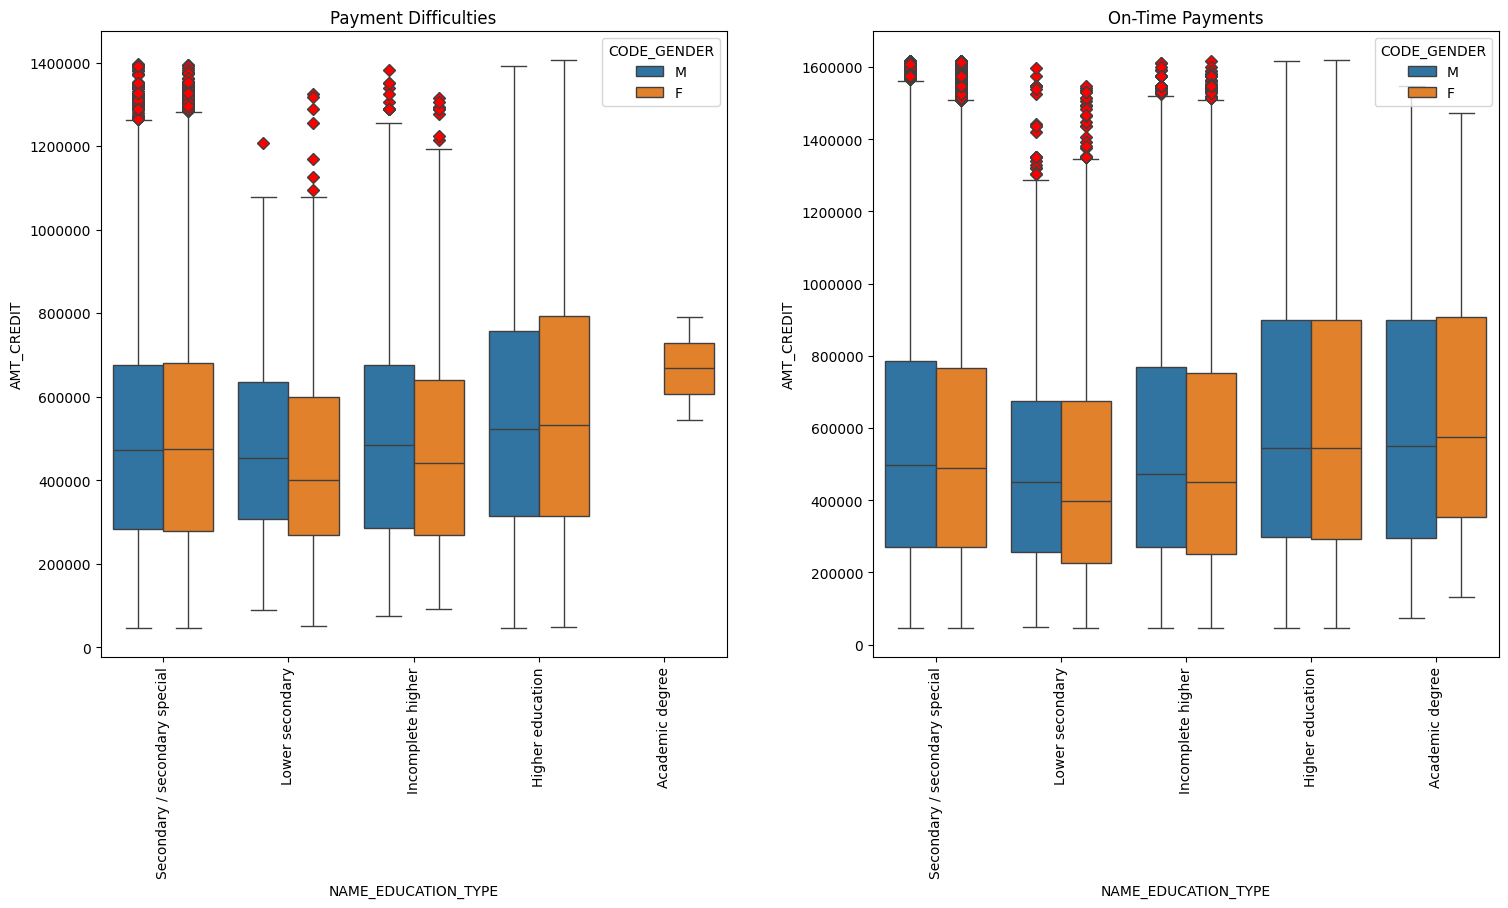

In [553]:
bi_boxplot('NAME_EDUCATION_TYPE','AMT_CREDIT', 'CODE_GENDER')

**Observation**

*  Customers with a "college degree" have a wide range of loans for on-time payments, while for customers with payment problems this range is much lower
*  If we look at the summary statistics, customers with a "academic degree" and payment problems take out a mean and median loan in a much larger range than customers with on-time payments.
*  Male customers with a "academic degree" always pay their loans on time

**Analyze the columns AMT_INCOME_TOTAL vs NAME_FAMILY_STATUS vs CODE_GENDER**

Customer with payment difficulties

In [554]:
df1.groupby(by = ['NAME_FAMILY_STATUS','CODE_GENDER']).AMT_INCOME_TOTAL.describe().head()

count      mean        std      min  \
NAME_FAMILY_STATUS CODE_GENDER                                         
Civil marriage     F           1753.00 153620.72  101045.86 25650.00   
                   M           1208.00 173949.99   92449.17 36000.00   
Married            F           8324.00 159907.85 1283283.40 27000.00   
                   M           6526.00 182233.06   94787.77 31500.00   
Separated          F           1045.00 161159.55   82633.33 36000.00   

                                     25%       50%       75%          max  
NAME_FAMILY_STATUS CODE_GENDER                                             
Civil marriage     F           108000.00 135000.00 180000.00   3150000.00  
                   M           117000.00 157500.00 202500.00   1350000.00  
Married            F            90000.00 135000.00 180000.00 117000000.00  
                   M           126000.00 157500.00 225000.00   1890000.00  
Separated          F           112500.00 135000.00 202500.00    832500.00

Client with timely payments

In [555]:
df0.groupby(by = ['NAME_FAMILY_STATUS','CODE_GENDER']).AMT_INCOME_TOTAL.describe().head()

count      mean       std      min  \
NAME_FAMILY_STATUS CODE_GENDER                                          
Civil marriage     F            19017.00 162086.05 106811.49 27000.00   
                   M             7797.00 184126.29 106559.49 27000.00   
Married            F           114125.00 154289.53  88593.43 26100.00   
                   M            67459.00 199592.83 147599.76 27000.00   
Separated          F            14416.00 166374.21  94782.18 27000.00   

                                     25%       50%       75%         max  
NAME_FAMILY_STATUS CODE_GENDER                                            
Civil marriage     F           112500.00 135000.00 202500.00  9000000.00  
                   M           121500.00 157500.00 225000.00  3825000.00  
Married            F            94500.00 135000.00 180000.00  3600000.00  
                   M           135000.00 180000.00 225000.00 18000090.00  
Separated          F           112500.00 139500.00 202500.00  2250000.00

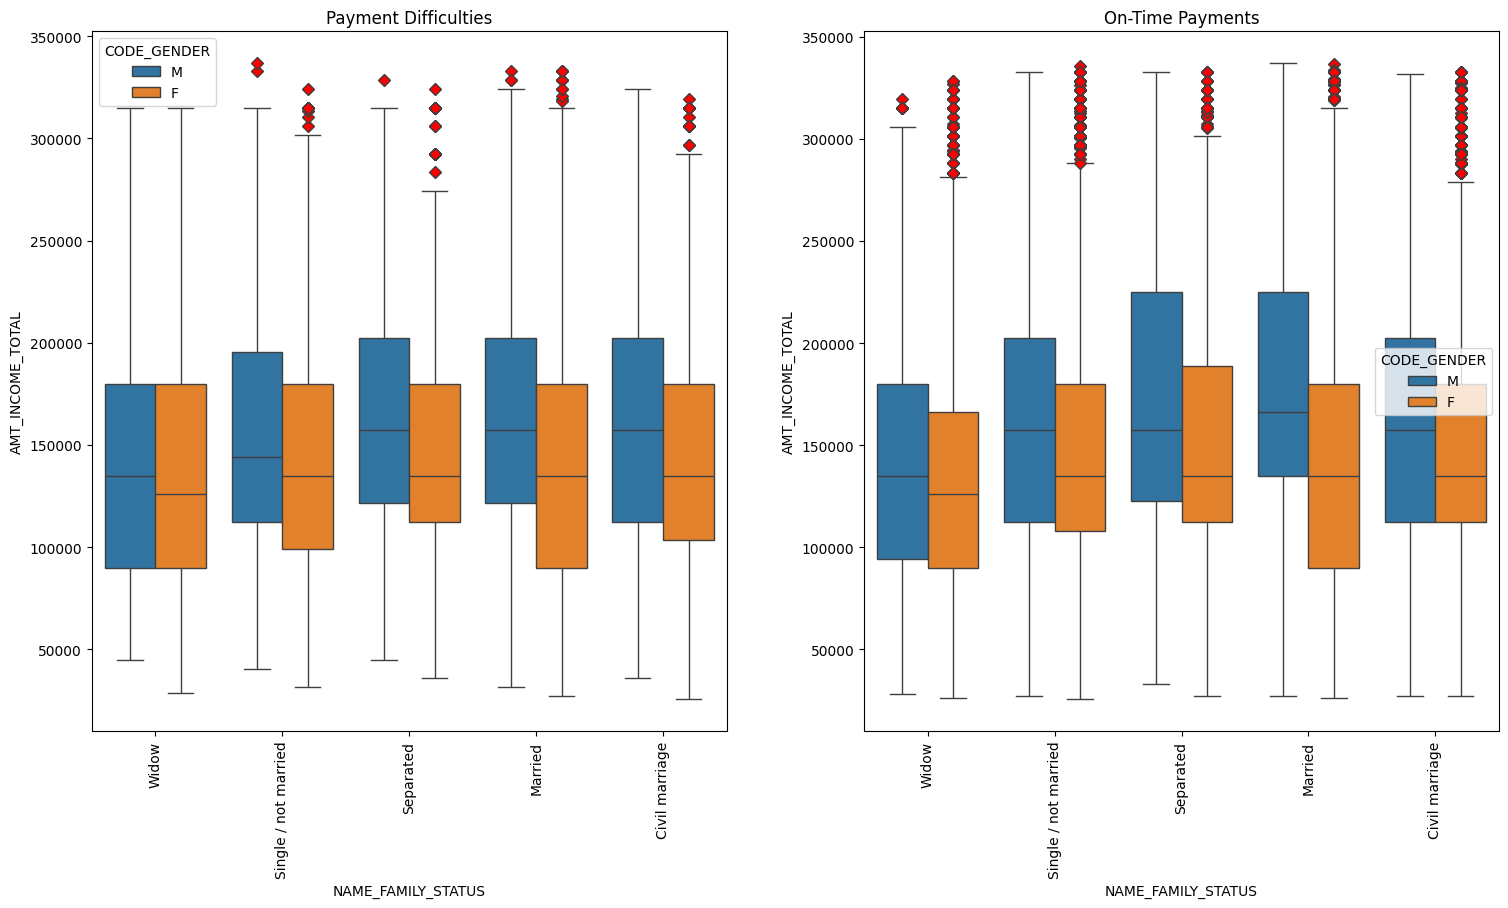

In [556]:
bi_boxplot('NAME_FAMILY_STATUS','AMT_INCOME_TOTAL','CODE_GENDER')

**Observation:**
*    In both groups, female applicants have lower median income across all marital statuses compared to males.

*   The interquartile ranges (IQRs) are narrower, indicating less variability and lower financial solvency among clients experiencing difficulty paying.

### **Dependencies between categorical variables**

**Analyze of NAME_INCOME_TYPE vs CODE_GENDER columns**

In [557]:
def bi_countplot_target(df0, df1, column, hue_column) :
    group_name = f'Normalized distribution of values by category: {column}'
    print (group_name.upper())

    pltname = 'Clients with payment difficulties'
    unique_hue_values = df1[hue_column].unique()
    fig, axes = plt.subplots(nrows=2, ncols=1)
    fig.set_size_inches(15,10)
    plt.subplots_adjust(hspace=0.7)

    proportions = df1.groupby(hue_column)[column].value_counts(normalize=True)
    proportions = (proportions*100).round(2)
    ax = proportions.unstack(hue_column).sort_values(
      by=unique_hue_values[0], ascending=False
      ).plot.bar(ax=axes[0], title=pltname)

    # анотація значень в барплоті
    for container in ax.containers:
      ax. bar_label(container, fmt='{:,.1f}%')

    pltname = 'Clients with on-time payments'
    unique_hue_values = df0[hue_column].unique()

    proportions = df0.groupby(hue_column)[column].value_counts (normalize=True)
    proportions = (proportions*100).round(2)
    ax = proportions.unstack(hue_column).sort_values(
    by=unique_hue_values[0], ascending=False
      ).plot.bar(ax=axes[1], title=pltname)

    for container in ax.containers:
      ax.bar_label(container, fmt='{:,.1f}%')

    plt.show()

    #------------
    group_name = f'Number of values per category {column}'
    print(group_name.upper())

    pltname = 'Clients with payment difficulties'
    unique_hue_values = df1[hue_column].unique()
    fig, axes = plt.subplots(nrows=2, ncols=1)
    fig.set_size_inches(15,10)
    plt.subplots_adjust(hspace=0.7)
    counts = df1.groupby(hue_column)[column].value_counts()
    ax = counts.unstack(hue_column).sort_values(
      by=unique_hue_values [0], ascending=False
      ).plot.bar(ax=axes [0], title=pltname )

    for container in ax.containers:
      ax.bar_label(container)

    pltname = 'Customers with on-time payments'
    unique_hue_values = df0[hue_column].unique()
    counts = df0.groupby(hue_column)[column].value_counts()
    ax = counts.unstack(hue_column).sort_values (
      by=unique_hue_values[0], ascending=False
      ).plot.bar(ax=axes[1], title=pltname)

    for container in ax. containers:
      ax.bar_label(container)

    plt.show()

NORMALIZED DISTRIBUTION OF VALUES BY CATEGORY: NAME_INCOME_TYPE


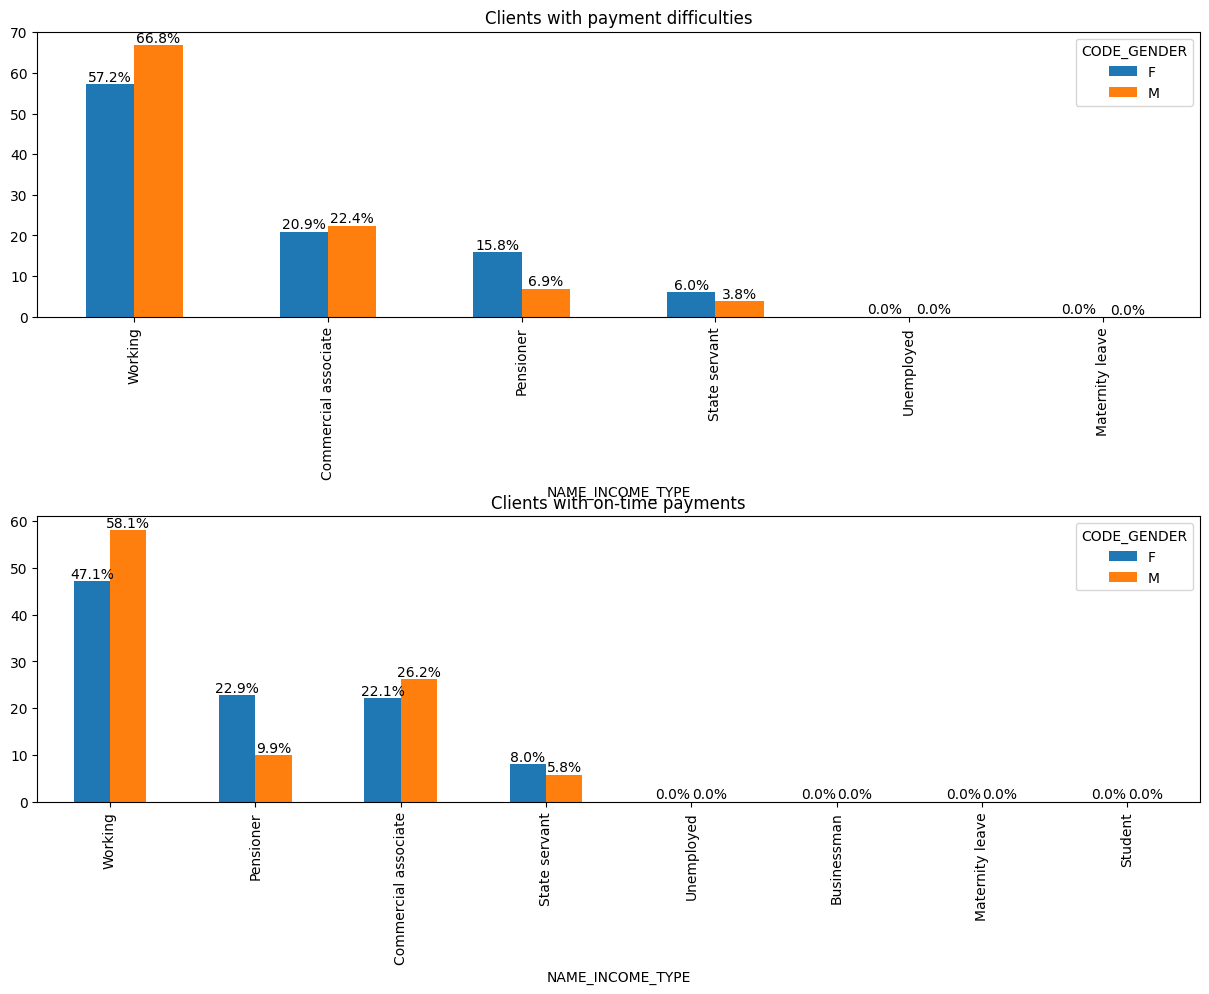

NUMBER OF VALUES PER CATEGORY NAME_INCOME_TYPE


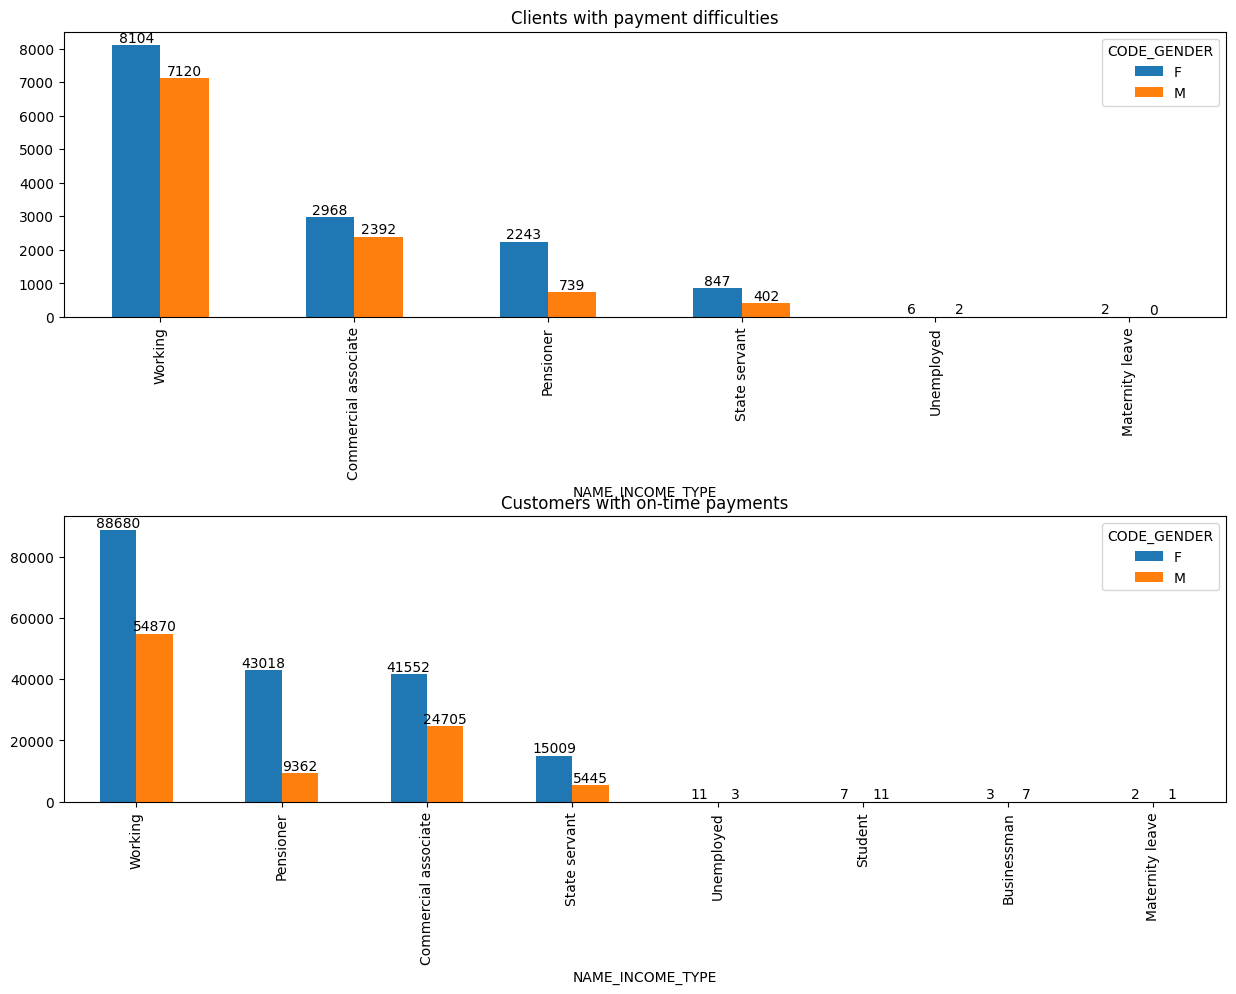

In [558]:
bi_countplot_target(df0, df1, 'NAME_INCOME_TYPE','CODE_GENDER')

**Observation**

*   Among clients who have difficulties with payments, the percentage of people in the "Working" and "Male" categories is significantly higher than among clients who do not have difficulties with payments.
*   Among clients who have difficulties with payments, the percentage of people in the "Working" and "Female" categories is significantly higher than among clients who do not have difficulties with payments.
*   Since for both CODE_GENDER we see that the largest percentage of clients have NAME_INCOME_TYPE Working - it is important to analyze additional variables that may affect whether a client will have difficulties with payments, because the group of clients NAME_INCOME_TYPE Working - is generally the largest in our data.
*   Clients in the "Businessmen" and "Students" categories make payments on time, although their history is small

**Analyze of NAME_EDUCATION_TYPE vs CODE_GENDER columns**

NORMALIZED DISTRIBUTION OF VALUES BY CATEGORY: NAME_EDUCATION_TYPE


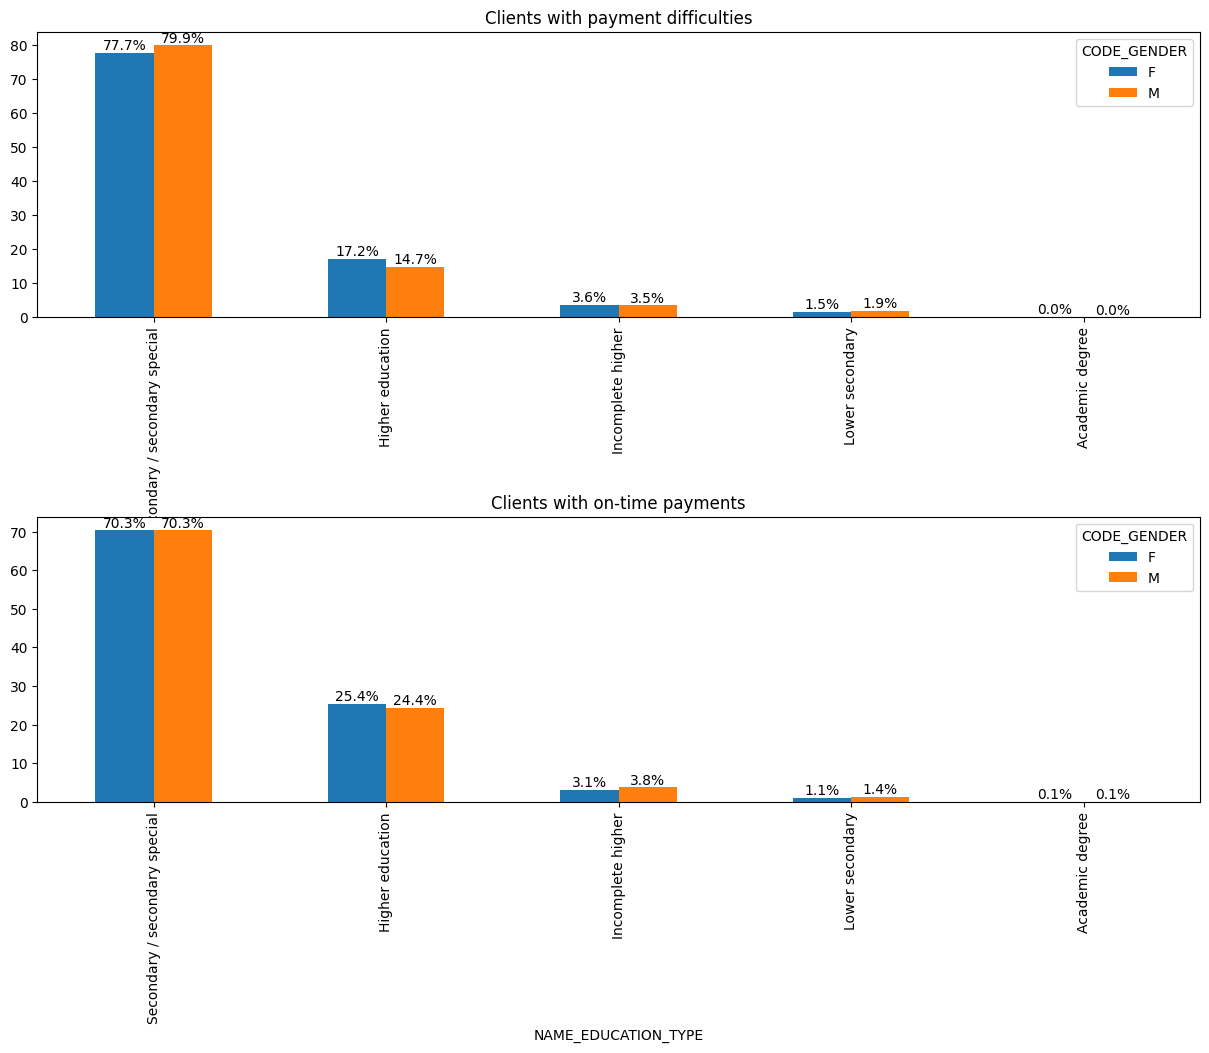

NUMBER OF VALUES PER CATEGORY NAME_EDUCATION_TYPE


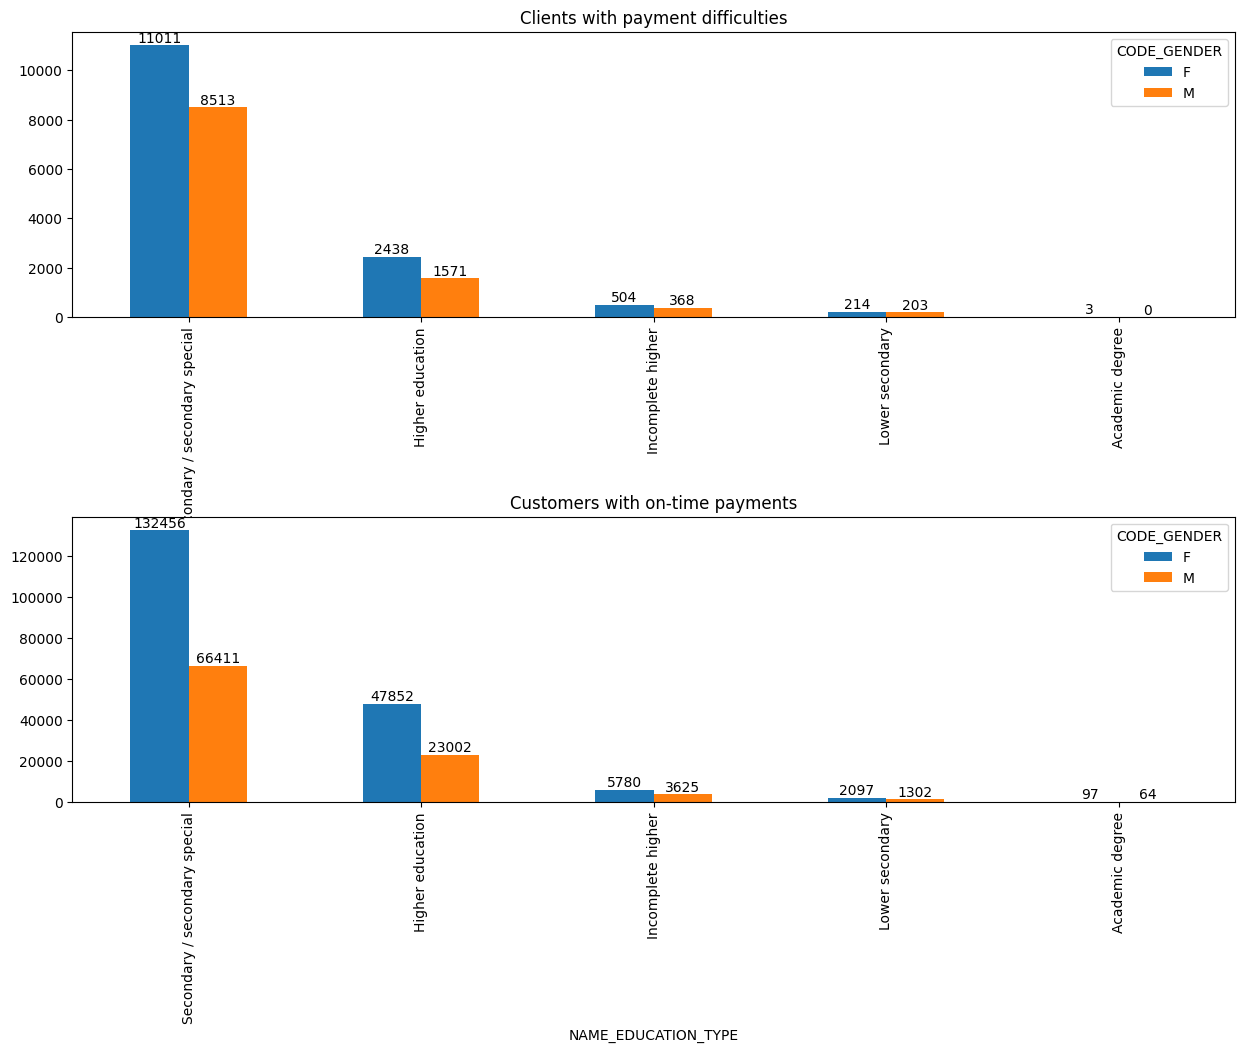

In [559]:
bi_countplot_target(df0, df1, 'NAME_EDUCATION_TYPE','CODE_GENDER')